## Bank GoodCredit – Credit Risk Prediction

## Project Objective

The objective of this project is to develop a machine learning model that
predicts whether a customer is likely to have a good or bad credit history.

The target variable is `Bad_label`:

- 0 = Good credit history
- 1 = Bad credit history / 30+ days past due

The project uses three datasets:

1. **Cust_Account** – Contains customer credit-account and repayment information.
2. **Cust_Enquiry** – Contains customer credit-enquiry information.
3. **Cust_Demographics** – Contains customer demographic features and the target variable.

The final objective is to create customer-level features from account and
enquiry history, combine them with demographic information, train classification
models, and evaluate their ability to identify credit-risk customers.

The final model will be evaluated using classification metrics and the Gini
coefficient. Rank ordering/decile analysis will also be performed for the
selected model.

## Business Objective

The primary objective of this project is to help Bank GoodCredit
identify customers who are more likely to have poor credit behaviour.

A reliable credit-risk model can help the bank:

- Assess customer creditworthiness.
- Identify high-risk customers.
- Reduce potential credit-default risk.
- Improve lending and credit decisions.
- Support risk-based customer management.

The final model will predict the probability that a customer belongs
to the bad-credit class.

## Project Requirements

The project will include:

1. Data understanding and exploration
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Account-level feature engineering
5. Enquiry-level feature engineering
6. Demographic data preparation
7. Customer-level feature matrix creation
8. Feature selection
9. Train-test split
10. Data preprocessing
11. Baseline model development
12. Hyperparameter tuning
13. Model comparison
14. Classification reports
15. ROC-AUC evaluation
16. Gini coefficient evaluation
17. Feature importance / feature gain
18. Rank ordering / decile analysis
19. Final model selection
20. Business conclusions

In [926]:
# Import required libraries

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [927]:
print("Current Working Directory:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

Current Working Directory:
C:\Users\Welcome\AI client

Files/Folders:
['.ipynb_checkpoints', 'bank good credit.ipynb', 'Bank_GoodCredit_Data']


In [928]:
data_folder = "Bank_GoodCredit_Data"

print("Dataset folder contents:")
print(os.listdir(data_folder))

Dataset folder contents:
['.ipynb_checkpoints', 'account_clean.csv', 'account_features_final.csv', 'baseline_model_comparison.csv', 'baseline_overfitting_check.csv', 'Cust_Account.csv', 'Cust_Demographics.csv', 'Cust_Enquiry.csv', 'demographics_clean.csv', 'enquiry_clean.csv', 'enquiry_features_final.csv', 'final_data_before_train_test_split.csv', 'final_feature_information.csv', 'master_customer_data.csv', 'model_data_before_preprocessing.csv']


In [929]:
account_df = pd.read_csv(
    r"Bank_GoodCredit_Data\Cust_Account.csv",
    low_memory=False
)

enquiry_df = pd.read_csv(
    r"Bank_GoodCredit_Data\Cust_Enquiry.csv",
    low_memory=False
)

demographics_df = pd.read_csv(
    r"Bank_GoodCredit_Data\Cust_Demographics.csv",
    low_memory=False
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [930]:
print("Account Shape      :", account_df.shape)
print("Enquiry Shape      :", enquiry_df.shape)
print("Demographics Shape :", demographics_df.shape)

Account Shape      : (186329, 21)
Enquiry Shape      : (413188, 6)
Demographics Shape : (23896, 83)


In [931]:
dataset_summary = pd.DataFrame({
    "Dataset": [
        "Account",
        "Enquiry",
        "Demographics"
    ],

    "Rows": [
        account_df.shape[0],
        enquiry_df.shape[0],
        demographics_df.shape[0]
    ],

    "Columns": [
        account_df.shape[1],
        enquiry_df.shape[1],
        demographics_df.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Account,186329,21
1,Enquiry,413188,6
2,Demographics,23896,83


In [932]:
display(account_df.head())

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,"20,900.000",0,NaN,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",NaN,01-Sep-15,01-Jul-14,NaN,NaN,NaN,NaN,NaN
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,NaN,03-Oct-15,"16,201.000",10390,NaN,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,"14,000.000","1,400.000",NaN,3.000,"5,603.000"
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,NaN,30-Sep-15,"41,028.000",34420,NaN,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,NaN,NaN,NaN,NaN,NaN
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,NaN,26-Jul-07,31-Jan-09,"93,473.000",0,NaN,"""""""1200900600600600300000000000000000000000000...",NaN,01-Jul-07,01-Feb-06,NaN,NaN,NaN,NaN,NaN
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,NaN,31-May-15,"20,250.000",13500,NaN,"""""""000000000000000""""""",NaN,01-May-15,01-Jan-15,NaN,NaN,NaN,NaN,NaN


In [933]:
print("ACCOUNT DATASET INFORMATION")
print("=" * 70)

account_df.info()

ACCOUNT DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186329 entries, 0 to 186328
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_opened            186329 non-null  object 
 1   customer_no          186329 non-null  int64  
 2   upload_dt            186329 non-null  object 
 3   acct_type            186329 non-null  int64  
 4   owner_indic          186329 non-null  int64  
 5   opened_dt            185874 non-null  object 
 6   last_paymt_dt        160842 non-null  object 
 7   closed_dt            77254 non-null   object 
 8   reporting_dt         186329 non-null  object 
 9   high_credit_amt      177454 non-null  float64
 10  cur_balance_amt      186329 non-null  int64  
 11  amt_past_due         876 non-null     float64
 12  paymenthistory1      186329 non-null  object 
 13  paymenthistory2      78505 non-null   object 
 14  paymt_str_dt         186328 non-null  ob

In [934]:
print("ACCOUNT DATASET COLUMNS")
print("=" * 70)

for i, col in enumerate(
    account_df.columns,
    start=1
):
    print(f"{i}. {col}")

ACCOUNT DATASET COLUMNS
1. dt_opened
2. customer_no
3. upload_dt
4. acct_type
5. owner_indic
6. opened_dt
7. last_paymt_dt
8. closed_dt
9. reporting_dt
10. high_credit_amt
11. cur_balance_amt
12. amt_past_due
13. paymenthistory1
14. paymenthistory2
15. paymt_str_dt
16. paymt_end_dt
17. creditlimit
18. cashlimit
19. rateofinterest
20. paymentfrequency
21. actualpaymentamount


In [935]:
display(enquiry_df.head())

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2.000,"3,500,000.000"
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5.000,"500,000.000"
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0.000,"50,000.000"
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10.000,"50,000.000"
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10.000,"1,000.000"


In [936]:
print("ENQUIRY DATASET INFORMATION")
print("=" * 70)

enquiry_df.info()

ENQUIRY DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413188 entries, 0 to 413187
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt_opened    413188 non-null  object 
 1   customer_no  413188 non-null  int64  
 2   upload_dt    413078 non-null  object 
 3   enquiry_dt   413078 non-null  object 
 4   enq_purpose  413078 non-null  float64
 5   enq_amt      413078 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB


In [937]:
print("ENQUIRY DATASET COLUMNS")
print("=" * 70)

for i, col in enumerate(
    enquiry_df.columns,
    start=1
):
    print(f"{i}. {col}")

ENQUIRY DATASET COLUMNS
1. dt_opened
2. customer_no
3. upload_dt
4. enquiry_dt
5. enq_purpose
6. enq_amt


In [938]:
display(demographics_df.head())

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.000,2.000,Card Setup,14.000,"500,000.000",NaN,NaN,NaN,Y,IS1,NaN,0.000,159,4284,4284,NaN,1.000,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1.000,2.000,NaN,Mumbai / Navi Mumbai / Thane,"400,610.000","1,965.000",0.000,Self,Y,2.000,"90,000.000",NaN,NaN,NaN,0.000,0.000,0.000,0.000,Mumbai,"400,059.000",@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,NaN,Y,State Bank of India,0.000,01-Jun-13,17-Jun-16,1.000,21.000,NaN,Y,Y,N,NaN,Y,1965-0,21.000,15.000,"400,610.000",0.000,2.000,"90,000.000",Nov-00,21.000,R,NaN,NaN,0000-00-00,0.000,98332XXXXX,1.000,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.000,1.000,Card Setup,14.000,"1,200,000.000",NaN,NaN,NaN,Y,IS1,NaN,0.000,91,B001,4077,NaN,1.000,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1.000,2.000,NaN,Bengaluru,"560,042.000","1,969.000",0.000,Self,Y,2.000,1.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,Bangalore,"560,042.000",NaN,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0.000,NaN,17-Jun-16,1.000,17.000,NaN,Y,Y,N,NaN,Y,1969-0,17.000,12.000,"560,042.000",0.000,2.000,1.000,Nov-00,17.000,R,NaN,NaN,0000-00-00,0.000,99455XXXXX,1.000,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.000,1.000,Card Setup,14.000,"700,000.000",NaN,NaN,NaN,Y,IS1,NaN,0.000,91,B001,4077,NaN,2.000,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1.000,0.000,NaN,Bengaluru,"560,042.000","1,966.000",0.000,Self,Y,2.000,1.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,Bangalore,"560,042.000",NaN,PAN Card,AFAPNXXXXX,NaN,NaN,N,NaN,0.000,NaN,17-Jun-16,3.000,17.000,NaN,N,Y,N,NaN,Y,1966-0,17.000,12.000,"560,042.000",0.000,2.000,1.000,Nov-00,17.000,R,NaN,NaN,0000-00-00,0.000,98456XXXXX,1.000,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.000,1.000,Card Setup,14.000,"500,000.000",NaN,NaN,NaN,Y,IS1,NaN,0.000,157,5107,5107,NaN,1.000,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1.000,3.000,NaN,Pune,"411,001.000","1,988.000",0.000,Self,Y,2.000,"100,000.000",NaN,NaN,NaN,0.000,0.000,0.000,0.000,Pune,"411,026.000",@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.,NaN,Y,HDFC Bank,0.000,NaN,17-Jun-16,1.000,21.000,NaN,Y,Y,N,NaN,Y,1988-0,21.000,16.000,"411,001.000",0.000,2.000,"100,000.000",Nov-00,21.000,R,NaN,NaN,6/15/65,1.000,98220XXXXX,1.000,N,0
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3.000,Card Setup,14.000,"500,000.000",NaN,NaN,NaN,Y,IS1,NaN,0.000,100,D016,4564,NaN,1.000,ABEPSXXXXX,03-Jan-54,98111XXXXX,N,@REDIFFMAIL.COM,1.000,3.000,NaN,Gurgaon,"122,009.000","1,995.000",0.000,Self,Y,2.000,"300,000.000",NaN,NaN,NaN,0.000,0.000,0.000,0.000,Gurgaon,"122,009.000",NaN,PAN Card,ABEPSXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0.000,NaN,17-Jun-16,1.000,13.000,NaN,Y,Y,N,NaN,Y,1995-0,13.000,3.000,"122,009.000",0.000,2.000,"300,000.000",Nov-00,13.000,R,NaN,NaN,0000-00-00,0.000,98111XXXXX,1.000,N,0


In [939]:
print("DEMOGRAPHICS DATASET INFORMATION")
print("=" * 70)

demographics_df.info()

DEMOGRAPHICS DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23896 entries, 0 to 23895
Data columns (total 83 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dt_opened    23896 non-null  object 
 1   customer_no  23896 non-null  int64  
 2   entry_time   23881 non-null  object 
 3   feature_1    23881 non-null  object 
 4   feature_2    21060 non-null  object 
 5   feature_3    21060 non-null  float64
 6   feature_4    23881 non-null  float64
 7   feature_5    23881 non-null  object 
 8   feature_6    23881 non-null  float64
 9   feature_7    23881 non-null  float64
 10  feature_8    1261 non-null   object 
 11  feature_9    1261 non-null   object 
 12  feature_10   51 non-null     object 
 13  feature_11   23881 non-null  object 
 14  feature_12   23881 non-null  object 
 15  feature_13   10892 non-null  object 
 16  feature_14   16163 non-null  float64
 17  feature_15   23873 non-null  object 
 18  feature_16   

In [940]:
print("DEMOGRAPHICS DATASET COLUMNS")
print("=" * 70)

for i, col in enumerate(
    demographics_df.columns,
    start=1
):
    print(f"{i}. {col}")

DEMOGRAPHICS DATASET COLUMNS
1. dt_opened
2. customer_no
3. entry_time
4. feature_1
5. feature_2
6. feature_3
7. feature_4
8. feature_5
9. feature_6
10. feature_7
11. feature_8
12. feature_9
13. feature_10
14. feature_11
15. feature_12
16. feature_13
17. feature_14
18. feature_15
19. feature_16
20. feature_17
21. feature_18
22. feature_19
23. feature_20
24. feature_21
25. feature_22
26. feature_23
27. feature_24
28. feature_25
29. feature_26
30. feature_27
31. feature_28
32. feature_29
33. feature_30
34. feature_31
35. feature_32
36. feature_33
37. feature_34
38. feature_35
39. feature_36
40. feature_37
41. feature_38
42. feature_39
43. feature_40
44. feature_41
45. feature_42
46. feature_43
47. feature_44
48. feature_45
49. feature_46
50. feature_47
51. feature_48
52. feature_49
53. feature_50
54. feature_51
55. feature_52
56. feature_53
57. feature_54
58. feature_55
59. feature_56
60. feature_57
61. feature_58
62. feature_59
63. feature_60
64. feature_61
65. feature_62
66. feature_63

In [941]:
def clean_column_names(df):

    df = df.copy()

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    return df


account_df = clean_column_names(account_df)
enquiry_df = clean_column_names(enquiry_df)
demographics_df = clean_column_names(demographics_df)

print("Column names cleaned successfully.")

Column names cleaned successfully.


In [942]:
print("Account customer columns:")
print([
    c for c in account_df.columns
    if "customer" in c
])

print("\nEnquiry customer columns:")
print([
    c for c in enquiry_df.columns
    if "customer" in c
])

print("\nDemographics customer columns:")
print([
    c for c in demographics_df.columns
    if "customer" in c
])

Account customer columns:
['customer_no']

Enquiry customer columns:
['customer_no']

Demographics customer columns:
['customer_no']


In [943]:
required_account_cols = [
    "customer_no",
    "acct_type",
    "opened_dt",
    "last_paymt_dt",
    "cur_balance_amt",
    "amt_past_due",
    "creditlimit"
]

required_enquiry_cols = [
    "customer_no",
    "enquiry_dt",
    "enq_purpose",
    "enq_amt"
]

required_demo_cols = [
    "customer_no",
    "bad_label"
]


def check_required_columns(
    df,
    required_cols,
    dataset_name
):

    missing = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if len(missing) == 0:

        print(
            f"{dataset_name}: "
            "required columns found."
        )

    else:

        print(
            f"{dataset_name}: "
            f"missing columns = {missing}"
        )


check_required_columns(
    account_df,
    required_account_cols,
    "Account"
)

check_required_columns(
    enquiry_df,
    required_enquiry_cols,
    "Enquiry"
)

check_required_columns(
    demographics_df,
    required_demo_cols,
    "Demographics"
)

Account: required columns found.
Enquiry: required columns found.
Demographics: required columns found.


## Check duplicate rows

In [945]:
print("DUPLICATE ROW CHECK")
print("=" * 70)

print(
    "Account duplicates:",
    account_df.duplicated().sum()
)

print(
    "Enquiry duplicates:",
    enquiry_df.duplicated().sum()
)

print(
    "Demographics duplicates:",
    demographics_df.duplicated().sum()
)

DUPLICATE ROW CHECK
Account duplicates: 2401
Enquiry duplicates: 13827
Demographics duplicates: 0


## Check missing values

In [947]:
def missing_summary(df):

    result = pd.DataFrame({
        "Missing_Count":
            df.isnull().sum(),

        "Missing_Percentage":
            df.isnull().mean() * 100
    })

    result = result[
        result["Missing_Count"] > 0
    ]

    return result.sort_values(
        "Missing_Percentage",
        ascending=False
    )

In [948]:
missing_summary(account_df)

,Missing_Count,Missing_Percentage
amt_past_due,185453,99.530
rateofinterest,161496,86.672
cashlimit,151047,81.065
actualpaymentamount,145276,77.967
creditlimit,137477,73.782
paymentfrequency,122436,65.710
closed_dt,109075,58.539
paymenthistory2,107824,57.868
last_paymt_dt,25487,13.678
high_credit_amt,8875,4.763


In [949]:
missing_summary(enquiry_df)

,Missing_Count,Missing_Percentage
upload_dt,110,0.027
enquiry_dt,110,0.027
enq_purpose,110,0.027
enq_amt,110,0.027


In [950]:
missing_summary(demographics_df)

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
feature_17,22869,95.702
feature_8,22635,94.723
feature_9,22635,94.723
feature_57,21503,89.986
feature_73,20951,87.676


## Check unique customers

In [952]:
print("CUSTOMER COUNTS")
print("=" * 70)

print(
    "Unique customers in Account:",
    account_df["customer_no"].nunique()
)

print(
    "Unique customers in Enquiry:",
    enquiry_df["customer_no"].nunique()
)

print(
    "Unique customers in Demographics:",
    demographics_df["customer_no"].nunique()
)

CUSTOMER COUNTS
Unique customers in Account: 23896
Unique customers in Enquiry: 23896
Unique customers in Demographics: 23896


## Check records per customer

In [954]:
account_records_per_customer = (
    account_df
    .groupby("customer_no")
    .size()
)

account_records_per_customer.describe()

count   23,896.000
mean         7.797
std          6.723
min          1.000
25%          3.000
50%          6.000
75%         10.000
max        120.000
dtype: float64

In [955]:
enquiry_records_per_customer = (
    enquiry_df
    .groupby("customer_no")
    .size()
)

enquiry_records_per_customer.describe()

count   23,896.000
mean        17.291
std         15.248
min          1.000
25%          7.000
50%         13.000
75%         23.000
max        308.000
dtype: float64

In [956]:
print(
    "Demographics rows:",
    len(demographics_df)
)

print(
    "Unique customer IDs:",
    demographics_df["customer_no"].nunique()
)

print(
    "Duplicate customer IDs:",
    demographics_df[
        "customer_no"
    ].duplicated().sum()
)

Demographics rows: 23896
Unique customer IDs: 23896
Duplicate customer IDs: 0


## Check target variable

In [958]:
print("TARGET DISTRIBUTION")
print("=" * 70)

print(
    demographics_df[
        "bad_label"
    ].value_counts(dropna=False)
)

TARGET DISTRIBUTION
bad_label
0    22892
1     1004
Name: count, dtype: int64


In [959]:
target_percentage = (
    demographics_df["bad_label"]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .mul(100)
)

print(target_percentage)

bad_label
0   95.798
1    4.202
Name: proportion, dtype: float64


## Visualize target distribution

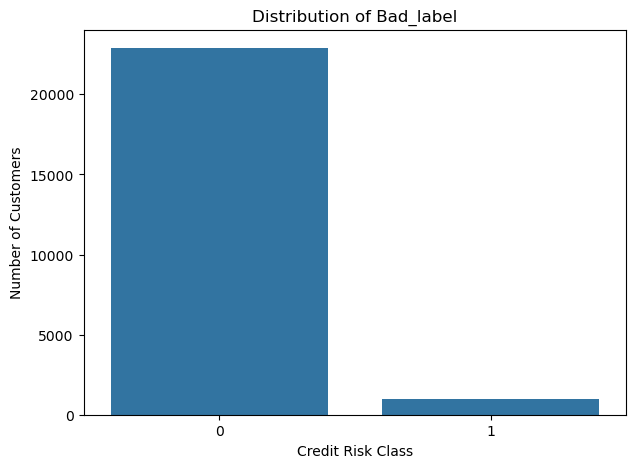

In [961]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=demographics_df,
    x="bad_label"
)

plt.title(
    "Distribution of Bad_label"
)

plt.xlabel(
    "Credit Risk Class"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## Check target for missing values

In [963]:
print(
    "Missing Bad_label:",
    demographics_df[
        "bad_label"
    ].isnull().sum()
)

Missing Bad_label: 0


## Check target classes

In [965]:
print(
    "Target classes:",
    sorted(
        demographics_df[
            "bad_label"
        ].dropna().unique()
    )
)

Target classes: [0, 1]


## Check customer overlap between datasets

In [967]:
account_customers = set(
    account_df[
        "customer_no"
    ].dropna()
)

enquiry_customers = set(
    enquiry_df[
        "customer_no"
    ].dropna()
)

demo_customers = set(
    demographics_df[
        "customer_no"
    ].dropna()
)

In [968]:
print(
    "Demographics customers:",
    len(demo_customers)
)

print(
    "Demo customers present in Account:",
    len(
        demo_customers
        & account_customers
    )
)

print(
    "Demo customers present in Enquiry:",
    len(
        demo_customers
        & enquiry_customers
    )
)

Demographics customers: 23896
Demo customers present in Account: 23896
Demo customers present in Enquiry: 23896


## Check customers missing Account/Enquiry history

In [970]:
demo_without_account = (
    demo_customers
    - account_customers
)

demo_without_enquiry = (
    demo_customers
    - enquiry_customers
)

print(
    "Demographic customers without account history:",
    len(demo_without_account)
)

print(
    "Demographic customers without enquiry history:",
    len(demo_without_enquiry)
)

Demographic customers without account history: 0
Demographic customers without enquiry history: 0


## Inspect datatypes

In [972]:
print("ACCOUNT DATATYPES")
print("=" * 70)
print(account_df.dtypes)

print("\nENQUIRY DATATYPES")
print("=" * 70)
print(enquiry_df.dtypes)

print("\nDEMOGRAPHICS DATATYPES")
print("=" * 70)
print(demographics_df.dtypes)

ACCOUNT DATATYPES
dt_opened               object
customer_no              int64
upload_dt               object
acct_type                int64
owner_indic              int64
opened_dt               object
last_paymt_dt           object
closed_dt               object
reporting_dt            object
high_credit_amt        float64
cur_balance_amt          int64
amt_past_due           float64
paymenthistory1         object
paymenthistory2         object
paymt_str_dt            object
paymt_end_dt            object
creditlimit            float64
cashlimit              float64
rateofinterest          object
paymentfrequency       float64
actualpaymentamount    float64
dtype: object

ENQUIRY DATATYPES
dt_opened       object
customer_no      int64
upload_dt       object
enquiry_dt      object
enq_purpose    float64
enq_amt        float64
dtype: object

DEMOGRAPHICS DATATYPES
dt_opened       object
customer_no      int64
entry_time      object
feature_1       object
feature_2       object
feature

In [973]:
account_df.describe(
    include=[np.number]
).T

,count,mean,std,min,25%,50%,75%,max
customer_no,"186,329.000","11,431.820","6,730.432",1.000,"5,879.000","11,169.000","16,982.000","23,896.000"
acct_type,"186,329.000",8.403,5.179,0.000,6.000,10.000,10.000,59.000
owner_indic,"186,329.000",1.122,0.567,1.000,1.000,1.000,1.000,4.000
high_credit_amt,"177,454.000","175,610.352","984,264.332",1.000,"22,975.000","45,223.500","106,000.000","180,000,000.000"
cur_balance_amt,"186,329.000","76,402.695","618,678.292","-7,355,205.000",0.000,0.000,"20,998.000","136,009,965.000"
amt_past_due,876.000,"25,831.509","203,067.996",1.000,153.500,"1,209.500","7,663.250","4,869,309.000"
creditlimit,"48,852.000","75,528.807","71,741.090",1.000,"31,000.000","60,000.000","100,000.000","2,500,000.000"
cashlimit,"35,282.000","20,608.503","24,856.481",1.000,"7,500.000","12,500.000","27,000.000","1,000,000.000"
paymentfrequency,"63,893.000",2.996,0.087,1.000,3.000,3.000,3.000,3.000
actualpaymentamount,"41,053.000","30,166.161","387,082.206",1.000,"3,110.000","7,590.000","18,000.000","67,853,221.000"


In [974]:
enquiry_df.describe(
    include=[np.number]
).T

,count,mean,std,min,25%,50%,75%,max
customer_no,"413,188.000","11,399.813","6,672.675",1.000,"5,999.000","11,067.000","16,856.000","23,896.000"
enq_purpose,"413,078.000",8.155,5.638,0.000,5.000,10.000,10.000,59.000
enq_amt,"413,078.000","828,909.436","12,043,281.408",1.000,"10,000.000","50,000.000","143,000.000","999,999,999.000"


In [975]:
demographics_df.describe(
    include=[np.number]
).T

,count,mean,std,min,25%,50%,75%,max
customer_no,"23,896.000","11,948.500","6,898.325",1.000,"5,974.750","11,948.500","17,922.250","23,896.000"
feature_3,"21,060.000",723.236,37.319,-1.000,698.000,721.000,745.000,896.000
feature_4,"23,881.000",2.322,0.893,1.000,1.000,3.000,3.000,3.000
feature_6,"23,881.000",14.000,0.000,14.000,14.000,14.000,14.000,14.000
feature_7,"23,881.000","119,070.504","77,523.485",0.000,"72,000.000","104,000.000","139,000.000","1,217,000.000"
feature_14,"16,163.000",8.087,5.626,0.000,0.000,12.000,12.000,12.000
feature_19,"23,881.000",1.049,0.217,1.000,1.000,1.000,1.000,2.000
feature_25,"23,881.000",1.234,0.423,1.000,1.000,1.000,1.000,2.000
feature_26,"23,881.000",0.726,1.125,0.000,0.000,0.000,2.000,10.000
feature_29,"23,881.000","217,620.229","159,267.102","110,001.000","110,051.000","110,094.000","390,002.000","712,245.000"


## quality report

In [977]:
quality_report = pd.DataFrame({
    "Dataset": [
        "Account",
        "Enquiry",
        "Demographics"
    ],

    "Rows": [
        len(account_df),
        len(enquiry_df),
        len(demographics_df)
    ],

    "Columns": [
        account_df.shape[1],
        enquiry_df.shape[1],
        demographics_df.shape[1]
    ],

    "Duplicate_Rows": [
        account_df.duplicated().sum(),
        enquiry_df.duplicated().sum(),
        demographics_df.duplicated().sum()
    ],

    "Total_Missing_Values": [
        account_df.isnull().sum().sum(),
        enquiry_df.isnull().sum().sum(),
        demographics_df.isnull().sum().sum()
    ],

    "Unique_Customers": [
        account_df["customer_no"].nunique(),
        enquiry_df["customer_no"].nunique(),
        demographics_df["customer_no"].nunique()
    ]
})

quality_report

,Dataset,Rows,Columns,Duplicate_Rows,Total_Missing_Values,Unique_Customers
0,Account,186329,21,2401,1154903,23896
1,Enquiry,413188,6,13827,440,23896
2,Demographics,23896,83,0,333644,23896


## Save backup copies

In [979]:
account_raw = account_df.copy()
enquiry_raw = enquiry_df.copy()
demographics_raw = demographics_df.copy()

print(
    "Raw dataset backup copies created."
)

Raw dataset backup copies created.


In [980]:
print("=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Account loaded:",
    not account_df.empty
)

print(
    "Enquiry loaded:",
    not enquiry_df.empty
)

print(
    "Demographics loaded:",
    not demographics_df.empty
)

print(
    "Account customer_no:",
    "customer_no" in account_df.columns
)

print(
    "Enquiry customer_no:",
    "customer_no" in enquiry_df.columns
)

print(
    "Demographics customer_no:",
    "customer_no" in demographics_df.columns
)

print(
    "Target Bad_label:",
    "bad_label" in demographics_df.columns
)

print("=" * 70)

VALIDATION
Account loaded: True
Enquiry loaded: True
Demographics loaded: True
Account customer_no: True
Enquiry customer_no: True
Demographics customer_no: True
Target Bad_label: True


## Data Cleaning and Exploratory Data Analysis

## Objective

The objective of this stage is to examine the quality and structure
of the Account, Enquiry and Demographics datasets before feature
engineering.

The following tasks are performed:

- Duplicate analysis
- Missing-value analysis
- Datatype correction
- Date conversion
- Numerical-variable analysis
- Categorical-variable analysis
- Target-variable analysis
- Outlier analysis
- Customer-level record analysis
- Initial relationship analysis
- Data-quality decisions

The cleaned datasets produced in this stage will be used for
feature engineering in the subsequent stages.

In [982]:
account_clean = account_raw.copy()
enquiry_clean = enquiry_raw.copy()
demographics_clean = demographics_raw.copy()

print("Working copies created.")

print("Account:", account_clean.shape)
print("Enquiry:", enquiry_clean.shape)
print("Demographics:", demographics_clean.shape)

Working copies created.
Account: (186329, 21)
Enquiry: (413188, 6)
Demographics: (23896, 83)


## Standardize column names

In [984]:
def standardize_columns(df):

    df = df.copy()

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    return df


account_clean = standardize_columns(
    account_clean
)

enquiry_clean = standardize_columns(
    enquiry_clean
)

demographics_clean = standardize_columns(
    demographics_clean
)

print("Column names standardized.")

Column names standardized.


In [985]:
print("Account:")
print(account_clean.columns.tolist())

print("\nEnquiry:")
print(enquiry_clean.columns.tolist())

print("\nDemographics:")
print(demographics_clean.columns.tolist())

Account:
['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic', 'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1', 'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit', 'cashlimit', 'rateofinterest', 'paymentfrequency', 'actualpaymentamount']

Enquiry:
['dt_opened', 'customer_no', 'upload_dt', 'enquiry_dt', 'enq_purpose', 'enq_amt']

Demographics:
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'fea

## DUPLICATE ANALYSIS

In [987]:
print("EXACT DUPLICATE ROWS")
print("=" * 60)

print(
    "Account:",
    account_clean.duplicated().sum()
)

print(
    "Enquiry:",
    enquiry_clean.duplicated().sum()
)

print(
    "Demographics:",
    demographics_clean.duplicated().sum()
)

EXACT DUPLICATE ROWS
Account: 2401
Enquiry: 13827
Demographics: 0


In [988]:
account_before = len(account_clean)
enquiry_before = len(enquiry_clean)
demo_before = len(demographics_clean)

account_clean = (
    account_clean
    .drop_duplicates()
    .copy()
)

enquiry_clean = (
    enquiry_clean
    .drop_duplicates()
    .copy()
)

demographics_clean = (
    demographics_clean
    .drop_duplicates()
    .copy()
)

print(
    "Account duplicates removed:",
    account_before - len(account_clean)
)

print(
    "Enquiry duplicates removed:",
    enquiry_before - len(enquiry_clean)
)

print(
    "Demographics duplicates removed:",
    demo_before - len(demographics_clean)
)

Account duplicates removed: 2401
Enquiry duplicates removed: 13827
Demographics duplicates removed: 0


## CUSTOMER IDENTIFIER CLEANING

In [990]:
print("MISSING CUSTOMER IDs")
print("=" * 60)

print(
    "Account:",
    account_clean[
        "customer_no"
    ].isna().sum()
)

print(
    "Enquiry:",
    enquiry_clean[
        "customer_no"
    ].isna().sum()
)

print(
    "Demographics:",
    demographics_clean[
        "customer_no"
    ].isna().sum()
)

MISSING CUSTOMER IDs
Account: 0
Enquiry: 0
Demographics: 0


In [991]:
account_clean = (
    account_clean
    .dropna(subset=["customer_no"])
    .copy()
)

enquiry_clean = (
    enquiry_clean
    .dropna(subset=["customer_no"])
    .copy()
)

demographics_clean = (
    demographics_clean
    .dropna(subset=["customer_no"])
    .copy()
)

print("Missing customer-ID records removed.")

Missing customer-ID records removed.


In [992]:
for df in [
    account_clean,
    enquiry_clean,
    demographics_clean
]:

    df["customer_no"] = (
        df["customer_no"]
        .astype(str)
        .str.strip()
    )

In [993]:
print(
    account_clean["customer_no"].dtype
)

print(
    enquiry_clean["customer_no"].dtype
)

print(
    demographics_clean["customer_no"].dtype
)

object
object
object


## TARGET CLEANING

In [995]:
demographics_clean[
    "bad_label"
] = pd.to_numeric(
    demographics_clean["bad_label"],
    errors="coerce"
)

In [996]:
demographics_clean[
    "bad_label"
].value_counts(
    dropna=False
)

bad_label
0    22892
1     1004
Name: count, dtype: int64

In [997]:
print(
    "Missing targets before:",
    demographics_clean[
        "bad_label"
    ].isna().sum()
)

Missing targets before: 0


In [998]:
demographics_clean = (
    demographics_clean
    .dropna(subset=["bad_label"])
    .copy()
)

In [999]:
print(
    "Target values:",
    sorted(
        demographics_clean[
            "bad_label"
        ].unique()
    )
)

Target values: [0, 1]


In [1000]:
demographics_clean[
    "bad_label"
] = demographics_clean[
    "bad_label"
].astype(int)

## ACCOUNT DATA CLEANING

In [1002]:
account_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183928 entries, 0 to 186328
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_opened            183928 non-null  object 
 1   customer_no          183928 non-null  object 
 2   upload_dt            183928 non-null  object 
 3   acct_type            183928 non-null  int64  
 4   owner_indic          183928 non-null  int64  
 5   opened_dt            183502 non-null  object 
 6   last_paymt_dt        158833 non-null  object 
 7   closed_dt            76153 non-null   object 
 8   reporting_dt         183928 non-null  object 
 9   high_credit_amt      175210 non-null  float64
 10  cur_balance_amt      183928 non-null  int64  
 11  amt_past_due         865 non-null     float64
 12  paymenthistory1      183928 non-null  object 
 13  paymenthistory2      77533 non-null   object 
 14  paymt_str_dt         183927 non-null  object 
 15  paymt_end_dt         1

In [1003]:
account_numeric_cols = [
    "high_credit_amt",
    "cur_balance_amt",
    "amt_past_due",
    "creditlimit",
    "cashlimit",
    "rateofinterest",
    "paymentfrequency",
    "actualpaymentamount"
]

for col in account_numeric_cols:

    if col in account_clean.columns:

        account_clean[col] = pd.to_numeric(
            account_clean[col],
            errors="coerce"
        )

print("Account numerical conversion completed.")

Account numerical conversion completed.


In [1004]:
for col in account_numeric_cols:

    if col in account_clean.columns:

        print(
            f"{col:25} "
            f"{account_clean[col].dtype}"
        )

high_credit_amt           float64
cur_balance_amt           int64
amt_past_due              float64
creditlimit               float64
cashlimit                 float64
rateofinterest            float64
paymentfrequency          float64
actualpaymentamount       float64


## ACCOUNT DATE CLEANING

In [1006]:
account_date_cols = [
    "dt_opened",
    "upload_dt",
    "opened_dt",
    "last_paymt_dt",
    "closed_dt",
    "reporting_dt",
    "paymt_str_dt",
    "paymt_end_dt"
]

In [1007]:
for col in account_date_cols:

    if col in account_clean.columns:

        account_clean[col] = pd.to_datetime(
            account_clean[col],
            format="%d-%b-%y",
            errors="coerce"
        )

print("Account date conversion completed.")

Account date conversion completed.


In [1008]:
for col in account_date_cols:

    if col in account_clean.columns:

        print(
            f"{col:20} "
            f"{account_clean[col].dtype}"
        )

dt_opened            datetime64[ns]
upload_dt            datetime64[ns]
opened_dt            datetime64[ns]
last_paymt_dt        datetime64[ns]
closed_dt            datetime64[ns]
reporting_dt         datetime64[ns]
paymt_str_dt         datetime64[ns]
paymt_end_dt         datetime64[ns]


In [1009]:
print("ACCOUNT DATE RANGES")
print("=" * 70)

for col in account_date_cols:

    if col in account_clean.columns:

        print(
            f"{col:20}",
            "| Min:",
            account_clean[col].min(),
            "| Max:",
            account_clean[col].max()
        )

ACCOUNT DATE RANGES
dt_opened            | Min: 2015-04-16 00:00:00 | Max: 2015-12-31 00:00:00
upload_dt            | Min: 2015-04-21 00:00:00 | Max: 2015-12-31 00:00:00
opened_dt            | Min: 1979-10-01 00:00:00 | Max: 2015-12-15 00:00:00
last_paymt_dt        | Min: 1993-02-20 00:00:00 | Max: 2015-12-10 00:00:00
closed_dt            | Min: 1993-10-14 00:00:00 | Max: 2015-12-11 00:00:00
reporting_dt         | Min: 2004-02-14 00:00:00 | Max: 2015-12-20 00:00:00
paymt_str_dt         | Min: 1993-10-01 00:00:00 | Max: 2015-12-01 00:00:00
paymt_end_dt         | Min: 1993-02-01 00:00:00 | Max: 2015-12-01 00:00:00


## ACCOUNT MISSING VALUES

In [1011]:
account_missing = pd.DataFrame({

    "Missing_Count":
        account_clean.isnull().sum(),

    "Missing_Percentage":
        account_clean.isnull().mean() * 100
})

account_missing = (
    account_missing
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

account_missing

,Missing_Count,Missing_Percentage
amt_past_due,183063,99.530
rateofinterest,159418,86.674
cashlimit,149025,81.024
actualpaymentamount,143343,77.934
creditlimit,135629,73.740
paymentfrequency,120801,65.678
closed_dt,107775,58.596
paymenthistory2,106395,57.846
last_paymt_dt,25095,13.644
high_credit_amt,8718,4.740


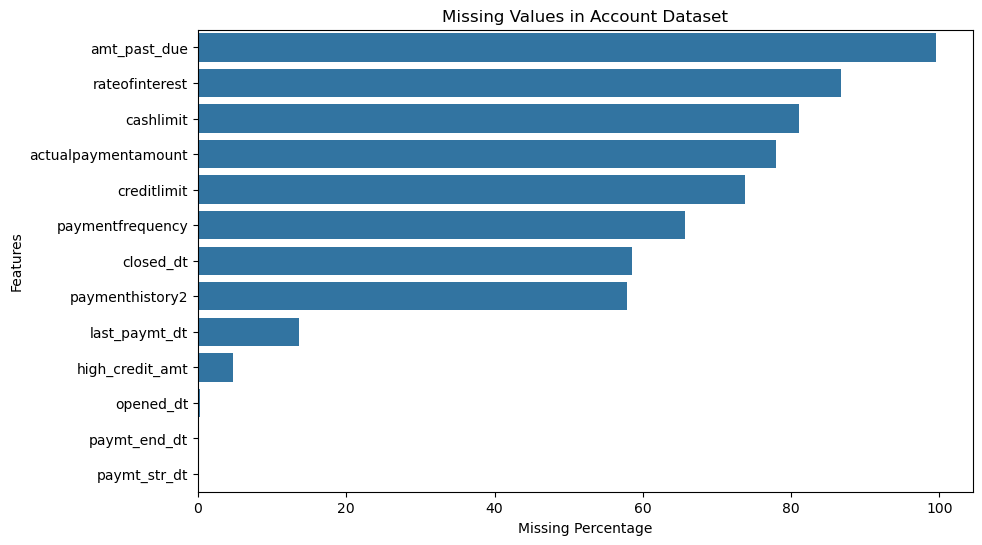

In [1012]:
account_missing_plot = (
    account_missing[
        account_missing[
            "Missing_Percentage"
        ] > 0
    ]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=account_missing_plot[
        "Missing_Percentage"
    ].values,
    y=account_missing_plot.index
)

plt.title(
    "Missing Values in Account Dataset"
)

plt.xlabel(
    "Missing Percentage"
)

plt.ylabel(
    "Features"
)

plt.show()

## PAYMENT HISTORY INVESTIGATION

In [1014]:
for col in [
    "paymenthistory1",
    "paymenthistory2"
]:

    if col in account_clean.columns:

        print("\n", col)

        print(
            "Total rows:",
            len(account_clean)
        )

        print(
            "Non-missing:",
            account_clean[col]
            .notna()
            .sum()
        )

        print(
            "Missing %:",
            round(
                account_clean[col]
                .isna()
                .mean()
                * 100,
                2
            )
        )


 paymenthistory1
Total rows: 183928
Non-missing: 183928
Missing %: 0.0

 paymenthistory2
Total rows: 183928
Non-missing: 77533
Missing %: 57.85


In [1015]:
empty_payment_cols = []

for col in [
    "paymenthistory1",
    "paymenthistory2"
]:

    if col in account_clean.columns:

        if account_clean[col].isna().all():
            empty_payment_cols.append(col)

print(
    "Completely empty payment columns:",
    empty_payment_cols
)

Completely empty payment columns: []


In [1016]:
account_clean.drop(
    columns=empty_payment_cols,
    inplace=True,
    errors="ignore"
)

print("Completely empty payment-history columns removed.")

Completely empty payment-history columns removed.


## Payment History Data Quality Observation

The Account dataset contains payment-history fields intended to
represent historical DPD behaviour.

However, the available paymenthistory1 and paymenthistory2 fields
were examined and found to contain no usable observations.

Therefore, historical 30+, 60+ and 90+ DPD sequence features cannot
be reliably derived from these fields.

The columns were excluded rather than artificially imputing
historical delinquency information.

Available variables such as `amt_past_due` will be used later to
construct valid past-due related features.

## ACCOUNT NUMERICAL EDA

In [1019]:
account_clean[
    [
        col
        for col in account_numeric_cols
        if col in account_clean.columns
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
high_credit_amt,"175,210.000","175,704.013","989,001.201",1.000,"22,978.250","45,210.000","105,898.500","180,000,000.000"
cur_balance_amt,"183,928.000","76,465.943","621,034.522","-7,355,205.000",0.000,0.000,"21,057.250","136,009,965.000"
amt_past_due,865.000,"24,857.146","201,328.907",1.000,151.000,"1,200.000","7,641.000","4,869,309.000"
creditlimit,"48,299.000","75,530.704","71,671.854",1.000,"31,000.000","60,000.000","100,000.000","2,500,000.000"
cashlimit,"34,903.000","20,600.970","24,895.518",1.000,"7,500.000","12,500.000","27,000.000","1,000,000.000"
rateofinterest,"24,510.000",28.357,13.457,0.001,13.000,39.000,39.960,62.972
paymentfrequency,"63,127.000",2.996,0.086,1.000,3.000,3.000,3.000,3.000
actualpaymentamount,"40,585.000","30,161.356","389,100.754",1.000,"3,117.000","7,584.000","18,000.000","67,853,221.000"


In [1020]:
plot_sample = account_clean.sample(
    n=min(
        50000,
        len(account_clean)
    ),
    random_state=42
)

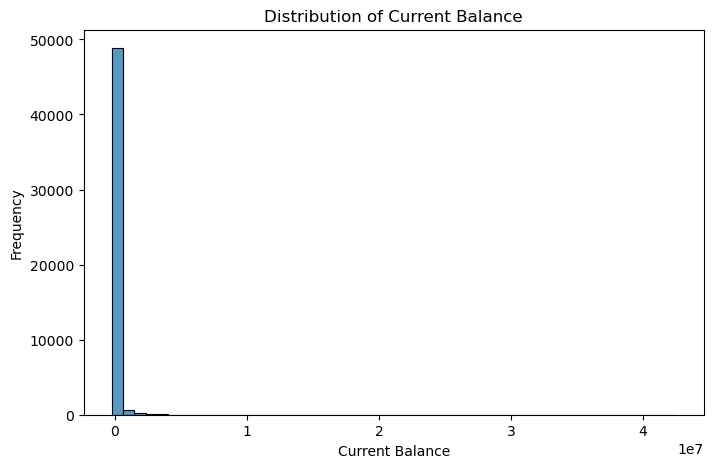

In [1021]:
plt.figure(figsize=(8, 5))

sns.histplot(
    plot_sample[
        "cur_balance_amt"
    ].dropna(),
    bins=50
)

plt.title(
    "Distribution of Current Balance"
)

plt.xlabel(
    "Current Balance"
)

plt.ylabel(
    "Frequency"
)

plt.show()

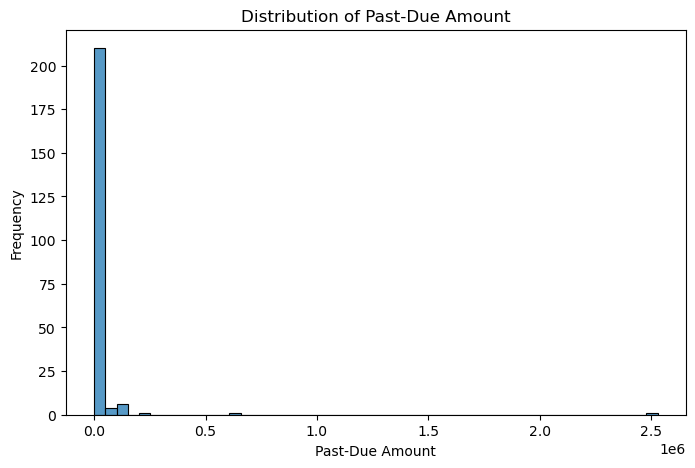

In [1022]:
plt.figure(figsize=(8, 5))

sns.histplot(
    plot_sample[
        "amt_past_due"
    ].dropna(),
    bins=50
)

plt.title(
    "Distribution of Past-Due Amount"
)

plt.xlabel(
    "Past-Due Amount"
)

plt.ylabel(
    "Frequency"
)

plt.show()

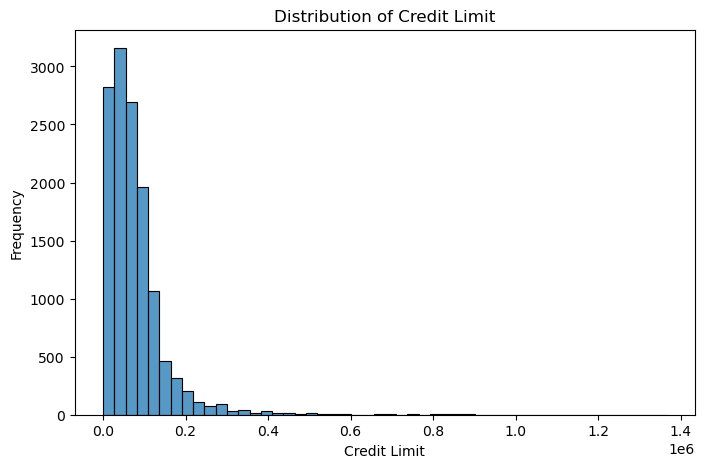

In [1023]:
plt.figure(figsize=(8, 5))

sns.histplot(
    plot_sample[
        "creditlimit"
    ].dropna(),
    bins=50
)

plt.title(
    "Distribution of Credit Limit"
)

plt.xlabel(
    "Credit Limit"
)

plt.ylabel(
    "Frequency"
)

plt.show()

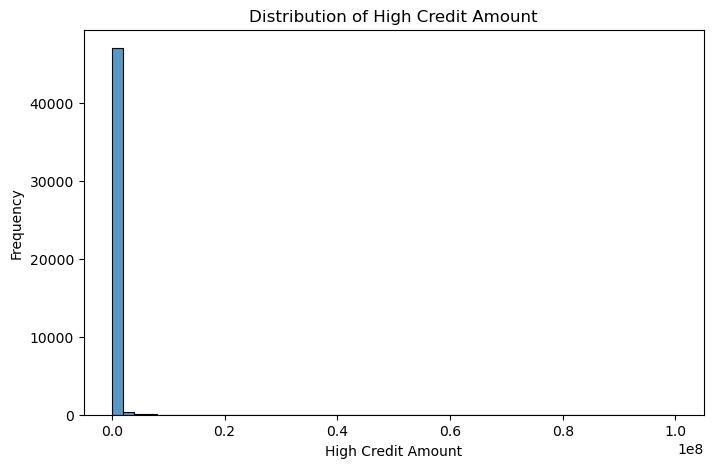

In [1024]:
plt.figure(figsize=(8, 5))

sns.histplot(
    plot_sample[
        "high_credit_amt"
    ].dropna(),
    bins=50
)

plt.title(
    "Distribution of High Credit Amount"
)

plt.xlabel(
    "High Credit Amount"
)

plt.ylabel(
    "Frequency"
)

plt.show()

## ACCOUNT CATEGORICAL EDA

In [1026]:
account_type_counts = (
    account_clean[
        "acct_type"
    ]
    .value_counts(
        dropna=False
    )
)

account_type_counts.head(20)

acct_type
10    99102
6     25252
5     22629
1      9291
13     8478
2      5577
7      4163
0      3891
12     1188
32      735
51      719
3       666
15      493
17      412
8       404
53      377
4       184
52       97
54       71
35       54
Name: count, dtype: int64

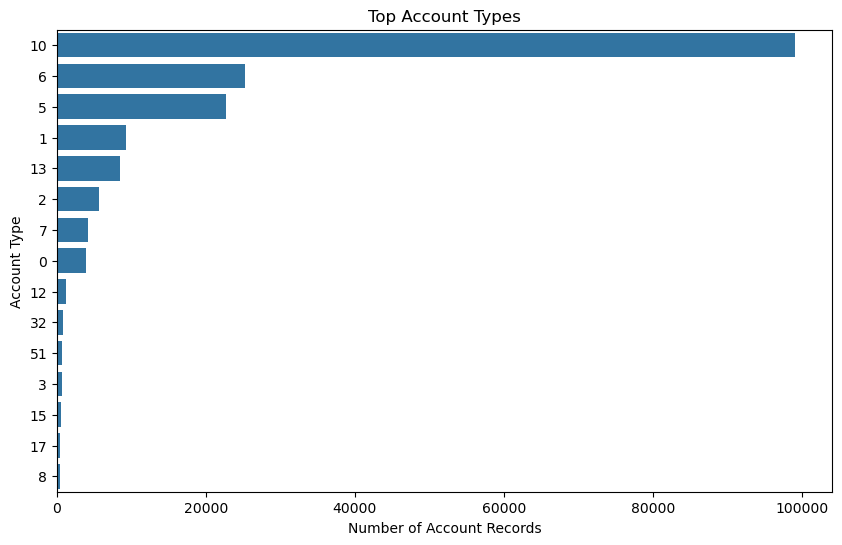

In [1027]:
top_account_types = (
    account_clean[
        "acct_type"
    ]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_account_types.values,
    y=top_account_types.index.astype(str)
)

plt.title(
    "Top Account Types"
)

plt.xlabel(
    "Number of Account Records"
)

plt.ylabel(
    "Account Type"
)

plt.show()

## Ownership indicator

In [1029]:
account_clean[
    "owner_indic"
].value_counts(
    dropna=False
)

owner_indic
1    175046
4      6180
2      1549
3      1153
Name: count, dtype: int64

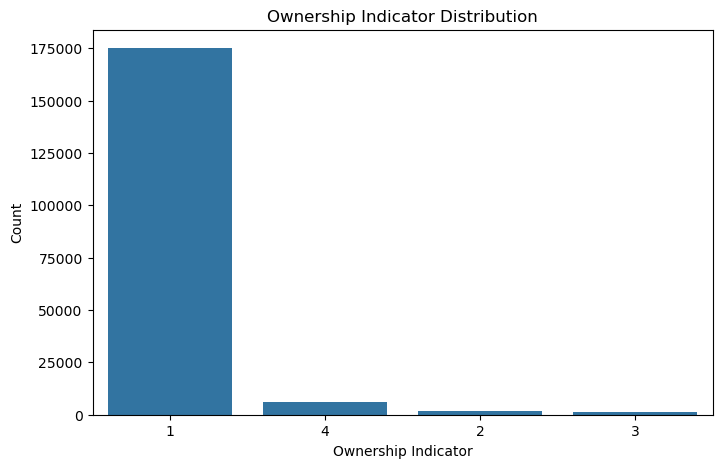

In [1030]:
owner_counts = (
    account_clean[
        "owner_indic"
    ]
    .value_counts()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=owner_counts.index.astype(str),
    y=owner_counts.values
)

plt.title(
    "Ownership Indicator Distribution"
)

plt.xlabel(
    "Ownership Indicator"
)

plt.ylabel(
    "Count"
)

plt.show()

## ACCOUNTS PER CUSTOMER

In [1032]:
accounts_per_customer = (
    account_clean
    .groupby("customer_no")
    .size()
)

accounts_per_customer.describe()

count   23,896.000
mean         7.697
std          6.454
min          1.000
25%          3.000
50%          6.000
75%         10.000
max         76.000
dtype: float64

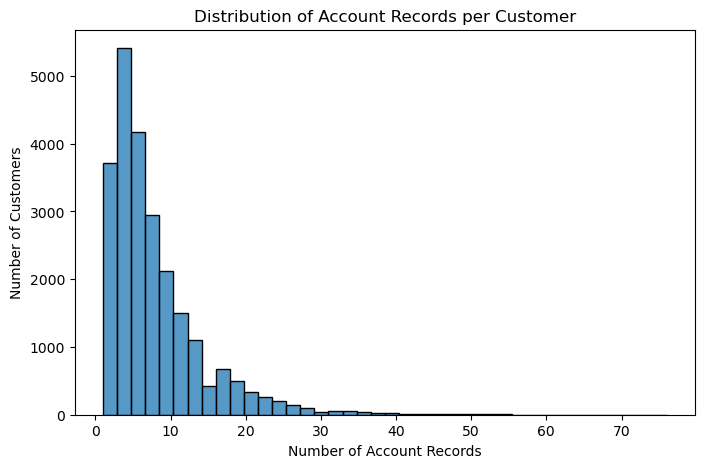

In [1033]:
plt.figure(figsize=(8, 5))

sns.histplot(
    accounts_per_customer,
    bins=40
)

plt.title(
    "Distribution of Account Records per Customer"
)

plt.xlabel(
    "Number of Account Records"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## ENQUIRY DATA CLEANING

In [1035]:
enquiry_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399361 entries, 0 to 413187
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt_opened    399361 non-null  object 
 1   customer_no  399361 non-null  object 
 2   upload_dt    399252 non-null  object 
 3   enquiry_dt   399252 non-null  object 
 4   enq_purpose  399252 non-null  float64
 5   enq_amt      399252 non-null  float64
dtypes: float64(2), object(4)
memory usage: 21.3+ MB


In [1036]:
display(
    enquiry_clean.head()
)

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2.000,"3,500,000.000"
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5.000,"500,000.000"
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0.000,"50,000.000"
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10.000,"50,000.000"
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10.000,"1,000.000"


In [1037]:
enquiry_clean[
    "enq_amt"
] = pd.to_numeric(
    enquiry_clean["enq_amt"],
    errors="coerce"
)

In [1038]:
print(
    enquiry_clean[
        "enq_amt"
    ].dtype
)

float64


In [1039]:
enquiry_date_cols = [
    "dt_opened",
    "upload_dt",
    "enquiry_dt"
]

for col in enquiry_date_cols:

    if col in enquiry_clean.columns:

        enquiry_clean[col] = pd.to_datetime(
            enquiry_clean[col],
            format="%d-%b-%y",
            errors="coerce"
        )

print("Enquiry dates converted.")

Enquiry dates converted.


In [1040]:
for col in enquiry_date_cols:

    if col in enquiry_clean.columns:

        print(
            f"{col:15}",
            "| Min:",
            enquiry_clean[col].min(),
            "| Max:",
            enquiry_clean[col].max()
        )

dt_opened       | Min: 2015-04-16 00:00:00 | Max: 2015-12-31 00:00:00
upload_dt       | Min: 2015-04-21 00:00:00 | Max: 2015-12-31 00:00:00
enquiry_dt      | Min: 2004-07-22 00:00:00 | Max: 2015-12-23 00:00:00


## ENQUIRY MISSING VALUES

In [1042]:
enquiry_missing = pd.DataFrame({

    "Missing_Count":
        enquiry_clean.isnull().sum(),

    "Missing_Percentage":
        enquiry_clean.isnull().mean() * 100
})

enquiry_missing = (
    enquiry_missing
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

enquiry_missing

,Missing_Count,Missing_Percentage
upload_dt,109,0.027
enquiry_dt,109,0.027
enq_purpose,109,0.027
enq_amt,109,0.027
dt_opened,0,0.000
customer_no,0,0.000


## ENQUIRY EDA

In [1044]:
enquiry_clean[
    "enq_amt"
].describe()

count       399,252.000
mean        823,110.028
std      12,057,440.503
min               1.000
25%          10,000.000
50%          50,000.000
75%         121,000.000
max     999,999,999.000
Name: enq_amt, dtype: float64

In [1045]:
enquiry_plot_sample = (
    enquiry_clean.sample(
        n=min(
            50000,
            len(enquiry_clean)
        ),
        random_state=42
    )
)

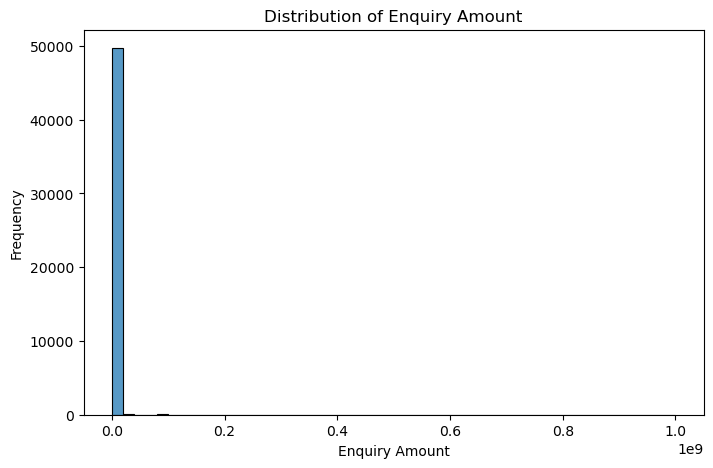

In [1046]:
plt.figure(figsize=(8, 5))

sns.histplot(
    enquiry_plot_sample[
        "enq_amt"
    ].dropna(),
    bins=50
)

plt.title(
    "Distribution of Enquiry Amount"
)

plt.xlabel(
    "Enquiry Amount"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [1047]:
enquiry_clean[
    "enq_purpose"
].value_counts(
    dropna=False
).head(20)

enq_purpose
10.000    233132
5.000      77647
1.000      22125
6.000      16737
2.000      14750
0.000      14596
13.000     10726
51.000      3691
3.000       1633
7.000       1292
12.000       954
8.000        533
17.000       368
4.000        271
32.000       163
54.000       148
52.000       123
NaN          109
14.000        91
53.000        71
Name: count, dtype: int64

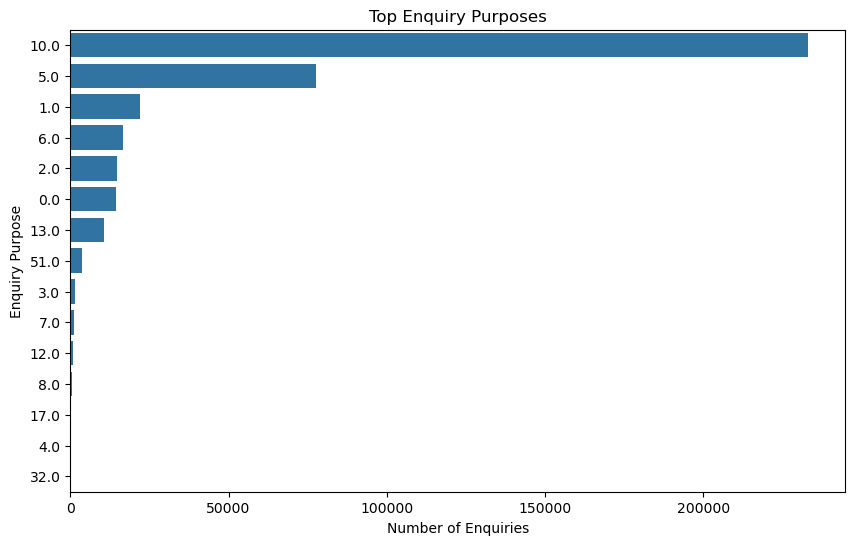

In [1048]:
top_enquiry_purposes = (
    enquiry_clean[
        "enq_purpose"
    ]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_enquiry_purposes.values,
    y=top_enquiry_purposes.index.astype(str)
)

plt.title(
    "Top Enquiry Purposes"
)

plt.xlabel(
    "Number of Enquiries"
)

plt.ylabel(
    "Enquiry Purpose"
)

plt.show()

## ENQUIRIES PER CUSTOMER

In [1050]:
enquiries_per_customer = (
    enquiry_clean
    .groupby("customer_no")
    .size()
)

enquiries_per_customer.describe()

count   23,896.000
mean        16.712
std         14.173
min          1.000
25%          7.000
50%         13.000
75%         22.000
max        189.000
dtype: float64

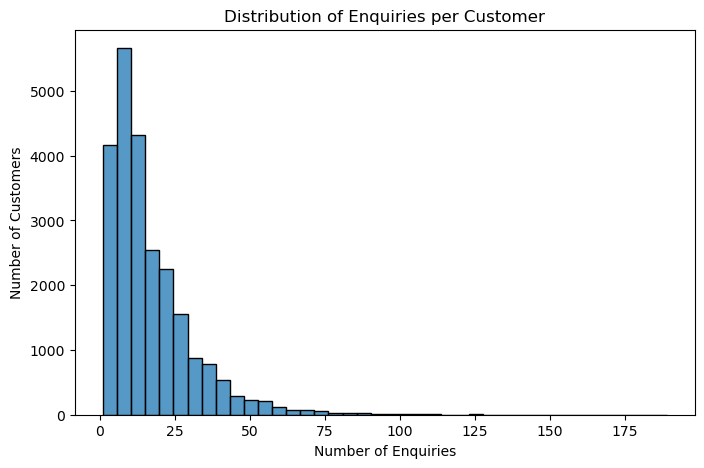

In [1051]:
plt.figure(figsize=(8, 5))

sns.histplot(
    enquiries_per_customer,
    bins=40
)

plt.title(
    "Distribution of Enquiries per Customer"
)

plt.xlabel(
    "Number of Enquiries"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## DEMOGRAPHICS CLEANING

In [1053]:
demographics_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23896 entries, 0 to 23895
Data columns (total 83 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dt_opened    23896 non-null  object 
 1   customer_no  23896 non-null  object 
 2   entry_time   23881 non-null  object 
 3   feature_1    23881 non-null  object 
 4   feature_2    21060 non-null  object 
 5   feature_3    21060 non-null  float64
 6   feature_4    23881 non-null  float64
 7   feature_5    23881 non-null  object 
 8   feature_6    23881 non-null  float64
 9   feature_7    23881 non-null  float64
 10  feature_8    1261 non-null   object 
 11  feature_9    1261 non-null   object 
 12  feature_10   51 non-null     object 
 13  feature_11   23881 non-null  object 
 14  feature_12   23881 non-null  object 
 15  feature_13   10892 non-null  object 
 16  feature_14   16163 non-null  float64
 17  feature_15   23873 non-null  object 
 18  feature_16   23869 non-null  object 
 19  feat

In [1054]:
feature_cols = [
    col
    for col in demographics_clean.columns
    if col.startswith("feature_")
]

print(
    "Number of feature columns:",
    len(feature_cols)
)

print(feature_cols)

Number of feature columns: 79
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_69', 'feature_70'

In [1055]:
demographics_clean[
    feature_cols
].dtypes.value_counts()

object     47
float64    32
Name: count, dtype: int64

In [1056]:
demo_numeric_features = (
    demographics_clean[
        feature_cols
    ]
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

demo_categorical_features = [
    col
    for col in feature_cols
    if col not in demo_numeric_features
]

print(
    "Numerical demographic features:",
    len(demo_numeric_features)
)

print(
    "Categorical/object demographic features:",
    len(demo_categorical_features)
)

Numerical demographic features: 32
Categorical/object demographic features: 47


In [1057]:
print(
    "Object features:",
    demo_categorical_features
)

Object features: ['feature_1', 'feature_2', 'feature_5', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_50', 'feature_51', 'feature_53', 'feature_54', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_70', 'feature_72', 'feature_73', 'feature_75', 'feature_77', 'feature_79']


## DEMOGRAPHICS MISSING VALUES

In [1059]:
demo_missing = pd.DataFrame({

    "Missing_Count":
        demographics_clean.isnull().sum(),

    "Missing_Percentage":
        demographics_clean.isnull().mean() * 100
})

demo_missing = (
    demo_missing
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

demo_missing.head(30)

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
feature_17,22869,95.702
feature_8,22635,94.723
feature_9,22635,94.723
feature_57,21503,89.986
feature_73,20951,87.676


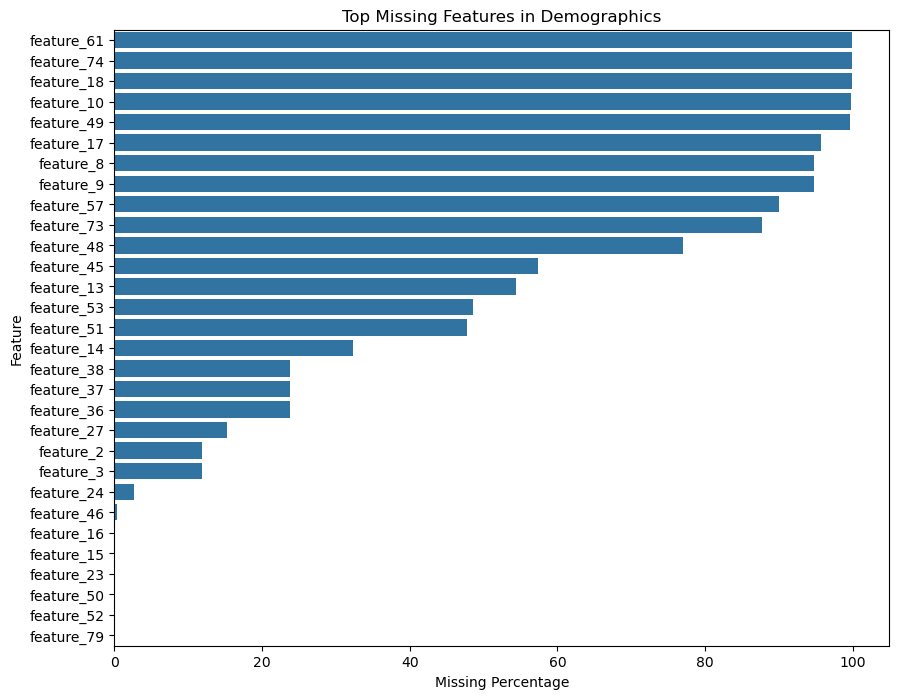

In [1060]:
demo_missing_plot = (
    demo_missing[
        demo_missing[
            "Missing_Percentage"
        ] > 0
    ]
    .head(30)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=demo_missing_plot[
        "Missing_Percentage"
    ].values,
    y=demo_missing_plot.index
)

plt.title(
    "Top Missing Features in Demographics"
)

plt.xlabel(
    "Missing Percentage"
)

plt.ylabel(
    "Feature"
)

plt.show()

## TARGET EDA

In [1062]:
target_counts = (
    demographics_clean[
        "bad_label"
    ]
    .value_counts()
    .sort_index()
)

target_counts

bad_label
0    22892
1     1004
Name: count, dtype: int64

In [1063]:
target_percentages = (
    demographics_clean[
        "bad_label"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
)

target_percentages

bad_label
0   95.798
1    4.202
Name: proportion, dtype: float64

In [1064]:
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary

,Count,Percentage
bad_label,,
0,22892,95.798
1,1004,4.202


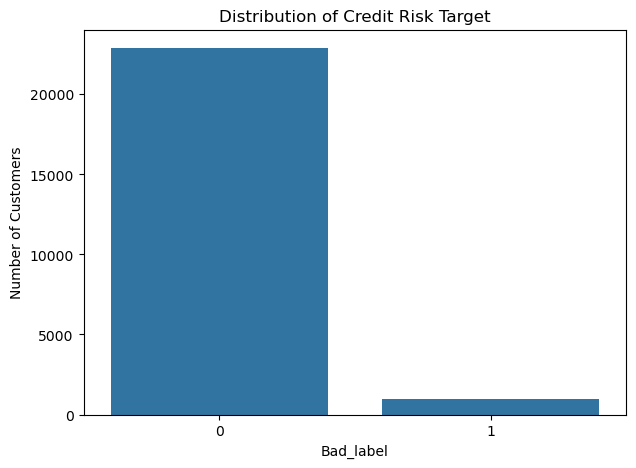

In [1065]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=demographics_clean,
    x="bad_label"
)

plt.title(
    "Distribution of Credit Risk Target"
)

plt.xlabel(
    "Bad_label"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## DEMOGRAPHIC NUMERICAL EDA

In [1067]:
demographics_clean[
    demo_numeric_features
].describe().T

,count,mean,std,min,25%,50%,75%,max
feature_3,"21,060.000",723.236,37.319,-1.000,698.000,721.000,745.000,896.000
feature_4,"23,881.000",2.322,0.893,1.000,1.000,3.000,3.000,3.000
feature_6,"23,881.000",14.000,0.000,14.000,14.000,14.000,14.000,14.000
feature_7,"23,881.000","119,070.504","77,523.485",0.000,"72,000.000","104,000.000","139,000.000","1,217,000.000"
feature_14,"16,163.000",8.087,5.626,0.000,0.000,12.000,12.000,12.000
feature_19,"23,881.000",1.049,0.217,1.000,1.000,1.000,1.000,2.000
feature_25,"23,881.000",1.234,0.423,1.000,1.000,1.000,1.000,2.000
feature_26,"23,881.000",0.726,1.125,0.000,0.000,0.000,2.000,10.000
feature_29,"23,881.000","217,620.229","159,267.102","110,001.000","110,051.000","110,094.000","390,002.000","712,245.000"
feature_30,"23,881.000","2,001.184",11.993,"1,964.000","1,991.000","2,005.000","2,011.000","2,015.000"


In [1068]:
feature_unique_counts = (
    demographics_clean[
        feature_cols
    ]
    .nunique(
        dropna=False
    )
    .sort_values()
)

feature_unique_counts.head(20)

feature_5     2
feature_6     2
feature_54    2
feature_79    3
feature_25    3
feature_23    3
feature_50    3
feature_19    3
feature_57    3
feature_58    3
feature_59    3
feature_33    3
feature_14    3
feature_62    3
feature_11    3
feature_67    3
feature_72    3
feature_73    3
feature_60    3
feature_68    4
dtype: int64

In [1069]:
constant_demo_features = (
    feature_unique_counts[
        feature_unique_counts <= 1
    ]
    .index
    .tolist()
)

print(
    "Constant demographic features:"
)

print(
    constant_demo_features
)

Constant demographic features:
[]


## OUTLIER ANALYSIS

In [1071]:
def iqr_outlier_summary(
    df,
    columns
):

    results = []

    for col in columns:

        data = df[col].dropna()

        if len(data) == 0:
            continue

        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = (
            (data < lower)
            |
            (data > upper)
        ).sum()

        results.append({
            "Feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage":
                outlier_count
                / len(data)
                * 100
        })

    return pd.DataFrame(results)

In [1072]:
account_outliers = (
    iqr_outlier_summary(
        account_clean,
        [
            col
            for col in account_numeric_cols
            if col in account_clean.columns
        ]
    )
)

account_outliers.sort_values(
    "Outlier_Percentage",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
1,cur_balance_amt,0.000,"21,057.250","21,057.250","-31,585.875","52,643.125",28112,15.284
2,amt_past_due,151.000,"7,641.000","7,490.000","-11,084.000","18,876.000",125,14.451
0,high_credit_amt,"22,978.250","105,898.500","82,920.250","-101,402.125","230,278.875",23574,13.455
7,actualpaymentamount,"3,117.000","18,000.000","14,883.000","-19,207.500","40,324.500",4593,11.317
4,cashlimit,"7,500.000","27,000.000","19,500.000","-21,750.000","56,250.000",2000,5.730
3,creditlimit,"31,000.000","100,000.000","69,000.000","-72,500.000","203,500.000",2048,4.240
6,paymentfrequency,3.000,3.000,0.000,3.000,3.000,118,0.187
5,rateofinterest,13.000,39.960,26.960,-27.440,80.400,0,0.000


In [1073]:
enquiry_outliers = (
    iqr_outlier_summary(
        enquiry_clean,
        ["enq_amt"]
    )
)

enquiry_outliers

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,enq_amt,"10,000.000","121,000.000","111,000.000","-156,500.000","287,500.000",70555,17.672


## CORRELATION — DEMOGRAPHIC NUMERIC FEATURES

In [1075]:
correlation_data = (
    demographics_clean[
        demo_numeric_features
        + ["bad_label"]
    ]
    .corr(numeric_only=True)
)

target_correlations = (
    correlation_data[
        "bad_label"
    ]
    .drop("bad_label")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlations.head(20)

feature_74   -0.172
feature_49    0.099
feature_7    -0.059
feature_52   -0.054
feature_3    -0.045
feature_41   -0.026
feature_26   -0.024
feature_25    0.022
feature_29   -0.019
feature_4     0.017
feature_44   -0.017
feature_39   -0.017
feature_34    0.016
feature_68    0.016
feature_66   -0.013
feature_71    0.010
feature_69   -0.008
feature_35   -0.008
feature_31   -0.007
feature_30    0.006
Name: bad_label, dtype: float64

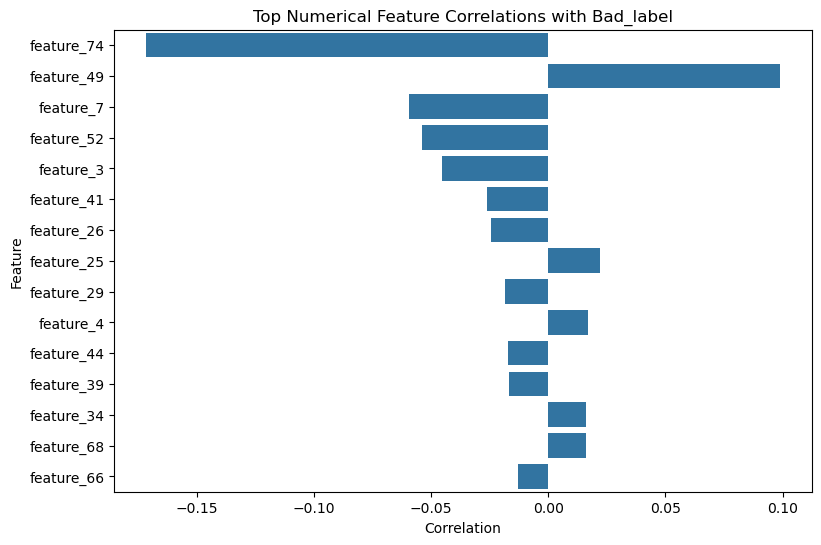

In [1076]:
top_corr = (
    target_correlations
    .head(15)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title(
    "Top Numerical Feature Correlations with Bad_label"
)

plt.xlabel(
    "Correlation"
)

plt.ylabel(
    "Feature"
)

plt.show()

## CHECK CUSTOMER OVERLAP AGAIN AFTER CLEANING

In [1078]:
account_customers = set(
    account_clean[
        "customer_no"
    ]
)

enquiry_customers = set(
    enquiry_clean[
        "customer_no"
    ]
)

demo_customers = set(
    demographics_clean[
        "customer_no"
    ]
)

In [1079]:
print(
    "Demographics customers:",
    len(demo_customers)
)

print(
    "With Account history:",
    len(
        demo_customers
        & account_customers
    )
)

print(
    "With Enquiry history:",
    len(
        demo_customers
        & enquiry_customers
    )
)

print(
    "Without Account history:",
    len(
        demo_customers
        - account_customers
    )
)

print(
    "Without Enquiry history:",
    len(
        demo_customers
        - enquiry_customers
    )
)

Demographics customers: 23896
With Account history: 23896
With Enquiry history: 23896
Without Account history: 0
Without Enquiry history: 0


## QUALITY SUMMARY

In [1081]:
cleaned_summary = pd.DataFrame({

    "Dataset": [
        "Account",
        "Enquiry",
        "Demographics"
    ],

    "Rows": [
        account_clean.shape[0],
        enquiry_clean.shape[0],
        demographics_clean.shape[0]
    ],

    "Columns": [
        account_clean.shape[1],
        enquiry_clean.shape[1],
        demographics_clean.shape[1]
    ],

    "Unique_Customers": [
        account_clean[
            "customer_no"
        ].nunique(),

        enquiry_clean[
            "customer_no"
        ].nunique(),

        demographics_clean[
            "customer_no"
        ].nunique()
    ],

    "Duplicate_Rows": [
        account_clean
        .duplicated()
        .sum(),

        enquiry_clean
        .duplicated()
        .sum(),

        demographics_clean
        .duplicated()
        .sum()
    ],

    "Missing_Values": [
        account_clean
        .isnull()
        .sum()
        .sum(),

        enquiry_clean
        .isnull()
        .sum()
        .sum(),

        demographics_clean
        .isnull()
        .sum()
        .sum()
    ]
})

cleaned_summary

,Dataset,Rows,Columns,Unique_Customers,Duplicate_Rows,Missing_Values
0,Account,183928,21,23896,0,1139690
1,Enquiry,399361,6,23896,0,436
2,Demographics,23896,83,23896,0,333644


In [1082]:
print("ACCOUNT NUMERIC TYPES")
print("=" * 60)

for col in account_numeric_cols:

    if col in account_clean.columns:

        print(
            col,
            ":",
            account_clean[col].dtype
        )


print("\nENQUIRY AMOUNT TYPE")
print("=" * 60)

print(
    enquiry_clean[
        "enq_amt"
    ].dtype
)


print("\nTARGET TYPE")
print("=" * 60)

print(
    demographics_clean[
        "bad_label"
    ].dtype
)

ACCOUNT NUMERIC TYPES
high_credit_amt : float64
cur_balance_amt : int64
amt_past_due : float64
creditlimit : float64
cashlimit : float64
rateofinterest : float64
paymentfrequency : float64
actualpaymentamount : float64

ENQUIRY AMOUNT TYPE
float64

TARGET TYPE
int32


In [1083]:
account_clean.to_csv(
    os.path.join(
        data_folder,
        "account_clean.csv"
    ),
    index=False
)

enquiry_clean.to_csv(
    os.path.join(
        data_folder,
        "enquiry_clean.csv"
    ),
    index=False
)

demographics_clean.to_csv(
    os.path.join(
        data_folder,
        "demographics_clean.csv"
    ),
    index=False
)

print(
    "Cleaned datasets saved successfully!"
)

Cleaned datasets saved successfully!


In [1084]:
for file in [
    "account_clean.csv",
    "enquiry_clean.csv",
    "demographics_clean.csv"
]:

    path = os.path.join(
        data_folder,
        file
    )

    print(
        file,
        "→",
        os.path.exists(path)
    )

account_clean.csv → True
enquiry_clean.csv → True
demographics_clean.csv → True


## Exploratory Data Analysis — Key Observations

### Account Dataset

The Account dataset contains multiple historical account records for
individual customers. Therefore, the dataset cannot be directly merged
with the customer-level demographic dataset.

Account-level information must first be aggregated into customer-level
features.

The dataset contains financial variables such as current balance,
high credit amount, credit limit, past-due amount and actual payment
amount.

The paymenthistory1 and paymenthistory2 variables were examined for
historical DPD information. In the available dataset, these fields did
not contain usable observations and were therefore excluded rather than
artificially imputed.

Missing values in financial variables were retained at this stage and
will be handled appropriately during model preprocessing.

Extreme financial values were identified during outlier analysis.
However, they were not automatically removed because extreme credit
behaviour can contain meaningful risk information.


### Enquiry Dataset

The Enquiry dataset contains multiple historical credit enquiries for
individual customers.

The enquiry amount and enquiry date fields will be used to construct
customer-level enquiry features.

Features such as total enquiry count, recent enquiry count, enquiry
amount statistics and enquiry recency will be created during feature
engineering.


### Demographics Dataset

The Demographics dataset represents the customer-level application
data and contains the target variable Bad_label.

Bad_label = 0 represents good credit history, while Bad_label = 1
represents bad credit history.

The demographic variables are anonymized. Therefore, no unsupported
business interpretation is assigned to individual feature numbers.

Missing values, constant variables and feature distributions were
examined before modeling.


### Modeling Considerations

The final machine-learning dataset must contain one row per customer.

Therefore:

Account records → customer-level account features

Enquiry records → customer-level enquiry features

These engineered features will then be merged with the customer-level
Demographics dataset.

Model evaluation will consider classification metrics, ROC-AUC, Gini
coefficient and rank ordering rather than relying only on accuracy.

In [1086]:
print("=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print(
    "Account shape:",
    account_clean.shape
)

print(
    "Enquiry shape:",
    enquiry_clean.shape
)

print(
    "Demographics shape:",
    demographics_clean.shape
)

print(
    "\nAccount exact duplicates:",
    account_clean
    .duplicated()
    .sum()
)

print(
    "Enquiry exact duplicates:",
    enquiry_clean
    .duplicated()
    .sum()
)

print(
    "Demographics exact duplicates:",
    demographics_clean
    .duplicated()
    .sum()
)

print(
    "\nMissing Account customer IDs:",
    account_clean[
        "customer_no"
    ].isna().sum()
)

print(
    "Missing Enquiry customer IDs:",
    enquiry_clean[
        "customer_no"
    ].isna().sum()
)

print(
    "Missing Demographic customer IDs:",
    demographics_clean[
        "customer_no"
    ].isna().sum()
)

print(
    "\nMissing target values:",
    demographics_clean[
        "bad_label"
    ].isna().sum()
)

print(
    "Target classes:",
    sorted(
        demographics_clean[
            "bad_label"
        ].unique()
    )
)



FINAL VALIDATION
Account shape: (183928, 21)
Enquiry shape: (399361, 6)
Demographics shape: (23896, 83)

Account exact duplicates: 0
Enquiry exact duplicates: 0
Demographics exact duplicates: 0

Missing Account customer IDs: 0
Missing Enquiry customer IDs: 0
Missing Demographic customer IDs: 0

Missing target values: 0
Target classes: [0, 1]


## Account Feature Engineering

## Objective

The Cust_Account dataset contains multiple historical account records
for each customer.

Machine-learning models require a customer-level feature matrix.
Therefore, account-level records are transformed into meaningful
customer-level features.

The feature-engineering process includes:

- Account count features
- Account age features
- Open and closed account features
- Balance features
- Credit-limit features
- High-credit features
- Past-due features
- Payment features
- Interest-rate features
- Payment-recency features
- Credit-utilization ratios
- Customer-level aggregation

The final output of this stage contains one row per customer.

In [1088]:
account_work = account_clean.copy()

print("Account working copy created.")
print("Shape:", account_work.shape)

Account working copy created.
Shape: (183928, 21)


In [1089]:
display(account_work.head())

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,2015-11-10,12265,2015-10-20,6,1,2013-06-09,2014-06-30,2014-07-05,2015-09-30,"20,900.000",0,NaN,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",NaN,2015-09-01,2014-07-01,NaN,NaN,NaN,NaN,NaN
1,2015-11-10,12265,2015-10-20,10,1,2012-05-25,2015-09-06,NaT,2015-10-03,"16,201.000",10390,NaN,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",2015-10-01,2012-11-01,"14,000.000","1,400.000",NaN,3.000,"5,603.000"
2,2015-11-10,12265,2015-10-20,10,1,2012-03-22,2015-08-31,NaT,2015-09-30,"41,028.000",34420,NaN,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",2015-09-01,2012-10-01,NaN,NaN,NaN,NaN,NaN
3,2015-07-20,15606,2015-07-09,10,1,2006-01-13,NaT,2007-07-26,2009-01-31,"93,473.000",0,NaN,"""""""1200900600600600300000000000000000000000000...",NaN,2007-07-01,2006-02-01,NaN,NaN,NaN,NaN,NaN
4,2015-07-20,15606,2015-07-09,6,1,2015-01-18,2015-05-05,NaT,2015-05-31,"20,250.000",13500,NaN,"""""""000000000000000""""""",NaN,2015-05-01,2015-01-01,NaN,NaN,NaN,NaN,NaN


In [1090]:
print("ACCOUNT COLUMNS")
print("=" * 70)

for i, col in enumerate(
    account_work.columns,
    start=1
):
    print(f"{i}. {col}")

ACCOUNT COLUMNS
1. dt_opened
2. customer_no
3. upload_dt
4. acct_type
5. owner_indic
6. opened_dt
7. last_paymt_dt
8. closed_dt
9. reporting_dt
10. high_credit_amt
11. cur_balance_amt
12. amt_past_due
13. paymenthistory1
14. paymenthistory2
15. paymt_str_dt
16. paymt_end_dt
17. creditlimit
18. cashlimit
19. rateofinterest
20. paymentfrequency
21. actualpaymentamount


In [1091]:
print("Total account records:",
      len(account_work))

print(
    "Unique customers:",
    account_work["customer_no"].nunique()
)

print(
    "Average records per customer:",
    len(account_work)
    / account_work["customer_no"].nunique()
)

Total account records: 183928
Unique customers: 23896
Average records per customer: 7.697020421827921


In [1092]:
financial_cols = [
    "high_credit_amt",
    "cur_balance_amt",
    "amt_past_due",
    "creditlimit",
    "cashlimit",
    "rateofinterest",
    "paymentfrequency",
    "actualpaymentamount"
]

for col in financial_cols:

    if col in account_work.columns:

        account_work[col] = pd.to_numeric(
            account_work[col],
            errors="coerce"
        )

print("Financial columns converted to numeric.")

Financial columns converted to numeric.


In [1093]:
print("FINANCIAL DATATYPES")
print("=" * 60)

for col in financial_cols:

    if col in account_work.columns:

        print(
            f"{col:25}",
            account_work[col].dtype
        )

FINANCIAL DATATYPES
high_credit_amt           float64
cur_balance_amt           int64
amt_past_due              float64
creditlimit               float64
cashlimit                 float64
rateofinterest            float64
paymentfrequency          float64
actualpaymentamount       float64


In [1094]:
date_cols = [
    "dt_opened",
    "upload_dt",
    "opened_dt",
    "last_paymt_dt",
    "closed_dt",
    "reporting_dt",
    "paymt_str_dt",
    "paymt_end_dt"
]

for col in date_cols:

    if col in account_work.columns:

        if not pd.api.types.is_datetime64_any_dtype(
            account_work[col]
        ):

            account_work[col] = pd.to_datetime(
                account_work[col],
                errors="coerce"
            )

print("Date columns verified.")

Date columns verified.


In [1095]:
for col in date_cols:

    if col in account_work.columns:

        print(
            f"{col:20}",
            "Min:",
            account_work[col].min(),
            "| Max:",
            account_work[col].max()
        )

dt_opened            Min: 2015-04-16 00:00:00 | Max: 2015-12-31 00:00:00
upload_dt            Min: 2015-04-21 00:00:00 | Max: 2015-12-31 00:00:00
opened_dt            Min: 1979-10-01 00:00:00 | Max: 2015-12-15 00:00:00
last_paymt_dt        Min: 1993-02-20 00:00:00 | Max: 2015-12-10 00:00:00
closed_dt            Min: 1993-10-14 00:00:00 | Max: 2015-12-11 00:00:00
reporting_dt         Min: 2004-02-14 00:00:00 | Max: 2015-12-20 00:00:00
paymt_str_dt         Min: 1993-10-01 00:00:00 | Max: 2015-12-01 00:00:00
paymt_end_dt         Min: 1993-02-01 00:00:00 | Max: 2015-12-01 00:00:00


In [1096]:
REFERENCE_DATE = (
    account_work["reporting_dt"].max()
)

print(
    "Reference Date:",
    REFERENCE_DATE
)

Reference Date: 2015-12-20 00:00:00


In [1097]:
if pd.isna(REFERENCE_DATE):

    REFERENCE_DATE = (
        account_work["upload_dt"].max()
    )

print(
    "Final Reference Date:",
    REFERENCE_DATE
)

Final Reference Date: 2015-12-20 00:00:00


In [1098]:
account_work[
    "account_age_months"
] = (
    (
        REFERENCE_DATE
        - account_work["opened_dt"]
    ).dt.days
    / 30.44
)

In [1099]:
account_work[
    "account_age_months"
].describe()

count   183,502.000
mean         53.784
std          43.968
min           0.164
25%          18.068
50%          37.516
75%          90.210
max         434.593
Name: account_age_months, dtype: float64

In [1100]:
print(
    "Negative account ages:",
    (
        account_work[
            "account_age_months"
        ] < 0
    ).sum()
)

Negative account ages: 0


In [1101]:
account_work[
    "months_since_last_payment"
] = (
    (
        REFERENCE_DATE
        - account_work["last_paymt_dt"]
    ).dt.days
    / 30.44
)

In [1102]:
account_work[
    "months_since_last_payment"
].describe()

count   158,833.000
mean         24.961
std          31.023
min           0.329
25%           5.519
50%           9.363
75%          33.936
max         273.916
Name: months_since_last_payment, dtype: float64

In [1103]:
account_work[
    "open_to_lastpayment_months"
] = (
    (
        account_work["last_paymt_dt"]
        - account_work["opened_dt"]
    ).dt.days
    / 30.44
)

In [1104]:
account_work[
    "open_to_lastpayment_months"
].describe()

count   158,764.000
mean         26.452
std          27.789
min        -140.802
25%           8.147
50%          16.984
75%          35.020
max         298.292
Name: open_to_lastpayment_months, dtype: float64

In [1105]:
account_work[
    "payment_history_period_months"
] = (
    (
        account_work["paymt_str_dt"]
        - account_work["paymt_end_dt"]
    ).dt.days.abs()
    / 30.44
)

In [1106]:
account_work[
    "payment_history_period_months"
].describe()

count   183,927.000
mean         17.473
std          13.404
min           0.000
25%           5.026
50%          14.947
75%          34.954
max          38.009
Name: payment_history_period_months, dtype: float64

In [1107]:
account_work[
    "is_open_account"
] = (
    account_work["closed_dt"]
    .isna()
    .astype(int)
)

In [1108]:
account_work[
    "is_closed_account"
] = (
    account_work["closed_dt"]
    .notna()
    .astype(int)
)

In [1109]:
print(
    "Open account records:"
)

print(
    account_work[
        "is_open_account"
    ].value_counts()
)

print(
    "\nClosed account records:"
)

print(
    account_work[
        "is_closed_account"
    ].value_counts()
)

Open account records:
is_open_account
1    107775
0     76153
Name: count, dtype: int64

Closed account records:
is_closed_account
0    107775
1     76153
Name: count, dtype: int64


In [1110]:
account_work[
    "amt_past_due"
].describe()

count         865.000
mean       24,857.146
std       201,328.907
min             1.000
25%           151.000
50%         1,200.000
75%         7,641.000
max     4,869,309.000
Name: amt_past_due, dtype: float64

In [1111]:
account_work[
    "has_past_due"
] = (
    account_work[
        "amt_past_due"
    ]
    .fillna(0)
    .gt(0)
    .astype(int)
)

In [1112]:
account_work[
    "has_past_due"
].value_counts()

has_past_due
0    183063
1       865
Name: count, dtype: int64

In [1113]:
account_work[
    "balance_creditlimit_ratio"
] = np.where(

    account_work[
        "creditlimit"
    ] > 0,

    account_work[
        "cur_balance_amt"
    ]
    / account_work[
        "creditlimit"
    ],

    np.nan
)

In [1114]:
account_work[
    "balance_creditlimit_ratio"
].describe()

count   48,299.000
mean         0.400
std         25.494
min         -2.552
25%          0.000
50%          0.068
75%          0.456
max      5,602.000
Name: balance_creditlimit_ratio, dtype: float64

In [1115]:
account_work[
    "balance_highcredit_ratio"
] = np.where(

    account_work[
        "high_credit_amt"
    ] > 0,

    account_work[
        "cur_balance_amt"
    ]
    / account_work[
        "high_credit_amt"
    ],

    np.nan
)

In [1116]:
account_work[
    "pastdue_balance_ratio"
] = np.where(

    account_work[
        "cur_balance_amt"
    ].abs() > 0,

    account_work[
        "amt_past_due"
    ]
    / account_work[
        "cur_balance_amt"
    ].abs(),

    np.nan
)

In [1117]:
account_work[
    "pastdue_creditlimit_ratio"
] = np.where(

    account_work[
        "creditlimit"
    ] > 0,

    account_work[
        "amt_past_due"
    ]
    / account_work[
        "creditlimit"
    ],

    np.nan
)

In [1118]:
account_work[
    "payment_balance_ratio"
] = np.where(

    account_work[
        "cur_balance_amt"
    ].abs() > 0,

    account_work[
        "actualpaymentamount"
    ]
    / account_work[
        "cur_balance_amt"
    ].abs(),

    np.nan
)

In [1119]:
account_work[
    "payment_highcredit_ratio"
] = np.where(

    account_work[
        "high_credit_amt"
    ] > 0,

    account_work[
        "actualpaymentamount"
    ]
    / account_work[
        "high_credit_amt"
    ],

    np.nan
)

In [1120]:
account_work.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [1121]:
engineered_numeric_cols = [
    "account_age_months",
    "months_since_last_payment",
    "open_to_lastpayment_months",
    "payment_history_period_months",
    "is_open_account",
    "is_closed_account",
    "has_past_due",
    "balance_creditlimit_ratio",
    "balance_highcredit_ratio",
    "pastdue_balance_ratio",
    "pastdue_creditlimit_ratio",
    "payment_balance_ratio",
    "payment_highcredit_ratio"
]

for col in engineered_numeric_cols:

    account_work[col] = pd.to_numeric(
        account_work[col],
        errors="coerce"
    )

In [1122]:
aggregation_numeric_cols = [
    "high_credit_amt",
    "cur_balance_amt",
    "amt_past_due",
    "creditlimit",
    "cashlimit",
    "rateofinterest",
    "actualpaymentamount",
    "account_age_months",
    "months_since_last_payment",
    "open_to_lastpayment_months",
    "payment_history_period_months",
    "balance_creditlimit_ratio",
    "balance_highcredit_ratio",
    "pastdue_balance_ratio",
    "pastdue_creditlimit_ratio",
    "payment_balance_ratio",
    "payment_highcredit_ratio"
]

print("DATATYPE CHECK")
print("=" * 70)

for col in aggregation_numeric_cols:

    print(
        f"{col:40}",
        account_work[col].dtype
    )

DATATYPE CHECK
high_credit_amt                          float64
cur_balance_amt                          int64
amt_past_due                             float64
creditlimit                              float64
cashlimit                                float64
rateofinterest                           float64
actualpaymentamount                      float64
account_age_months                       float64
months_since_last_payment                float64
open_to_lastpayment_months               float64
payment_history_period_months            float64
balance_creditlimit_ratio                float64
balance_highcredit_ratio                 float64
pastdue_balance_ratio                    float64
pastdue_creditlimit_ratio                float64
payment_balance_ratio                    float64
payment_highcredit_ratio                 float64


In [1123]:
problem_cols = [
    col
    for col in aggregation_numeric_cols
    if account_work[col].dtype == "object"
]

print(
    "Problem columns:",
    problem_cols
)

Problem columns: []


In [1124]:
test_account_features = (
    account_work
    .groupby(
        "customer_no"
    )
    .agg(

        total_accounts=(
            "acct_type",
            "size"
        ),

        mean_current_balance=(
            "cur_balance_amt",
            "mean"
        ),

        mean_credit_limit=(
            "creditlimit",
            "mean"
        ),

        mean_past_due=(
            "amt_past_due",
            "mean"
        ),

        mean_actual_payment=(
            "actualpaymentamount",
            "mean"
        )
    )
    .reset_index()
)

display(
    test_account_features.head()
)

,customer_no,total_accounts,mean_current_balance,mean_credit_limit,mean_past_due,mean_actual_payment
0,1,18,"261,936.500","335,000.000","1,269,104.500","35,543.000"
1,10,12,"20,643.250","405,000.000",NaN,"200,000.000"
2,100,9,"48,269.444","62,333.333",NaN,"5,000.000"
3,1000,3,"20,154.000","247,500.000",NaN,"23,310.000"
4,10000,6,"181,026.333","60,000.000",NaN,"51,500.000"


In [1125]:
account_features = (
    account_work
    .groupby(
        "customer_no"
    )
    .agg(

        # =================================
        # ACCOUNT COUNT FEATURES
        # =================================

        total_accounts=(
            "acct_type",
            "size"
        ),

        unique_account_types=(
            "acct_type",
            "nunique"
        ),

        unique_ownership_types=(
            "owner_indic",
            "nunique"
        ),

        # =================================
        # OPEN / CLOSED ACCOUNTS
        # =================================

        open_accounts=(
            "is_open_account",
            "sum"
        ),

        closed_accounts=(
            "is_closed_account",
            "sum"
        ),

        # =================================
        # ACCOUNT AGE
        # =================================

        mean_account_age_months=(
            "account_age_months",
            "mean"
        ),

        max_account_age_months=(
            "account_age_months",
            "max"
        ),

        min_account_age_months=(
            "account_age_months",
            "min"
        ),

        # =================================
        # CURRENT BALANCE
        # =================================

        total_current_balance=(
            "cur_balance_amt",
            "sum"
        ),

        mean_current_balance=(
            "cur_balance_amt",
            "mean"
        ),

        max_current_balance=(
            "cur_balance_amt",
            "max"
        ),

        # =================================
        # HIGH CREDIT
        # =================================

        total_high_credit=(
            "high_credit_amt",
            "sum"
        ),

        mean_high_credit=(
            "high_credit_amt",
            "mean"
        ),

        max_high_credit=(
            "high_credit_amt",
            "max"
        ),

        # =================================
        # CREDIT LIMIT
        # =================================

        total_credit_limit=(
            "creditlimit",
            "sum"
        ),

        mean_credit_limit=(
            "creditlimit",
            "mean"
        ),

        max_credit_limit=(
            "creditlimit",
            "max"
        ),

        # =================================
        # CASH LIMIT
        # =================================

        total_cash_limit=(
            "cashlimit",
            "sum"
        ),

        mean_cash_limit=(
            "cashlimit",
            "mean"
        ),

        max_cash_limit=(
            "cashlimit",
            "max"
        ),

        # =================================
        # PAST DUE
        # =================================

        total_past_due=(
            "amt_past_due",
            "sum"
        ),

        mean_past_due=(
            "amt_past_due",
            "mean"
        ),

        max_past_due=(
            "amt_past_due",
            "max"
        ),

        accounts_with_past_due=(
            "has_past_due",
            "sum"
        ),

        ever_past_due=(
            "has_past_due",
            "max"
        ),

        # =================================
        # ACTUAL PAYMENT
        # =================================

        total_actual_payment=(
            "actualpaymentamount",
            "sum"
        ),

        mean_actual_payment=(
            "actualpaymentamount",
            "mean"
        ),

        max_actual_payment=(
            "actualpaymentamount",
            "max"
        ),

        # =================================
        # INTEREST RATE
        # =================================

        mean_interest_rate=(
            "rateofinterest",
            "mean"
        ),

        max_interest_rate=(
            "rateofinterest",
            "max"
        ),

        # =================================
        # LAST PAYMENT RECENCY
        # =================================

        min_months_since_last_payment=(
            "months_since_last_payment",
            "min"
        ),

        mean_months_since_last_payment=(
            "months_since_last_payment",
            "mean"
        ),

        max_months_since_last_payment=(
            "months_since_last_payment",
            "max"
        ),

        # =================================
        # OPEN DATE → LAST PAYMENT
        # =================================

        mean_open_to_lastpayment_months=(
            "open_to_lastpayment_months",
            "mean"
        ),

        max_open_to_lastpayment_months=(
            "open_to_lastpayment_months",
            "max"
        ),

        # =================================
        # PAYMENT HISTORY DATE SPAN
        # =================================

        mean_payment_history_period=(
            "payment_history_period_months",
            "mean"
        ),

        max_payment_history_period=(
            "payment_history_period_months",
            "max"
        ),

        # =================================
        # UTILIZATION
        # =================================

        mean_balance_creditlimit_ratio=(
            "balance_creditlimit_ratio",
            "mean"
        ),

        max_balance_creditlimit_ratio=(
            "balance_creditlimit_ratio",
            "max"
        ),

        # =================================
        # HIGH CREDIT RATIOS
        # =================================

        mean_balance_highcredit_ratio=(
            "balance_highcredit_ratio",
            "mean"
        ),

        max_balance_highcredit_ratio=(
            "balance_highcredit_ratio",
            "max"
        ),

        # =================================
        # PAST-DUE RATIOS
        # =================================

        mean_pastdue_balance_ratio=(
            "pastdue_balance_ratio",
            "mean"
        ),

        max_pastdue_balance_ratio=(
            "pastdue_balance_ratio",
            "max"
        ),

        mean_pastdue_creditlimit_ratio=(
            "pastdue_creditlimit_ratio",
            "mean"
        ),

        max_pastdue_creditlimit_ratio=(
            "pastdue_creditlimit_ratio",
            "max"
        ),

        # =================================
        # PAYMENT RATIOS
        # =================================

        mean_payment_balance_ratio=(
            "payment_balance_ratio",
            "mean"
        ),

        mean_payment_highcredit_ratio=(
            "payment_highcredit_ratio",
            "mean"
        )
    )
    .reset_index()
)

In [1126]:
account_features[
    "open_account_ratio"
] = np.where(

    account_features[
        "total_accounts"
    ] > 0,

    account_features[
        "open_accounts"
    ]
    / account_features[
        "total_accounts"
    ],

    np.nan
)

In [1127]:
account_features[
    "closed_account_ratio"
] = np.where(

    account_features[
        "total_accounts"
    ] > 0,

    account_features[
        "closed_accounts"
    ]
    / account_features[
        "total_accounts"
    ],

    np.nan
)

In [1128]:
account_features[
    "past_due_account_ratio"
] = np.where(

    account_features[
        "total_accounts"
    ] > 0,

    account_features[
        "accounts_with_past_due"
    ]
    / account_features[
        "total_accounts"
    ],

    np.nan
)

In [1129]:
account_features[
    "total_balance_creditlimit_ratio"
] = np.where(

    account_features[
        "total_credit_limit"
    ] > 0,

    account_features[
        "total_current_balance"
    ]
    / account_features[
        "total_credit_limit"
    ],

    np.nan
)

In [1130]:
account_features[
    "total_balance_highcredit_ratio"
] = np.where(

    account_features[
        "total_high_credit"
    ] > 0,

    account_features[
        "total_current_balance"
    ]
    / account_features[
        "total_high_credit"
    ],

    np.nan
)

In [1131]:
account_features[
    "total_pastdue_balance_ratio"
] = np.where(

    account_features[
        "total_current_balance"
    ].abs() > 0,

    account_features[
        "total_past_due"
    ]
    / account_features[
        "total_current_balance"
    ].abs(),

    np.nan
)

In [1132]:
account_features[
    "total_pastdue_creditlimit_ratio"
] = np.where(

    account_features[
        "total_credit_limit"
    ] > 0,

    account_features[
        "total_past_due"
    ]
    / account_features[
        "total_credit_limit"
    ],

    np.nan
)

In [1133]:
account_features[
    "total_payment_balance_ratio"
] = np.where(

    account_features[
        "total_current_balance"
    ].abs() > 0,

    account_features[
        "total_actual_payment"
    ]
    / account_features[
        "total_current_balance"
    ].abs(),

    np.nan
)

## FINAL CLEANING

In [1135]:
account_features.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [1136]:
print(
    "Account Feature Matrix Shape:",
    account_features.shape
)

print(
    "Number of rows:",
    len(account_features)
)

print(
    "Unique customers:",
    account_features[
        "customer_no"
    ].nunique()
)

Account Feature Matrix Shape: (23896, 56)
Number of rows: 23896
Unique customers: 23896


In [1137]:
print(
    "Duplicate customer IDs:",
    account_features[
        "customer_no"
    ]
    .duplicated()
    .sum()
)

Duplicate customer IDs: 0


In [1138]:
display(
    account_features.head()
)

,customer_no,total_accounts,unique_account_types,unique_ownership_types,open_accounts,closed_accounts,mean_account_age_months,max_account_age_months,min_account_age_months,total_current_balance,mean_current_balance,max_current_balance,total_high_credit,mean_high_credit,max_high_credit,total_credit_limit,mean_credit_limit,max_credit_limit,total_cash_limit,mean_cash_limit,max_cash_limit,total_past_due,mean_past_due,max_past_due,accounts_with_past_due,ever_past_due,total_actual_payment,mean_actual_payment,max_actual_payment,mean_interest_rate,max_interest_rate,min_months_since_last_payment,mean_months_since_last_payment,max_months_since_last_payment,mean_open_to_lastpayment_months,max_open_to_lastpayment_months,mean_payment_history_period,max_payment_history_period,mean_balance_creditlimit_ratio,max_balance_creditlimit_ratio,mean_balance_highcredit_ratio,max_balance_highcredit_ratio,mean_pastdue_balance_ratio,max_pastdue_balance_ratio,mean_pastdue_creditlimit_ratio,max_pastdue_creditlimit_ratio,mean_payment_balance_ratio,mean_payment_highcredit_ratio,open_account_ratio,closed_account_ratio,past_due_account_ratio,total_balance_creditlimit_ratio,total_balance_highcredit_ratio,total_pastdue_balance_ratio,total_pastdue_creditlimit_ratio,total_payment_balance_ratio
0,1,18,4,2,6,12,153.337,233.968,21.682,4714857,"261,936.500",2528846,"7,900,063.000","526,670.867","2,528,846.000","670,000.000","335,000.000","420,000.000","168,000.000","168,000.000","168,000.000","2,538,209.000","1,269,104.500","2,528,846.000",2,1,"71,086.000","35,543.000","45,986.000",17.711,34.585,9.461,83.893,163.173,49.146,117.904,12.834,35.053,0.163,0.236,0.176,1.000,1.000,1.000,NaN,NaN,0.825,0.179,0.333,0.667,0.111,7.037,0.597,0.538,3.788,0.015
1,10,12,5,3,7,5,118.991,189.783,22.372,247719,"20,643.250",178725,"8,287,800.000","828,780.000","5,500,000.000","405,000.000","405,000.000","405,000.000","243,000.000","243,000.000","243,000.000",0.000,NaN,NaN,0,0,"200,000.000","200,000.000","200,000.000",39.960,39.960,7.063,52.479,139.323,65.440,157.556,21.830,35.053,0.441,0.441,0.053,0.336,NaN,NaN,NaN,NaN,1.119,0.376,0.583,0.417,0.000,0.612,0.030,0.000,0.000,0.807
2,100,9,4,1,6,3,38.794,89.389,15.145,434425,"48,269.444",334609,"954,766.000","106,085.111","354,122.000","187,000.000","62,333.333","98,000.000","27,500.000","13,750.000","17,700.000",0.000,NaN,NaN,0,0,"5,000.000","5,000.000","5,000.000",8.900,8.900,9.560,19.444,60.742,16.713,33.574,13.016,35.053,0.361,0.820,0.293,0.945,NaN,NaN,NaN,NaN,0.322,0.110,0.667,0.333,0.000,2.323,0.455,0.000,0.000,0.012
3,1000,3,1,1,2,1,50.339,63.568,43.725,60462,"20,154.000",31349,"1,244,266.000","414,755.333","548,289.000","495,000.000","247,500.000","270,000.000","148,500.000","74,250.000","81,000.000",0.000,NaN,NaN,0,0,"23,310.000","23,310.000","23,310.000",NaN,NaN,8.607,10.611,13.601,39.728,53.942,15.309,31.997,0.070,0.139,0.085,0.197,NaN,NaN,NaN,NaN,0.744,0.043,0.667,0.333,0.000,0.122,0.049,0.000,0.000,0.386
4,10000,6,3,2,6,0,12.210,21.682,7.884,1086158,"181,026.333",582220,"1,139,014.000","189,835.667","520,000.000","60,000.000","60,000.000","60,000.000","10,000.000","10,000.000","10,000.000",0.000,NaN,NaN,0,0,"51,500.000","51,500.000","51,500.000",20.940,39.000,4.665,6.373,10.315,4.304,5.552,6.455,16.919,0.292,0.292,0.523,1.213,NaN,NaN,NaN,NaN,2.938,0.979,1.000,0.000,0.000,18.103,0.954,0.000,0.000,0.047


In [1139]:
display(
    account_features
    .head()
    .T
)

,0,1,2,3,4
customer_no,1,10,100,1000,10000
total_accounts,18,12,9,3,6
unique_account_types,4,5,4,1,3
unique_ownership_types,2,3,1,1,2
open_accounts,6,7,6,2,6
closed_accounts,12,5,3,1,0
mean_account_age_months,153.337,118.991,38.794,50.339,12.210
max_account_age_months,233.968,189.783,89.389,63.568,21.682
min_account_age_months,21.682,22.372,15.145,43.725,7.884
total_current_balance,4714857,247719,434425,60462,1086158


In [1140]:
print("ACCOUNT FEATURE MATRIX")
print("=" * 70)

for i, col in enumerate(
    account_features.columns,
    start=1
):

    print(
        f"{i}. {col}"
    )

ACCOUNT FEATURE MATRIX
1. customer_no
2. total_accounts
3. unique_account_types
4. unique_ownership_types
5. open_accounts
6. closed_accounts
7. mean_account_age_months
8. max_account_age_months
9. min_account_age_months
10. total_current_balance
11. mean_current_balance
12. max_current_balance
13. total_high_credit
14. mean_high_credit
15. max_high_credit
16. total_credit_limit
17. mean_credit_limit
18. max_credit_limit
19. total_cash_limit
20. mean_cash_limit
21. max_cash_limit
22. total_past_due
23. mean_past_due
24. max_past_due
25. accounts_with_past_due
26. ever_past_due
27. total_actual_payment
28. mean_actual_payment
29. max_actual_payment
30. mean_interest_rate
31. max_interest_rate
32. min_months_since_last_payment
33. mean_months_since_last_payment
34. max_months_since_last_payment
35. mean_open_to_lastpayment_months
36. max_open_to_lastpayment_months
37. mean_payment_history_period
38. max_payment_history_period
39. mean_balance_creditlimit_ratio
40. max_balance_creditlimit

## MISSING-VALUE ANALYSIS

In [1142]:
account_feature_missing = pd.DataFrame({

    "Missing_Count":
        account_features
        .isnull()
        .sum(),

    "Missing_Percentage":
        account_features
        .isnull()
        .mean()
        * 100
})

account_feature_missing = (
    account_feature_missing
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(
    account_feature_missing.head(30)
)

,Missing_Count,Missing_Percentage
max_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_balance_ratio,23133,96.807
max_pastdue_balance_ratio,23133,96.807
mean_past_due,23110,96.711
max_past_due,23110,96.711
mean_interest_rate,10914,45.673
max_interest_rate,10914,45.673
mean_payment_balance_ratio,5509,23.054
mean_cash_limit,5461,22.853


## CONSTANT FEATURE CHECK

In [1144]:
constant_account_features = [
    col

    for col in account_features.columns

    if (
        col != "customer_no"

        and account_features[col]
        .nunique(
            dropna=False
        ) <= 1
    )
]

print(
    "Constant account features:"
)

print(
    constant_account_features
)

Constant account features:
[]


In [1145]:
numeric_account_features = (
    account_features
    .select_dtypes(
        include=np.number
    )
)

print(
    "Infinite values:",
    np.isinf(
        numeric_account_features
    ).sum().sum()
)

Infinite values: 0


In [1146]:
display(
    account_features
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
total_accounts,"23,896.000",7.697,6.454,1.000,3.000,6.000,10.000,76.000
unique_account_types,"23,896.000",2.798,1.483,1.000,2.000,3.000,4.000,11.000
unique_ownership_types,"23,896.000",1.244,0.508,1.000,1.000,1.000,1.000,4.000
open_accounts,"23,896.000",4.510,2.947,0.000,2.000,4.000,6.000,34.000
closed_accounts,"23,896.000",3.187,4.411,0.000,0.000,2.000,4.000,54.000
mean_account_age_months,"23,896.000",41.462,27.764,3.515,20.762,32.786,55.488,261.629
max_account_age_months,"23,896.000",73.478,49.865,6.176,33.344,59.888,106.275,434.593
min_account_age_months,"23,896.000",14.551,13.888,0.164,7.055,10.841,16.360,261.629
total_current_balance,"23,896.000","588,559.921","2,216,061.859","-6,994,576.000","39,836.750","151,657.000","467,249.500","155,947,255.000"
mean_current_balance,"23,896.000","70,867.439","215,351.070","-1,165,762.667","9,085.636","25,970.922","63,522.286","11,726,594.600"


## ACCOUNT FEATURE EDA

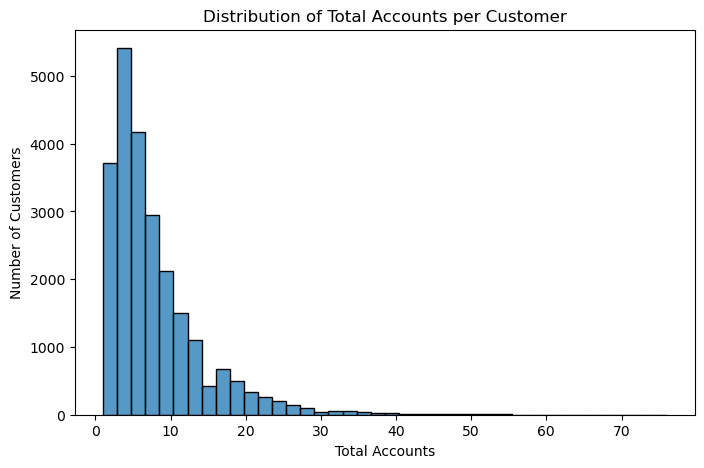

In [1148]:
plt.figure(figsize=(8, 5))

sns.histplot(
    account_features[
        "total_accounts"
    ],
    bins=40
)

plt.title(
    "Distribution of Total Accounts per Customer"
)

plt.xlabel(
    "Total Accounts"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

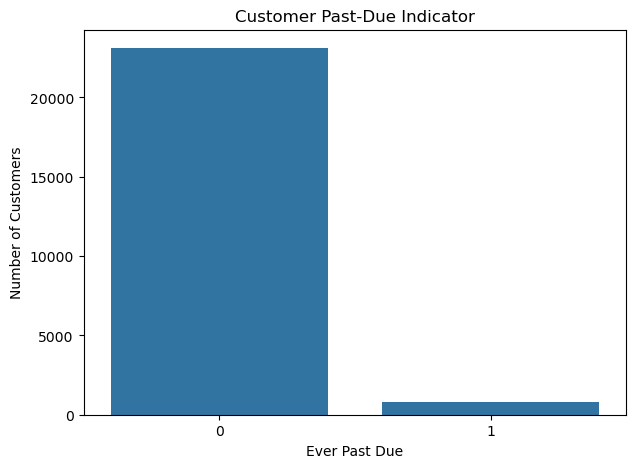

In [1149]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=account_features,
    x="ever_past_due"
)

plt.title(
    "Customer Past-Due Indicator"
)

plt.xlabel(
    "Ever Past Due"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

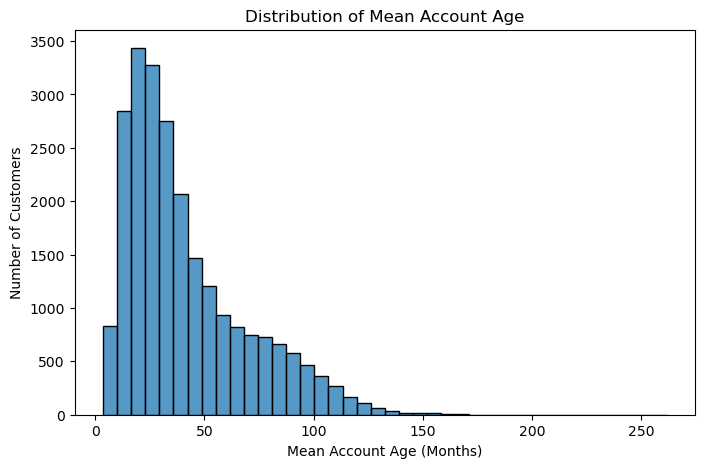

In [1150]:
plt.figure(figsize=(8, 5))

sns.histplot(
    account_features[
        "mean_account_age_months"
    ].dropna(),
    bins=40
)

plt.title(
    "Distribution of Mean Account Age"
)

plt.xlabel(
    "Mean Account Age (Months)"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## FINAL FEATURE MATRIX CHECK

In [1152]:
account_feature_summary = pd.DataFrame({

    "Metric": [
        "Customers",
        "Features",
        "Duplicate Customers",
        "Missing Values",
        "Infinite Values"
    ],

    "Value": [

        len(account_features),

        account_features.shape[1] - 1,

        account_features[
            "customer_no"
        ]
        .duplicated()
        .sum(),

        account_features
        .isnull()
        .sum()
        .sum(),

        np.isinf(
            account_features
            .select_dtypes(
                include=np.number
            )
        )
        .sum()
        .sum()
    ]
})

account_feature_summary

,Metric,Value
0,Customers,23896
1,Features,55
2,Duplicate Customers,0
3,Missing Values,217109
4,Infinite Values,0


In [1153]:
account_feature_path = os.path.join(
    data_folder,
    "account_features_final.csv"
)

account_features.to_csv(
    account_feature_path,
    index=False
)

print(
    "Account Feature Matrix saved successfully."
)

print(
    "Location:",
    account_feature_path
)

Account Feature Matrix saved successfully.
Location: Bank_GoodCredit_Data\account_features_final.csv


In [1154]:
print(
    "File exists:",
    os.path.exists(
        account_feature_path
    )
)

File exists: True


## Account Feature Engineering — Summary

The Cust_Account dataset contains multiple historical account records
for individual customers. Since the target dataset operates at the
customer level, account records were aggregated to construct a
customer-level Account Feature Matrix.

### Account Behaviour Features

Features were constructed to describe the number and diversity of
accounts held by each customer. These include total accounts, unique
account types and ownership diversity.

### Account Age

Account-opening dates were used to calculate account age. Mean,
minimum and maximum account age were calculated for each customer.

### Open and Closed Accounts

The closed-account date was used to distinguish currently open and
closed account records. Customer-level counts and ratios of open and
closed accounts were subsequently calculated.

### Balance and Credit Features

Current balance, high-credit amount, credit limit and cash limit were
aggregated using total, mean and maximum statistics where appropriate.

### Past-Due Behaviour

The available `amt_past_due` field was used to construct past-due
amount features and indicators identifying customers with positive
past-due balances.

The paymenthistory1 and paymenthistory2 fields did not contain usable
observations in the available dataset. Therefore, historical DPD
sequences were not artificially created from missing information.

### Payment Behaviour

Actual payment amounts and last-payment dates were used to construct
payment amount and payment-recency features.

### Credit Utilization

Current balance relative to credit limit was calculated to represent
credit utilization. Additional ratios involving high-credit amount,
past-due amount and payment amount were also engineered.

### Customer-Level Aggregation

All account-level information was aggregated using customer_no.

The resulting Account Feature Matrix contains exactly one row for each
customer and can therefore be safely merged with other customer-level
data in later stages.

In [1156]:
print("=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print(
    "Original Account Records:",
    len(account_clean)
)

print(
    "Original Unique Customers:",
    account_clean[
        "customer_no"
    ].nunique()
)

print(
    "\nFinal Feature Rows:",
    len(account_features)
)

print(
    "Final Unique Customers:",
    account_features[
        "customer_no"
    ].nunique()
)

print(
    "Number of Engineered Features:",
    account_features.shape[1] - 1
)

print(
    "Duplicate Customers:",
    account_features[
        "customer_no"
    ]
    .duplicated()
    .sum()
)

print(
    "Infinite Values:",
    np.isinf(
        account_features
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)

print(
    "Missing Values:",
    account_features
    .isnull()
    .sum()
    .sum()
)



FINAL VALIDATION
Original Account Records: 183928
Original Unique Customers: 23896

Final Feature Rows: 23896
Final Unique Customers: 23896
Number of Engineered Features: 55
Duplicate Customers: 0
Infinite Values: 0
Missing Values: 217109


## Enquiry Feature Engineering

## Objective

The Cust_Enquiry dataset contains historical credit enquiries made
for individual customers.

Since a customer may have multiple enquiry records, the raw enquiry
dataset cannot be directly used as a customer-level machine-learning
feature matrix.

The objective of this stage is to transform enquiry history into
customer-level behavioural features.

Features created include:

- Total enquiry count
- Recent enquiry counts
- Enquiry amount statistics
- Enquiry purpose diversity
- Enquiry recency
- Average time between enquiries
- Recent enquiry amount
- Enquiry-frequency ratios

The final Enquiry Feature Matrix will contain one row per customer.

In [1158]:
enquiry_work = enquiry_clean.copy()

print("Enquiry working copy created.")
print("Shape:", enquiry_work.shape)

display(enquiry_work.head())

Enquiry working copy created.
Shape: (399361, 6)


,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,2015-04-18,1,2015-04-21,2014-12-19,2.000,"3,500,000.000"
1,2015-04-18,1,2015-04-21,2014-03-05,5.000,"500,000.000"
2,2015-04-18,1,2015-04-21,2014-03-05,0.000,"50,000.000"
3,2015-04-18,1,2015-04-21,2014-02-22,10.000,"50,000.000"
4,2015-04-18,1,2015-04-21,2013-06-11,10.000,"1,000.000"


In [1159]:
print("ENQUIRY DATASET COLUMNS")
print("=" * 70)

for i, col in enumerate(
    enquiry_work.columns,
    start=1
):
    print(f"{i}. {col}")

ENQUIRY DATASET COLUMNS
1. dt_opened
2. customer_no
3. upload_dt
4. enquiry_dt
5. enq_purpose
6. enq_amt


In [1160]:
required_enquiry_cols = [
    "customer_no",
    "enquiry_dt",
    "enq_purpose",
    "enq_amt"
]

missing_cols = [
    col
    for col in required_enquiry_cols
    if col not in enquiry_work.columns
]

print(
    "Missing required columns:",
    missing_cols
)

Missing required columns: []


In [1161]:
enquiry_work[
    "enq_amt"
] = pd.to_numeric(
    enquiry_work["enq_amt"],
    errors="coerce"
)

print(
    "enq_amt datatype:",
    enquiry_work[
        "enq_amt"
    ].dtype
)

enq_amt datatype: float64


In [1162]:
if not pd.api.types.is_datetime64_any_dtype(
    enquiry_work["enquiry_dt"]
):

    enquiry_work[
        "enquiry_dt"
    ] = pd.to_datetime(
        enquiry_work[
            "enquiry_dt"
        ],
        errors="coerce"
    )

print(
    enquiry_work[
        "enquiry_dt"
    ].dtype
)

datetime64[ns]


In [1163]:
print(
    "Earliest enquiry:",
    enquiry_work[
        "enquiry_dt"
    ].min()
)

print(
    "Latest enquiry:",
    enquiry_work[
        "enquiry_dt"
    ].max()
)

Earliest enquiry: 2004-07-22 00:00:00
Latest enquiry: 2015-12-23 00:00:00


In [1164]:
if "dt_opened" in enquiry_work.columns:

    if not pd.api.types.is_datetime64_any_dtype(
        enquiry_work["dt_opened"]
    ):

        enquiry_work[
            "dt_opened"
        ] = pd.to_datetime(
            enquiry_work[
                "dt_opened"
            ],
            errors="coerce"
        )

In [1165]:
print(
    "dt_opened range:"
)

print(
    enquiry_work[
        "dt_opened"
    ].min(),
    "to",
    enquiry_work[
        "dt_opened"
    ].max()
)

dt_opened range:
2015-04-16 00:00:00 to 2015-12-31 00:00:00


In [1166]:
enquiry_work[
    "enquiry_recency_days"
] = (
    enquiry_work[
        "dt_opened"
    ]
    -
    enquiry_work[
        "enquiry_dt"
    ]
).dt.days

In [1167]:
enquiry_work[
    "enquiry_recency_days"
].describe()

count   399,252.000
mean      1,095.384
std         945.000
min           2.000
25%         332.000
50%         781.000
75%       1,655.000
max       4,054.000
Name: enquiry_recency_days, dtype: float64

In [1168]:
future_enquiries = (
    enquiry_work[
        "enquiry_recency_days"
    ] < 0
).sum()

print(
    "Enquiries after application date:",
    future_enquiries
)

Enquiries after application date: 0


In [1169]:
enquiry_work[
    "is_valid_historical_enquiry"
] = (
    enquiry_work[
        "enquiry_recency_days"
    ]
    .ge(0)
    .astype(int)
)

In [1170]:
enquiry_work.loc[
    enquiry_work[
        "enquiry_recency_days"
    ].isna(),
    "is_valid_historical_enquiry"
] = 0

In [1171]:
enquiry_work[
    "enquiry_last_30d"
] = (
    enquiry_work[
        "enquiry_recency_days"
    ]
    .between(
        0,
        30,
        inclusive="both"
    )
    .astype(int)
)

In [1172]:
enquiry_work[
    "enquiry_last_90d"
] = (
    enquiry_work[
        "enquiry_recency_days"
    ]
    .between(
        0,
        90,
        inclusive="both"
    )
    .astype(int)
)

In [1173]:
enquiry_work[
    "enquiry_last_180d"
] = (
    enquiry_work[
        "enquiry_recency_days"
    ]
    .between(
        0,
        180,
        inclusive="both"
    )
    .astype(int)
)

In [1174]:
enquiry_work[
    "enquiry_last_365d"
] = (
    enquiry_work[
        "enquiry_recency_days"
    ]
    .between(
        0,
        365,
        inclusive="both"
    )
    .astype(int)
)

In [1175]:
print(
    "Records within 30 days:",
    enquiry_work[
        "enquiry_last_30d"
    ].sum()
)

print(
    "Records within 90 days:",
    enquiry_work[
        "enquiry_last_90d"
    ].sum()
)

print(
    "Records within 180 days:",
    enquiry_work[
        "enquiry_last_180d"
    ].sum()
)

print(
    "Records within 365 days:",
    enquiry_work[
        "enquiry_last_365d"
    ].sum()
)

Records within 30 days: 4947
Records within 90 days: 24487
Records within 180 days: 53592
Records within 365 days: 108988


In [1176]:
enquiry_work[
    "enquiry_amt_30d"
] = np.where(

    enquiry_work[
        "enquiry_last_30d"
    ] == 1,

    enquiry_work[
        "enq_amt"
    ],

    0
)

In [1177]:
enquiry_work[
    "enquiry_amt_90d"
] = np.where(

    enquiry_work[
        "enquiry_last_90d"
    ] == 1,

    enquiry_work[
        "enq_amt"
    ],

    0
)

In [1178]:
enquiry_work[
    "enquiry_amt_180d"
] = np.where(

    enquiry_work[
        "enquiry_last_180d"
    ] == 1,

    enquiry_work[
        "enq_amt"
    ],

    0
)

In [1179]:
enquiry_work[
    "enquiry_amt_365d"
] = np.where(

    enquiry_work[
        "enquiry_last_365d"
    ] == 1,

    enquiry_work[
        "enq_amt"
    ],

    0
)

In [1180]:
print(
    "Unique enquiry purposes:",
    enquiry_work[
        "enq_purpose"
    ].nunique(
        dropna=True
    )
)

Unique enquiry purposes: 36


In [1181]:
enquiry_work[
    "enq_purpose"
].value_counts(
    dropna=False
).head(20)

enq_purpose
10.000    233132
5.000      77647
1.000      22125
6.000      16737
2.000      14750
0.000      14596
13.000     10726
51.000      3691
3.000       1633
7.000       1292
12.000       954
8.000        533
17.000       368
4.000        271
32.000       163
54.000       148
52.000       123
NaN          109
14.000        91
53.000        71
Name: count, dtype: int64

In [1182]:
enquiry_work = (
    enquiry_work
    .sort_values(
        [
            "customer_no",
            "enquiry_dt"
        ]
    )
    .copy()
)

In [1183]:
enquiry_work[
    "previous_enquiry_dt"
] = (
    enquiry_work
    .groupby(
        "customer_no"
    )[
        "enquiry_dt"
    ]
    .shift(1)
)

In [1184]:
enquiry_work[
    "days_between_enquiries"
] = (
    enquiry_work[
        "enquiry_dt"
    ]
    -
    enquiry_work[
        "previous_enquiry_dt"
    ]
).dt.days

In [1185]:
enquiry_work[
    "days_between_enquiries"
].describe()

count   375,465.000
mean        112.785
std         214.469
min           0.000
25%           9.000
50%          38.000
75%         121.000
max       3,365.000
Name: days_between_enquiries, dtype: float64

In [1186]:
enquiry_work.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [1187]:
enquiry_features = (
    enquiry_work
    .groupby(
        "customer_no"
    )
    .agg(

        # ===============================
        # TOTAL ENQUIRIES
        # ===============================

        total_enquiries=(
            "enquiry_dt",
            "count"
        ),

        total_enquiry_records=(
            "customer_no",
            "size"
        ),

        # ===============================
        # ENQUIRY PURPOSE
        # ===============================

        unique_enquiry_purposes=(
            "enq_purpose",
            "nunique"
        ),

        # ===============================
        # ENQUIRY AMOUNT
        # ===============================

        total_enquiry_amount=(
            "enq_amt",
            "sum"
        ),

        mean_enquiry_amount=(
            "enq_amt",
            "mean"
        ),

        median_enquiry_amount=(
            "enq_amt",
            "median"
        ),

        max_enquiry_amount=(
            "enq_amt",
            "max"
        ),

        min_enquiry_amount=(
            "enq_amt",
            "min"
        ),

        std_enquiry_amount=(
            "enq_amt",
            "std"
        ),

        # ===============================
        # RECENT ENQUIRY COUNTS
        # ===============================

        count_enquiry_recency_30=(
            "enquiry_last_30d",
            "sum"
        ),

        count_enquiry_recency_90=(
            "enquiry_last_90d",
            "sum"
        ),

        count_enquiry_recency_180=(
            "enquiry_last_180d",
            "sum"
        ),

        count_enquiry_recency_365=(
            "enquiry_last_365d",
            "sum"
        ),

        # ===============================
        # RECENT ENQUIRY AMOUNTS
        # ===============================

        total_enquiry_amount_30d=(
            "enquiry_amt_30d",
            "sum"
        ),

        total_enquiry_amount_90d=(
            "enquiry_amt_90d",
            "sum"
        ),

        total_enquiry_amount_180d=(
            "enquiry_amt_180d",
            "sum"
        ),

        total_enquiry_amount_365d=(
            "enquiry_amt_365d",
            "sum"
        ),

        # ===============================
        # ENQUIRY RECENCY
        # ===============================

        days_since_latest_enquiry=(
            "enquiry_recency_days",
            "min"
        ),

        mean_enquiry_recency_days=(
            "enquiry_recency_days",
            "mean"
        ),

        max_enquiry_recency_days=(
            "enquiry_recency_days",
            "max"
        ),

        # ===============================
        # TIME BETWEEN ENQUIRIES
        # ===============================

        mean_days_between_enquiries=(
            "days_between_enquiries",
            "mean"
        ),

        min_days_between_enquiries=(
            "days_between_enquiries",
            "min"
        ),

        max_days_between_enquiries=(
            "days_between_enquiries",
            "max"
        ),

        # ===============================
        # DATE RANGE
        # ===============================

        first_enquiry_date=(
            "enquiry_dt",
            "min"
        ),

        latest_enquiry_date=(
            "enquiry_dt",
            "max"
        )
    )
    .reset_index()
)

In [1188]:
print(
    "Enquiry Feature Matrix Shape:",
    enquiry_features.shape
)

print(
    "Rows:",
    len(enquiry_features)
)

print(
    "Unique Customers:",
    enquiry_features[
        "customer_no"
    ].nunique()
)

Enquiry Feature Matrix Shape: (23896, 26)
Rows: 23896
Unique Customers: 23896


In [1189]:
print(
    "Duplicate Customer IDs:",
    enquiry_features[
        "customer_no"
    ]
    .duplicated()
    .sum()
)

Duplicate Customer IDs: 0


In [1190]:
enquiry_features[
    "enquiry_history_span_days"
] = (
    enquiry_features[
        "latest_enquiry_date"
    ]
    -
    enquiry_features[
        "first_enquiry_date"
    ]
).dt.days

In [1191]:
enquiry_features[
    "recent_90d_enquiry_ratio"
] = np.where(

    enquiry_features[
        "total_enquiries"
    ] > 0,

    enquiry_features[
        "count_enquiry_recency_90"
    ]
    / enquiry_features[
        "total_enquiries"
    ],

    0
)

In [1192]:
enquiry_features[
    "recent_365d_enquiry_ratio"
] = np.where(

    enquiry_features[
        "total_enquiries"
    ] > 0,

    enquiry_features[
        "count_enquiry_recency_365"
    ]
    / enquiry_features[
        "total_enquiries"
    ],

    0
)

In [1193]:
enquiry_features[
    "recent_365d_amount_ratio"
] = np.where(

    enquiry_features[
        "total_enquiry_amount"
    ] > 0,

    enquiry_features[
        "total_enquiry_amount_365d"
    ]
    / enquiry_features[
        "total_enquiry_amount"
    ],

    0
)

In [1194]:
enquiry_features[
    "avg_amount_per_enquiry"
] = np.where(

    enquiry_features[
        "total_enquiries"
    ] > 0,

    enquiry_features[
        "total_enquiry_amount"
    ]
    / enquiry_features[
        "total_enquiries"
    ],

    np.nan
)

In [1195]:
valid_history = enquiry_work[
    enquiry_work[
        "enquiry_recency_days"
    ].ge(0)
].copy()

print(
    "Valid historical enquiry records:",
    len(valid_history)
)

Valid historical enquiry records: 399252


In [1196]:
historical_recency = (
    valid_history
    .groupby(
        "customer_no"
    )
    .agg(

        days_since_latest_valid_enquiry=(
            "enquiry_recency_days",
            "min"
        ),

        days_since_oldest_valid_enquiry=(
            "enquiry_recency_days",
            "max"
        )
    )
    .reset_index()
)

In [1197]:
enquiry_features = (
    enquiry_features
    .merge(
        historical_recency,
        on="customer_no",
        how="left"
    )
)

## Missing-value analysis

In [1199]:
enquiry_feature_missing = pd.DataFrame({

    "Missing_Count":
        enquiry_features
        .isnull()
        .sum(),

    "Missing_Percentage":
        enquiry_features
        .isnull()
        .mean()
        * 100
})

enquiry_feature_missing = (
    enquiry_feature_missing
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(
    enquiry_feature_missing.head(30)
)

,Missing_Count,Missing_Percentage
mean_days_between_enquiries,336,1.406
min_days_between_enquiries,336,1.406
max_days_between_enquiries,336,1.406
std_enquiry_amount,336,1.406
days_since_oldest_valid_enquiry,109,0.456
max_enquiry_recency_days,109,0.456
days_since_latest_enquiry,109,0.456
first_enquiry_date,109,0.456
latest_enquiry_date,109,0.456
enquiry_history_span_days,109,0.456


In [1200]:
enquiry_features.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [1201]:
numeric_enquiry_features = (
    enquiry_features
    .select_dtypes(
        include=np.number
    )
)

print(
    "Infinite values:",
    np.isinf(
        numeric_enquiry_features
    ).sum().sum()
)

Infinite values: 0


In [1202]:
invalid_recent_counts = (

    (
        enquiry_features[
            "count_enquiry_recency_30"
        ]
        >
        enquiry_features[
            "count_enquiry_recency_90"
        ]
    )

    |

    (
        enquiry_features[
            "count_enquiry_recency_90"
        ]
        >
        enquiry_features[
            "count_enquiry_recency_180"
        ]
    )

    |

    (
        enquiry_features[
            "count_enquiry_recency_180"
        ]
        >
        enquiry_features[
            "count_enquiry_recency_365"
        ]
    )

    |

    (
        enquiry_features[
            "count_enquiry_recency_365"
        ]
        >
        enquiry_features[
            "total_enquiries"
        ]
    )
).sum()

print(
    "Customers with invalid recent-count hierarchy:",
    invalid_recent_counts
)

Customers with invalid recent-count hierarchy: 0


In [1203]:
constant_enquiry_features = [
    col

    for col in enquiry_features.columns

    if (
        col != "customer_no"

        and enquiry_features[col]
        .nunique(
            dropna=False
        ) <= 1
    )
]

print(
    "Constant Enquiry Features:"
)

print(
    constant_enquiry_features
)

Constant Enquiry Features:
[]


In [1204]:
display(
    enquiry_features.head()
)

,customer_no,total_enquiries,total_enquiry_records,unique_enquiry_purposes,total_enquiry_amount,mean_enquiry_amount,median_enquiry_amount,max_enquiry_amount,min_enquiry_amount,std_enquiry_amount,count_enquiry_recency_30,count_enquiry_recency_90,count_enquiry_recency_180,count_enquiry_recency_365,total_enquiry_amount_30d,total_enquiry_amount_90d,total_enquiry_amount_180d,total_enquiry_amount_365d,days_since_latest_enquiry,mean_enquiry_recency_days,max_enquiry_recency_days,mean_days_between_enquiries,min_days_between_enquiries,max_days_between_enquiries,first_enquiry_date,latest_enquiry_date,enquiry_history_span_days,recent_90d_enquiry_ratio,recent_365d_enquiry_ratio,recent_365d_amount_ratio,avg_amount_per_enquiry,days_since_latest_valid_enquiry,days_since_oldest_valid_enquiry
0,1,18,18,4,"4,981,150.000","276,730.556","50,000.000","3,500,000.000",150.000,"816,185.339",0,0,1,1,0.000,0.000,"3,500,000.000","3,500,000.000",120.000,"1,443.500","2,517.000",141.000,0.000,372.000,2008-05-27,2014-12-19,"2,397.000",0.000,0.056,0.703,"276,730.556",120.000,"2,517.000"
1,10,20,20,4,"114,442,667.000","5,722,133.350","98,333.500","50,000,000.000","1,000.000","12,161,634.113",0,1,4,7,0.000,"2,000,000.000","47,500,000.000","53,051,000.000",81.000,791.350,"3,022.000",154.789,1.000,"1,475.000",2007-02-19,2015-03-10,"2,941.000",0.050,0.350,0.464,"5,722,133.350",81.000,"3,022.000"
2,100,19,19,4,"2,467,003.000","129,842.263","50,000.000","400,000.000",1.000,"139,395.948",0,0,0,6,0.000,0.000,0.000,"1,250,002.000",223.000,618.684,"1,620.000",77.611,2.000,542.000,2010-11-16,2014-09-13,"1,397.000",0.000,0.316,0.507,"129,842.263",223.000,"1,620.000"
3,1000,10,10,1,"193,000.000","19,300.000","10,000.000","50,000.000","1,000.000","21,546.075",0,0,0,0,0.000,0.000,0.000,0.000,612.000,"1,133.500","1,735.000",124.778,5.000,303.000,2010-08-27,2013-09-23,"1,123.000",0.000,0.000,0.000,"19,300.000",612.000,"1,735.000"
4,10000,14,14,4,"1,185,750.000","84,696.429","50,000.000","300,000.000","1,000.000","90,547.702",0,3,5,12,0.000,"251,000.000","401,000.000","685,750.000",47.000,234.143,596.000,42.231,1.000,230.000,2014-02-11,2015-08-14,549.000,0.214,0.857,0.578,"84,696.429",47.000,596.000


In [1205]:
display(
    enquiry_features
    .head()
    .T
)

,0,1,2,3,4
customer_no,1,10,100,1000,10000
total_enquiries,18,20,19,10,14
total_enquiry_records,18,20,19,10,14
unique_enquiry_purposes,4,4,4,1,4
total_enquiry_amount,"4,981,150.000","114,442,667.000","2,467,003.000","193,000.000","1,185,750.000"
mean_enquiry_amount,"276,730.556","5,722,133.350","129,842.263","19,300.000","84,696.429"
median_enquiry_amount,"50,000.000","98,333.500","50,000.000","10,000.000","50,000.000"
max_enquiry_amount,"3,500,000.000","50,000,000.000","400,000.000","50,000.000","300,000.000"
min_enquiry_amount,150.000,"1,000.000",1.000,"1,000.000","1,000.000"
std_enquiry_amount,"816,185.339","12,161,634.113","139,395.948","21,546.075","90,547.702"


In [1206]:
print("FINAL ENQUIRY FEATURES")
print("=" * 70)

for i, col in enumerate(
    enquiry_features.columns,
    start=1
):

    print(
        f"{i}. {col}"
    )

FINAL ENQUIRY FEATURES
1. customer_no
2. total_enquiries
3. total_enquiry_records
4. unique_enquiry_purposes
5. total_enquiry_amount
6. mean_enquiry_amount
7. median_enquiry_amount
8. max_enquiry_amount
9. min_enquiry_amount
10. std_enquiry_amount
11. count_enquiry_recency_30
12. count_enquiry_recency_90
13. count_enquiry_recency_180
14. count_enquiry_recency_365
15. total_enquiry_amount_30d
16. total_enquiry_amount_90d
17. total_enquiry_amount_180d
18. total_enquiry_amount_365d
19. days_since_latest_enquiry
20. mean_enquiry_recency_days
21. max_enquiry_recency_days
22. mean_days_between_enquiries
23. min_days_between_enquiries
24. max_days_between_enquiries
25. first_enquiry_date
26. latest_enquiry_date
27. enquiry_history_span_days
28. recent_90d_enquiry_ratio
29. recent_365d_enquiry_ratio
30. recent_365d_amount_ratio
31. avg_amount_per_enquiry
32. days_since_latest_valid_enquiry
33. days_since_oldest_valid_enquiry


## EDA of engineered enquiry features

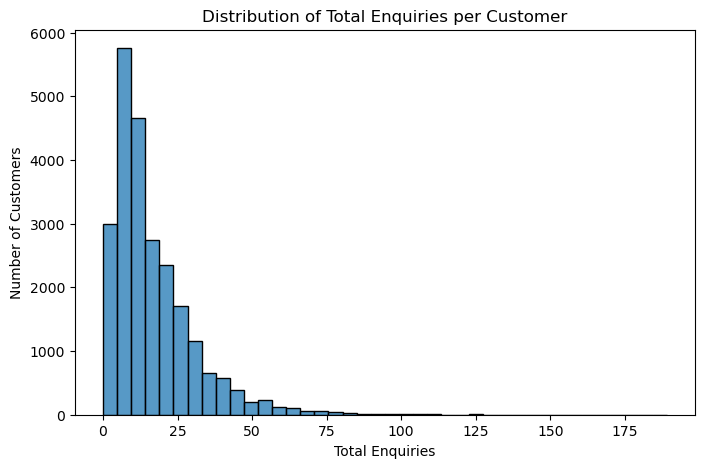

In [1208]:
plt.figure(figsize=(8, 5))

sns.histplot(
    enquiry_features[
        "total_enquiries"
    ],
    bins=40
)

plt.title(
    "Distribution of Total Enquiries per Customer"
)

plt.xlabel(
    "Total Enquiries"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

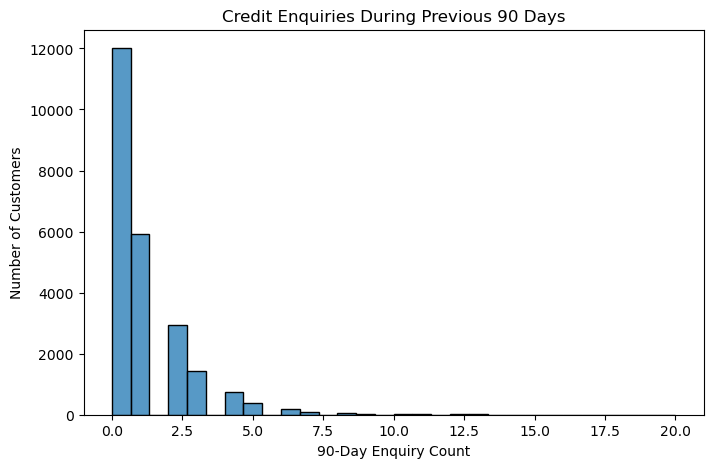

In [1209]:
plt.figure(figsize=(8, 5))

sns.histplot(
    enquiry_features[
        "count_enquiry_recency_90"
    ],
    bins=30
)

plt.title(
    "Credit Enquiries During Previous 90 Days"
)

plt.xlabel(
    "90-Day Enquiry Count"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

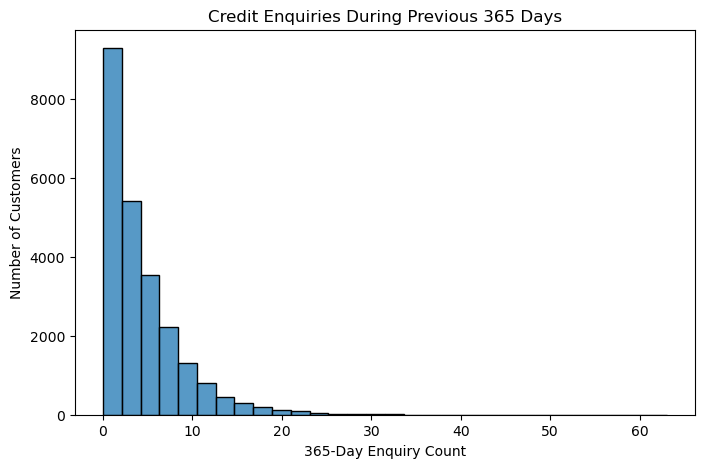

In [1210]:
plt.figure(figsize=(8, 5))

sns.histplot(
    enquiry_features[
        "count_enquiry_recency_365"
    ],
    bins=30
)

plt.title(
    "Credit Enquiries During Previous 365 Days"
)

plt.xlabel(
    "365-Day Enquiry Count"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [1211]:
enquiry_feature_plot = (
    enquiry_features
    .sample(
        n=min(
            50000,
            len(enquiry_features)
        ),
        random_state=42
    )
)

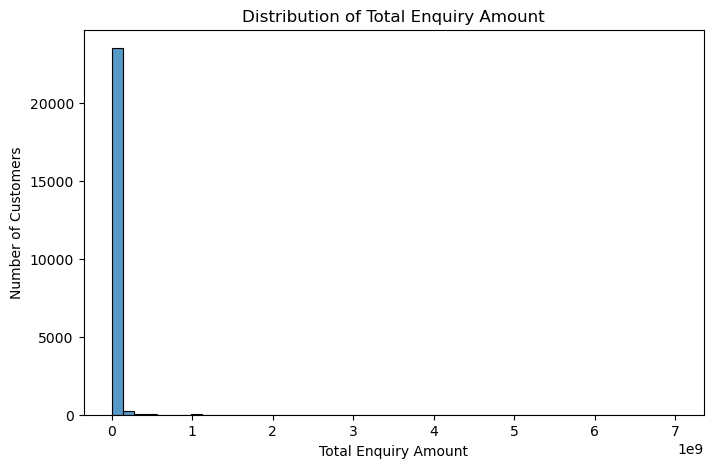

In [1212]:
plt.figure(figsize=(8, 5))

sns.histplot(
    enquiry_feature_plot[
        "total_enquiry_amount"
    ].dropna(),
    bins=50
)

plt.title(
    "Distribution of Total Enquiry Amount"
)

plt.xlabel(
    "Total Enquiry Amount"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [1213]:
enquiry_features_model = (
    enquiry_features
    .drop(
        columns=[
            "first_enquiry_date",
            "latest_enquiry_date"
        ],
        errors="ignore"
    )
    .copy()
)

In [1214]:
print(
    "Full enquiry feature matrix:",
    enquiry_features.shape
)

print(
    "Model-ready enquiry feature matrix:",
    enquiry_features_model.shape
)

Full enquiry feature matrix: (23896, 33)
Model-ready enquiry feature matrix: (23896, 31)


In [1215]:
print("=" * 70)
print("CUSTOMER-LEVEL VALIDATION")
print("=" * 70)

print(
    "Original enquiry records:",
    len(enquiry_clean)
)

print(
    "Original unique customers:",
    enquiry_clean[
        "customer_no"
    ].nunique()
)

print(
    "\nFinal feature rows:",
    len(enquiry_features_model)
)

print(
    "Final unique customers:",
    enquiry_features_model[
        "customer_no"
    ].nunique()
)

print(
    "Duplicate customer IDs:",
    enquiry_features_model[
        "customer_no"
    ]
    .duplicated()
    .sum()
)

CUSTOMER-LEVEL VALIDATION
Original enquiry records: 399361
Original unique customers: 23896

Final feature rows: 23896
Final unique customers: 23896
Duplicate customer IDs: 0


In [1216]:
enquiry_feature_summary = pd.DataFrame({

    "Metric": [
        "Customers",
        "Engineered Features",
        "Duplicate Customers",
        "Missing Values",
        "Infinite Values"
    ],

    "Value": [

        len(
            enquiry_features_model
        ),

        enquiry_features_model.shape[1]
        - 1,

        enquiry_features_model[
            "customer_no"
        ]
        .duplicated()
        .sum(),

        enquiry_features_model
        .isnull()
        .sum()
        .sum(),

        np.isinf(
            enquiry_features_model
            .select_dtypes(
                include=np.number
            )
        )
        .sum()
        .sum()
    ]
})

enquiry_feature_summary

,Metric,Value
0,Customers,23896
1,Engineered Features,30
2,Duplicate Customers,0
3,Missing Values,2543
4,Infinite Values,0


In [1217]:
enquiry_feature_path = os.path.join(
    data_folder,
    "enquiry_features_final.csv"
)

enquiry_features_model.to_csv(
    enquiry_feature_path,
    index=False
)

print(
    "Enquiry Feature Matrix saved successfully."
)

print(
    "Location:",
    enquiry_feature_path
)

Enquiry Feature Matrix saved successfully.
Location: Bank_GoodCredit_Data\enquiry_features_final.csv


In [1218]:
print(
    "File exists:",
    os.path.exists(
        enquiry_feature_path
    )
)

File exists: True


## Enquiry Feature Engineering — Summary

The Cust_Enquiry dataset contains multiple historical credit-enquiry
records for individual customers.

Since the machine-learning dataset must contain one observation per
customer, the enquiry records were transformed into customer-level
behavioural features.

### Enquiry Frequency

The total number of enquiries made by each customer was calculated.
Frequent credit enquiries may provide information regarding recent
credit-seeking behaviour.

### Recent Enquiry Activity

Enquiry dates were compared with the customer's application/reference
date to calculate enquiry recency.

Recent enquiry counts were created for the previous:

- 30 days
- 90 days
- 180 days
- 365 days

The 90-day and 365-day enquiry-count variables correspond to features
specifically suggested in the project requirements.

### Enquiry Amount

Total, mean, median, minimum, maximum and standard deviation of enquiry
amounts were calculated.

Recent enquiry amounts were also calculated for different recency
windows.

### Enquiry Purpose Diversity

The number of unique enquiry-purpose categories was calculated for
each customer.

This represents the diversity of the customer's historical credit
enquiry activity without assigning unsupported interpretations to the
encoded purpose values.

### Enquiry Recency

The number of days since the customer's latest valid historical
enquiry was calculated.

### Enquiry Frequency

The time between consecutive enquiries was calculated to represent
the frequency of historical credit-seeking activity.

### Customer-Level Aggregation

All enquiry records were aggregated using customer_no.

The resulting Enquiry Feature Matrix contains one row per customer
and can therefore be merged with the Account Feature Matrix and
Demographics dataset.

In [1220]:
print("=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print(
    "Original Enquiry Records:",
    len(enquiry_clean)
)

print(
    "Original Unique Customers:",
    enquiry_clean[
        "customer_no"
    ].nunique()
)

print(
    "\nFinal Feature Rows:",
    len(enquiry_features_model)
)

print(
    "Final Unique Customers:",
    enquiry_features_model[
        "customer_no"
    ].nunique()
)

print(
    "Number of Engineered Features:",
    enquiry_features_model.shape[1]
    - 1
)

print(
    "Duplicate Customers:",
    enquiry_features_model[
        "customer_no"
    ]
    .duplicated()
    .sum()
)

print(
    "Infinite Values:",
    np.isinf(
        enquiry_features_model
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)

print(
    "\n90-Day Enquiry Feature Exists:",
    "count_enquiry_recency_90"
    in enquiry_features_model.columns
)

print(
    "365-Day Enquiry Feature Exists:",
    "count_enquiry_recency_365"
    in enquiry_features_model.columns
)


FINAL VALIDATION
Original Enquiry Records: 399361
Original Unique Customers: 23896

Final Feature Rows: 23896
Final Unique Customers: 23896
Number of Engineered Features: 30
Duplicate Customers: 0
Infinite Values: 0

90-Day Enquiry Feature Exists: True
365-Day Enquiry Feature Exists: True


## Dataset Integration and Final Master Feature Matrix

## Objective

The objective of this stage is to combine the three sources of
customer information into a single customer-level dataset.

The following datasets are integrated:

1. Demographics data
2. Account-level engineered features
3. Enquiry-level engineered features

The datasets are merged using `customer_no`.

The Demographics dataset is used as the base dataset because it
contains the target variable `bad_label`.

Customers without Account or Enquiry history are retained rather
than removed.

The resulting dataset will contain one row per customer and will
be used for machine-learning preprocessing and model development.

In [1222]:
print("DEMOGRAPHICS")
print(demographics_clean.shape)

print("\nACCOUNT FEATURES")
print(account_features.shape)

print("\nENQUIRY FEATURES")
print(enquiry_features_model.shape)

DEMOGRAPHICS
(23896, 83)

ACCOUNT FEATURES
(23896, 56)

ENQUIRY FEATURES
(23896, 31)


In [1223]:
print("=" * 70)
print("CUSTOMER COUNTS BEFORE MERGING")
print("=" * 70)

print(
    "Demographics customers:",
    demographics_clean[
        "customer_no"
    ].nunique()
)

print(
    "Account customers:",
    account_features[
        "customer_no"
    ].nunique()
)

print(
    "Enquiry customers:",
    enquiry_features_model[
        "customer_no"
    ].nunique()
)

CUSTOMER COUNTS BEFORE MERGING
Demographics customers: 23896
Account customers: 23896
Enquiry customers: 23896


In [1224]:
print("=" * 70)
print("DUPLICATE CUSTOMER CHECK")
print("=" * 70)

print(
    "Demographics duplicate customers:",
    demographics_clean[
        "customer_no"
    ].duplicated().sum()
)

print(
    "Account feature duplicate customers:",
    account_features[
        "customer_no"
    ].duplicated().sum()
)

print(
    "Enquiry feature duplicate customers:",
    enquiry_features_model[
        "customer_no"
    ].duplicated().sum()
)

DUPLICATE CUSTOMER CHECK
Demographics duplicate customers: 0
Account feature duplicate customers: 0
Enquiry feature duplicate customers: 0


In [1225]:
demographics_clean[
    "customer_no"
] = (
    demographics_clean[
        "customer_no"
    ]
    .astype(str)
    .str.strip()
)

account_features[
    "customer_no"
] = (
    account_features[
        "customer_no"
    ]
    .astype(str)
    .str.strip()
)

enquiry_features_model[
    "customer_no"
] = (
    enquiry_features_model[
        "customer_no"
    ]
    .astype(str)
    .str.strip()
)

print("Customer ID datatypes standardized.")

Customer ID datatypes standardized.


In [1226]:
print(
    demographics_clean[
        "customer_no"
    ].dtype
)

print(
    account_features[
        "customer_no"
    ].dtype
)

print(
    enquiry_features_model[
        "customer_no"
    ].dtype
)

object
object
object


In [1227]:
demo_customers = set(
    demographics_clean[
        "customer_no"
    ]
)

account_customers = set(
    account_features[
        "customer_no"
    ]
)

enquiry_customers = set(
    enquiry_features_model[
        "customer_no"
    ]
)

In [1228]:
print("=" * 70)
print("CUSTOMER OVERLAP")
print("=" * 70)

print(
    "Demographics customers:",
    len(demo_customers)
)

print(
    "Demo customers with Account history:",
    len(
        demo_customers
        & account_customers
    )
)

print(
    "Demo customers with Enquiry history:",
    len(
        demo_customers
        & enquiry_customers
    )
)

print(
    "Demo customers with BOTH histories:",
    len(
        demo_customers
        & account_customers
        & enquiry_customers
    )
)

CUSTOMER OVERLAP
Demographics customers: 23896
Demo customers with Account history: 23896
Demo customers with Enquiry history: 23896
Demo customers with BOTH histories: 23896


In [1229]:
demo_without_account = (
    demo_customers
    - account_customers
)

print(
    "Customers without Account history:",
    len(demo_without_account)
)

Customers without Account history: 0


In [1230]:
demo_without_enquiry = (
    demo_customers
    - enquiry_customers
)

print(
    "Customers without Enquiry history:",
    len(demo_without_enquiry)
)

Customers without Enquiry history: 0


In [1231]:
account_features[
    "has_account_history"
] = 1

In [1232]:
enquiry_features_model[
    "has_enquiry_history"
] = 1

In [1233]:
account_cols = set(
    account_features.columns
)

enquiry_cols = set(
    enquiry_features_model.columns
)

overlapping_features = (
    account_cols
    & enquiry_cols
)

overlapping_features.discard(
    "customer_no"
)

print(
    "Overlapping Account/Enquiry features:",
    overlapping_features
)

Overlapping Account/Enquiry features: set()


In [1234]:
original_demo_rows = len(
    demographics_clean
)

print(
    "Original demographic rows:",
    original_demo_rows
)

Original demographic rows: 23896


In [1235]:
master_df = (
    demographics_clean
    .merge(
        account_features,
        on="customer_no",
        how="left",
        validate="one_to_one"
    )
)

In [1236]:
print(
    "Shape after Account merge:",
    master_df.shape
)

print(
    "Rows before merge:",
    original_demo_rows
)

print(
    "Rows after merge:",
    len(master_df)
)

Shape after Account merge: (23896, 139)
Rows before merge: 23896
Rows after merge: 23896


In [1237]:
master_df = (
    master_df
    .merge(
        enquiry_features_model,
        on="customer_no",
        how="left",
        validate="one_to_one"
    )
)

In [1238]:
print("=" * 70)
print("FINAL MERGE VALIDATION")
print("=" * 70)

print(
    "Original Demographics rows:",
    original_demo_rows
)

print(
    "Final Master rows:",
    len(master_df)
)

print(
    "Final Master columns:",
    master_df.shape[1]
)

print(
    "Unique customers:",
    master_df[
        "customer_no"
    ].nunique()
)

print(
    "Duplicate customers:",
    master_df[
        "customer_no"
    ].duplicated().sum()
)

FINAL MERGE VALIDATION
Original Demographics rows: 23896
Final Master rows: 23896
Final Master columns: 170
Unique customers: 23896
Duplicate customers: 0


In [1239]:
print(
    master_df[
        "has_account_history"
    ].value_counts(
        dropna=False
    )
)

print()

print(
    master_df[
        "has_enquiry_history"
    ].value_counts(
        dropna=False
    )
)

has_account_history
1    23896
Name: count, dtype: int64

has_enquiry_history
1    23896
Name: count, dtype: int64


In [1240]:
master_df[
    "has_account_history"
] = (
    master_df[
        "has_account_history"
    ]
    .fillna(0)
    .astype(int)
)

master_df[
    "has_enquiry_history"
] = (
    master_df[
        "has_enquiry_history"
    ]
    .fillna(0)
    .astype(int)
)

In [1241]:
print(
    master_df[
        "has_account_history"
    ].value_counts()
)

print()

print(
    master_df[
        "has_enquiry_history"
    ].value_counts()
)

has_account_history
1    23896
Name: count, dtype: int64

has_enquiry_history
1    23896
Name: count, dtype: int64


In [1242]:
enquiry_zero_cols = [
    "total_enquiries",
    "total_enquiry_records",
    "unique_enquiry_purposes",
    "total_enquiry_amount",
    "count_enquiry_recency_30",
    "count_enquiry_recency_90",
    "count_enquiry_recency_180",
    "count_enquiry_recency_365",
    "total_enquiry_amount_30d",
    "total_enquiry_amount_90d",
    "total_enquiry_amount_180d",
    "total_enquiry_amount_365d",
    "recent_90d_enquiry_ratio",
    "recent_365d_enquiry_ratio",
    "recent_365d_amount_ratio"
]

In [1243]:
for col in enquiry_zero_cols:

    if col in master_df.columns:

        no_history_mask = (
            master_df[
                "has_enquiry_history"
            ] == 0
        )

        master_df.loc[
            no_history_mask,
            col
        ] = 0

In [1244]:
account_zero_cols = [
    "total_accounts",
    "unique_account_types",
    "unique_ownership_types",
    "open_accounts",
    "closed_accounts",
    "accounts_with_past_due",
    "ever_past_due",
    "open_account_ratio",
    "closed_account_ratio",
    "past_due_account_ratio"
]

In [1245]:
for col in account_zero_cols:

    if col in master_df.columns:

        no_history_mask = (
            master_df[
                "has_account_history"
            ] == 0
        )

        master_df.loc[
            no_history_mask,
            col
        ] = 0

In [1246]:
master_df.fillna(0)

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,bad_label,total_accounts,unique_account_types,unique_ownership_types,open_accounts,closed_accounts,mean_account_age_months,max_account_age_months,min_account_age_months,total_current_balance,mean_current_balance,max_current_balance,total_high_credit,mean_high_credit,max_high_credit,total_credit_limit,mean_credit_limit,max_credit_limit,total_cash_limit,mean_cash_limit,max_cash_limit,total_past_due,mean_past_due,max_past_due,accounts_with_past_due,ever_past_due,total_actual_payment,mean_actual_payment,max_actual_payment,mean_interest_rate,max_interest_rate,min_months_since_last_payment,mean_months_since_last_payment,max_months_since_last_payment,mean_open_to_lastpayment_months,max_open_to_lastpayment_months,mean_payment_history_period,max_payment_history_period,mean_balance_creditlimit_ratio,max_balance_creditlimit_ratio,mean_balance_highcredit_ratio,max_balance_highcredit_ratio,mean_pastdue_balance_ratio,max_pastdue_balance_ratio,mean_pastdue_creditlimit_ratio,max_pastdue_creditlimit_ratio,mean_payment_balance_ratio,mean_payment_highcredit_ratio,open_account_ratio,closed_account_ratio,past_due_account_ratio,total_balance_creditlimit_ratio,total_balance_highcredit_ratio,total_pastdue_balance_ratio,total_pastdue_creditlimit_ratio,total_payment_balance_ratio,has_account_history,total_enquiries,total_enquiry_records,unique_enquiry_purposes,total_enquiry_amount,mean_enquiry_amount,median_enquiry_amount,max_enquiry_amount,min_enquiry_amount,std_enquiry_amount,count_enquiry_recency_30,count_enquiry_recency_90,count_enquiry_recency_180,count_enquiry_recency_365,total_enquiry_amount_30d,total_enquiry_amount_90d,total_enquiry_amount_180d,total_enquiry_amount_365d,days_since_latest_enquiry,mean_enquiry_recency_days,max_enquiry_recency_days,mean_days_between_enquiries,min_days_between_enquiries,max_days_between_enquiries,enquiry_history_span_days,recent_90d_enquiry_ratio,recent_365d_enquiry_ratio,recent_365d_amount_ratio,avg_amount_per_enquiry,days_since_latest_valid_enquiry,days_since_oldest_valid_enquiry,has_enquiry_history
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.000,2.000,Card Setup,14.000,"500,000.000",0,0,0,Y,IS1,0,0.000,159,4284,4284,0,1.000,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1.000,2.000,0,Mumbai / Navi Mumbai / Thane,"400,610.000","1,965.000",0.000,Self,Y,2.000,"90,000.000",0,0,0,0.000,0.000,0.000,0.000,Mumbai,"400,059.000",@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,0.000,Y,State Bank of India,0.000,01-Jun-13,17-Jun-16,1.000,21.000,0,Y,Y,N,0,Y,1965-0,21.000,15.000,"400,610.000",0.000,2.000,"90,000.000",Nov-00,21.000,R,0,0.000,0000-00-00,0.000,98332XXXXX,1.000,N,0,18,4,2,6,12,153.337,233.968,21.682,4714857,"261,936.500",2528846,"7,900,063.000","526,670.867","2,528,846.000","670,000.000","335,000.000","420,000.000","168,000.000","168,000.000","168,000.000","2,538,209.000","1,269,104.500","2,528,846.000",2,1,"71,086.000","35,543.000","45,986.000",17.711,34.585,9.461,83.893,163.173,49.146,117.904,12.834,35.053,0.163,0.236,0.176,1.000,1.000,1.000,0.000,0.000,0.825,0.179,0.333,0.667,0.111,7.037,0.597,0.538,3.788,0.015,1,18,1

In [1247]:
print(
    "bad_label exists:",
    "bad_label"
    in master_df.columns
)

bad_label exists: True


In [1248]:
print(
    "Missing target values:",
    master_df[
        "bad_label"
    ].isnull().sum()
)

Missing target values: 0


In [1249]:
print(
    master_df[
        "bad_label"
    ].value_counts()
)

print()

print(
    master_df[
        "bad_label"
    ].value_counts(
        normalize=True
    ) * 100
)

bad_label
0    22892
1     1004
Name: count, dtype: int64

bad_label
0   95.798
1    4.202
Name: proportion, dtype: float64


In [1250]:
duplicate_columns = (
    master_df.columns[
        master_df.columns.duplicated()
    ]
    .tolist()
)

print(
    "Duplicate column names:",
    duplicate_columns
)

Duplicate column names: []


In [1251]:
suffix_columns = [
    col
    for col in master_df.columns
    if col.endswith("_x")
    or col.endswith("_y")
]

print(
    "Unexpected merge suffix columns:",
    suffix_columns
)

Unexpected merge suffix columns: []


In [1252]:
master_missing = pd.DataFrame({

    "Missing_Count":
        master_df
        .isnull()
        .sum(),

    "Missing_Percentage":
        master_df
        .isnull()
        .mean()
        * 100
})

master_missing = (
    master_missing
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(
    master_missing.head(30)
)

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
max_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_balance_ratio,23133,96.807
max_pastdue_balance_ratio,23133,96.807
mean_past_due,23110,96.711


In [1253]:
high_missing_features = (
    master_missing[
        master_missing[
            "Missing_Percentage"
        ] > 90
    ]
)

display(
    high_missing_features
)

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
max_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_balance_ratio,23133,96.807
max_pastdue_balance_ratio,23133,96.807
mean_past_due,23110,96.711


In [1254]:
master_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [1255]:
numeric_master = (
    master_df
    .select_dtypes(
        include=np.number
    )
)

print(
    "Infinite values:",
    np.isinf(
        numeric_master
    ).sum().sum()
)

Infinite values: 0


In [1256]:
print(
    master_df
    .dtypes
    .value_counts()
)

float64    101
object      50
int32       11
int64        8
Name: count, dtype: int64


In [1257]:
object_columns = (
    master_df
    .select_dtypes(
        include="object"
    )
    .columns
    .tolist()
)

print(
    "Object columns:"
)

print(
    object_columns
)

Object columns:
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_5', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_50', 'feature_51', 'feature_53', 'feature_54', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_70', 'feature_72', 'feature_73', 'feature_75', 'feature_77', 'feature_79']


In [1258]:
datetime_columns = (
    master_df
    .select_dtypes(
        include=[
            "datetime",
            "datetimetz"
        ]
    )
    .columns
    .tolist()
)

print(
    "Datetime columns:",
    datetime_columns
)

Datetime columns: []


In [1259]:
constant_features = [
    col

    for col in master_df.columns

    if (
        col not in [
            "customer_no",
            "bad_label"
        ]

        and master_df[col]
        .nunique(
            dropna=False
        ) <= 1
    )
]

print(
    "Number of constant features:",
    len(constant_features)
)

print(
    "Constant features:",
    constant_features
)

Number of constant features: 2
Constant features: ['has_account_history', 'has_enquiry_history']


In [1260]:
print(
    "Duplicate customer IDs:",
    master_df[
        "customer_no"
    ]
    .duplicated()
    .sum()
)

Duplicate customer IDs: 0


In [1261]:
history_summary = pd.crosstab(

    master_df[
        "has_account_history"
    ],

    master_df[
        "has_enquiry_history"
    ],

    margins=True
)

history_summary

has_enquiry_history,1,All
has_account_history,,
1,23896,23896
All,23896,23896


In [1262]:
account_history_target = pd.crosstab(

    master_df[
        "has_account_history"
    ],

    master_df[
        "bad_label"
    ],

    normalize="index"
) * 100

account_history_target

bad_label,0,1
has_account_history,,
1,95.798,4.202


In [1263]:
enquiry_history_target = pd.crosstab(

    master_df[
        "has_enquiry_history"
    ],

    master_df[
        "bad_label"
    ],

    normalize="index"
) * 100

enquiry_history_target

bad_label,0,1
has_enquiry_history,,
1,95.798,4.202


In [1264]:
master_summary = pd.DataFrame({

    "Metric": [
        "Customers",
        "Total Columns",
        "Predictor Columns",
        "Duplicate Customers",
        "Missing Target Values",
        "Total Missing Values",
        "Infinite Values",
        "Account History Available",
        "Enquiry History Available"
    ],

    "Value": [

        len(master_df),

        master_df.shape[1],

        master_df.shape[1] - 2,

        master_df[
            "customer_no"
        ]
        .duplicated()
        .sum(),

        master_df[
            "bad_label"
        ]
        .isnull()
        .sum(),

        master_df
        .isnull()
        .sum()
        .sum(),

        np.isinf(
            master_df
            .select_dtypes(
                include=np.number
            )
        )
        .sum()
        .sum(),

        master_df[
            "has_account_history"
        ].sum(),

        master_df[
            "has_enquiry_history"
        ].sum()
    ]
})

master_summary

,Metric,Value
0,Customers,23896
1,Total Columns,170
2,Predictor Columns,168
3,Duplicate Customers,0
4,Missing Target Values,0
5,Total Missing Values,553296
6,Infinite Values,0
7,Account History Available,23896
8,Enquiry History Available,23896


In [1265]:
model_df = master_df.copy()

In [1266]:
model_df.drop(
    columns=[
        "customer_no"
    ],
    inplace=True,
    errors="ignore"
)

In [1267]:
model_constant_features = [
    col
    for col in constant_features
    if col in model_df.columns
]

model_df.drop(
    columns=model_constant_features,
    inplace=True,
    errors="ignore"
)

print(
    "Constant features removed:",
    len(model_constant_features)
)

Constant features removed: 2


In [1268]:
model_datetime_columns = (
    model_df
    .select_dtypes(
        include=[
            "datetime",
            "datetimetz"
        ]
    )
    .columns
    .tolist()
)

print(
    "Datetime columns removed from model data:",
    model_datetime_columns
)

Datetime columns removed from model data: []


In [1269]:
model_df.drop(
    columns=model_datetime_columns,
    inplace=True,
    errors="ignore"
)

In [1270]:
leakage_keywords = [
    "bad_label",
    "target",
    "default",
    "outcome",
    "response",
    "prediction",
    "predicted",
    "probability"
]

suspicious_columns = []

for col in model_df.columns:

    col_lower = col.lower()

    if any(
        keyword in col_lower
        for keyword in leakage_keywords
    ):

        suspicious_columns.append(
            col
        )

print(
    "Potential leakage-related columns:",
    suspicious_columns
)

Potential leakage-related columns: ['bad_label']


In [1271]:
X = (
    model_df
    .drop(
        columns=[
            "bad_label"
        ]
    )
    .copy()
)

y = (
    model_df[
        "bad_label"
    ]
    .copy()
)

In [1272]:
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (23896, 166)
y shape: (23896,)


In [1273]:
print(
    y.value_counts()
)

print()

print(
    y.value_counts(
        normalize=True
    ) * 100
)

bad_label
0    22892
1     1004
Name: count, dtype: int64

bad_label
0   95.798
1    4.202
Name: proportion, dtype: float64


In [1274]:
numeric_features = (
    X
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

Numerical features: 117
Categorical features: 49


In [1275]:
print(
    "Categorical columns:"
)

print(
    categorical_features
)

Categorical columns:
['dt_opened', 'entry_time', 'feature_1', 'feature_2', 'feature_5', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_50', 'feature_51', 'feature_53', 'feature_54', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_70', 'feature_72', 'feature_73', 'feature_75', 'feature_77', 'feature_79']


In [1276]:
X_missing = pd.DataFrame({

    "Missing_Count":
        X.isnull().sum(),

    "Missing_Percentage":
        X.isnull().mean() * 100
})

X_missing = (
    X_missing[
        X_missing[
            "Missing_Count"
        ] > 0
    ]
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(
    X_missing.head(30)
)

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
max_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_creditlimit_ratio,23674,99.071
max_pastdue_balance_ratio,23133,96.807
mean_pastdue_balance_ratio,23133,96.807
mean_past_due,23110,96.711


In [1277]:
X_numeric = (
    X
    .select_dtypes(
        include=np.number
    )
)

print(
    "Infinite values in X:",
    np.isinf(
        X_numeric
    ).sum().sum()
)

Infinite values in X: 0


In [1278]:
master_path = os.path.join(
    data_folder,
    "master_customer_data.csv"
)

master_df.to_csv(
    master_path,
    index=False
)

print(
    "Master customer dataset saved."
)

Master customer dataset saved.


In [1279]:
model_path = os.path.join(
    data_folder,
    "model_data_before_preprocessing.csv"
)

model_df.to_csv(
    model_path,
    index=False
)

print(
    "Model dataset saved."
)

Model dataset saved.


In [1280]:
print(
    "Master file exists:",
    os.path.exists(
        master_path
    )
)

print(
    "Model file exists:",
    os.path.exists(
        model_path
    )
)

Master file exists: True
Model file exists: True


In [1281]:
print("=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print(
    "Demographics Customers:",
    demographics_clean[
        "customer_no"
    ].nunique()
)

print(
    "Final Master Rows:",
    len(master_df)
)

print(
    "Final Unique Customers:",
    master_df[
        "customer_no"
    ].nunique()
)

print(
    "Duplicate Customers:",
    master_df[
        "customer_no"
    ].duplicated().sum()
)

print(
    "\nTotal Master Columns:",
    master_df.shape[1]
)

print(
    "Model Features:",
    X.shape[1]
)

print(
    "Target Records:",
    len(y)
)

print(
    "\nMissing Target:",
    y.isnull().sum()
)

print(
    "Target Classes:",
    sorted(
        y.unique()
    )
)

print(
    "\nNumerical Features:",
    len(numeric_features)
)

print(
    "Categorical Features:",
    len(categorical_features)
)

print(
    "Infinite Values in Predictors:",
    np.isinf(
        X.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print("=" * 70)

if (
    len(master_df)
    == demographics_clean[
        "customer_no"
    ].nunique()
    and
    master_df[
        "customer_no"
    ].duplicated().sum()
    == 0
    and
    y.isnull().sum()
    == 0
):

    print(
        "VALIDATION PASSED"
    )

else:

    print(
        "CHECK THE VALIDATION RESULTS ABOVE"
    )

print("=" * 70)

FINAL VALIDATION
Demographics Customers: 23896
Final Master Rows: 23896
Final Unique Customers: 23896
Duplicate Customers: 0

Total Master Columns: 170
Model Features: 166
Target Records: 23896

Missing Target: 0
Target Classes: [0, 1]

Numerical Features: 117
Categorical Features: 49
Infinite Values in Predictors: 0
VALIDATION PASSED


## Dataset Integration — Summary

The Account and Enquiry datasets originally contained multiple
historical records for individual customers.

During feature engineering, these datasets were aggregated to produce
one Account feature row and one Enquiry feature row for each customer.

The Demographics dataset was used as the base population because it
contains the customer-level target variable, `Bad_label`.

### Merge Strategy

The datasets were integrated using `customer_no`.

Left joins were used to preserve all customers available in the
Demographics dataset.

This was important because customers without historical Account or
Enquiry information should not automatically be excluded from model
development.

### Missing Historical Information

Two additional indicators were created:

- `has_account_history`
- `has_enquiry_history`

These variables distinguish customers with historical records from
customers without historical records.

Count-based Account and Enquiry variables were assigned zero where
the absence of historical records logically implies zero activity.

Continuous variables such as interest rates, balance statistics and
recency measures were not automatically replaced with zero because
zero could represent a genuine numerical value rather than missing
information.

### Customer-Level Feature Matrix

After integration, the final Master Feature Matrix contains one row
per customer.

It combines:

- Demographic/application features
- Account behaviour
- Balance and credit information
- Past-due information
- Payment behaviour
- Credit-utilization measures
- Enquiry frequency
- Enquiry recency
- Enquiry amounts
- Credit-seeking behaviour
- Target variable (`Bad_label`)

The customer identifier was retained in the master dataset for
traceability but excluded from the machine-learning predictor matrix.

The resulting model dataset is ready for feature screening,
train-test splitting and preprocessing.

## Feature Screening and Final Preparation

## Objective

The merged customer-level dataset contains demographic, account and
enquiry features.

Before model training, the predictor variables must be examined for
data-quality issues, redundancy and potential target leakage.

The following checks are performed:

- Target validation
- Missing-value analysis
- Constant feature detection
- Near-constant feature detection
- Duplicate feature detection
- Identifier-like feature detection
- Categorical cardinality analysis
- Numerical correlation analysis
- Potential target-leakage screening
- Infinite-value validation
- Final numerical/categorical feature identification

The objective is to create a clean predictor matrix while preserving
the target variable for subsequent train-test splitting and model
preprocessing.

In [1284]:
X_screen = X.copy()
y_screen = y.copy()

print("Feature screening dataset created.")

print("X shape:", X_screen.shape)
print("y shape:", y_screen.shape)

Feature screening dataset created.
X shape: (23896, 166)
y shape: (23896,)


In [1285]:
print(
    "X rows:",
    len(X_screen)
)

print(
    "y rows:",
    len(y_screen)
)

print(
    "Same number of rows:",
    len(X_screen) == len(y_screen)
)

X rows: 23896
y rows: 23896
Same number of rows: True


In [1286]:
print(
    "Missing target values:",
    y_screen.isnull().sum()
)

Missing target values: 0


In [1287]:
print("Target distribution:")

print(
    y_screen.value_counts(
        dropna=False
    )
)

Target distribution:
bad_label
0    22892
1     1004
Name: count, dtype: int64


In [1288]:
print(
    y_screen.value_counts(
        normalize=True
    ) * 100
)

bad_label
0   95.798
1    4.202
Name: proportion, dtype: float64


In [1289]:
missing_summary = pd.DataFrame({

    "Missing_Count":
        X_screen.isnull().sum(),

    "Missing_Percentage":
        X_screen.isnull().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(
    missing_summary.head(30)
)

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
mean_pastdue_creditlimit_ratio,23674,99.071
max_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_balance_ratio,23133,96.807
max_pastdue_balance_ratio,23133,96.807
mean_past_due,23110,96.711


In [1290]:
very_high_missing_cols = (
    missing_summary[
        missing_summary[
            "Missing_Percentage"
        ] > 90
    ]
    .index
    .tolist()
)

print(
    "Features with >90% missing values:"
)

print(
    very_high_missing_cols
)

print(
    "\nNumber:",
    len(very_high_missing_cols)
)

Features with >90% missing values:
['feature_61', 'feature_74', 'feature_18', 'feature_10', 'feature_49', 'mean_pastdue_creditlimit_ratio', 'max_pastdue_creditlimit_ratio', 'mean_pastdue_balance_ratio', 'max_pastdue_balance_ratio', 'mean_past_due', 'max_past_due', 'feature_17', 'feature_8', 'feature_9']

Number: 14


In [1291]:
if len(very_high_missing_cols) > 0:

    display(
        missing_summary.loc[
            very_high_missing_cols
        ]
    )

else:

    print(
        "No features have more than 90% missing values."
    )

,Missing_Count,Missing_Percentage
feature_61,23887,99.962
feature_74,23879,99.929
feature_18,23878,99.925
feature_10,23845,99.787
feature_49,23792,99.565
mean_pastdue_creditlimit_ratio,23674,99.071
max_pastdue_creditlimit_ratio,23674,99.071
mean_pastdue_balance_ratio,23133,96.807
max_pastdue_balance_ratio,23133,96.807
mean_past_due,23110,96.711


In [1292]:
all_missing_cols = [
    col
    for col in X_screen.columns
    if X_screen[col].isnull().all()
]

print(
    "Completely empty features:",
    all_missing_cols
)

Completely empty features: []


In [1293]:
X_screen.drop(
    columns=all_missing_cols,
    inplace=True,
    errors="ignore"
)

print(
    "Shape after removing completely empty features:",
    X_screen.shape
)

Shape after removing completely empty features: (23896, 166)


In [1294]:
constant_cols = [
    col

    for col in X_screen.columns

    if X_screen[col]
    .nunique(
        dropna=False
    ) <= 1
]

print(
    "Constant features:"
)

print(
    constant_cols
)

print(
    "\nNumber:",
    len(constant_cols)
)

Constant features:
[]

Number: 0


In [1295]:
X_screen.drop(
    columns=constant_cols,
    inplace=True,
    errors="ignore"
)

print(
    "Shape after constant-feature removal:",
    X_screen.shape
)

Shape after constant-feature removal: (23896, 166)


In [1296]:
near_constant_results = []

for col in X_screen.columns:

    value_counts = (
        X_screen[col]
        .value_counts(
            normalize=True,
            dropna=False
        )
    )

    if len(value_counts) > 0:

        dominant_percentage = (
            value_counts.iloc[0] * 100
        )

        if dominant_percentage >= 99:

            near_constant_results.append(
                {
                    "Feature": col,
                    "Dominant_Percentage":
                        dominant_percentage,
                    "Unique_Values":
                        X_screen[col]
                        .nunique(
                            dropna=False
                        )
                }
            )

In [1297]:
near_constant_df = pd.DataFrame(
    near_constant_results
)

if len(near_constant_df) > 0:

    near_constant_df = (
        near_constant_df
        .sort_values(
            "Dominant_Percentage",
            ascending=False
        )
    )

    display(
        near_constant_df
    )

else:

    print(
        "No near-constant features detected."
    )

,Feature,Dominant_Percentage,Unique_Values
6,feature_61,99.962,9
0,feature_5,99.937,2
1,feature_6,99.937,2
5,feature_54,99.937,2
8,feature_74,99.929,4
3,feature_18,99.925,13
7,feature_62,99.916,3
11,feature_79,99.916,3
2,feature_10,99.787,8
9,feature_75,99.682,63


In [1298]:
duplicate_feature_pairs = []

columns_list = (
    X_screen.columns.tolist()
)

for i in range(
    len(columns_list)
):

    for j in range(
        i + 1,
        len(columns_list)
    ):

        col1 = columns_list[i]
        col2 = columns_list[j]

        if X_screen[col1].equals(
            X_screen[col2]
        ):

            duplicate_feature_pairs.append(
                (col1, col2)
            )

In [1299]:
print(
    "Duplicate feature pairs:"
)

for pair in duplicate_feature_pairs:

    print(pair)

Duplicate feature pairs:
('feature_11', 'feature_59')
('feature_34', 'feature_68')
('feature_35', 'feature_69')
('mean_enquiry_amount', 'avg_amount_per_enquiry')
('days_since_latest_enquiry', 'days_since_latest_valid_enquiry')
('max_enquiry_recency_days', 'days_since_oldest_valid_enquiry')


In [1300]:
duplicate_cols_to_remove = list(
    set(
        pair[1]
        for pair
        in duplicate_feature_pairs
    )
)

print(
    "Duplicate columns to remove:",
    duplicate_cols_to_remove
)

Duplicate columns to remove: ['feature_68', 'days_since_latest_valid_enquiry', 'days_since_oldest_valid_enquiry', 'feature_59', 'avg_amount_per_enquiry', 'feature_69']


In [1301]:
X_screen.drop(
    columns=duplicate_cols_to_remove,
    inplace=True,
    errors="ignore"
)

In [1302]:
identifier_candidates = []

n_rows = len(
    X_screen
)

for col in X_screen.columns:

    unique_ratio = (
        X_screen[col]
        .nunique(
            dropna=True
        )
        / n_rows
    )

    if unique_ratio > 0.95:

        identifier_candidates.append(
            {
                "Feature": col,
                "Unique_Ratio":
                    unique_ratio
            }
        )

In [1303]:
identifier_df = pd.DataFrame(
    identifier_candidates
)

if len(identifier_df) > 0:

    display(
        identifier_df
    )

else:

    print(
        "No obvious identifier-like features found."
    )

,Feature,Unique_Ratio
0,total_current_balance,0.959
1,mean_current_balance,0.974
2,total_high_credit,0.986
3,mean_high_credit,0.987
4,mean_balance_highcredit_ratio,0.978
5,total_balance_highcredit_ratio,0.986


In [1304]:
numeric_cols_screen = (
    X_screen
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

print(
    "Number of numerical features:",
    len(numeric_cols_screen)
)

Number of numerical features: 112


In [1305]:
categorical_cols_screen = (
    X_screen
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    "Number of categorical features:",
    len(categorical_cols_screen)
)

print(
    "\nCategorical features:"
)

print(
    categorical_cols_screen
)

Number of categorical features: 48

Categorical features:
['dt_opened', 'entry_time', 'feature_1', 'feature_2', 'feature_5', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_50', 'feature_51', 'feature_53', 'feature_54', 'feature_57', 'feature_58', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_70', 'feature_72', 'feature_73', 'feature_75', 'feature_77', 'feature_79']


In [1306]:
categorical_cardinality = []

for col in categorical_cols_screen:

    categorical_cardinality.append(
        {
            "Feature": col,

            "Unique_Values":
                X_screen[col]
                .nunique(
                    dropna=True
                ),

            "Missing_Percentage":
                X_screen[col]
                .isnull()
                .mean()
                * 100
        }
    )

categorical_cardinality_df = pd.DataFrame(
    categorical_cardinality
)

In [1307]:
if len(
    categorical_cardinality_df
) > 0:

    categorical_cardinality_df = (
        categorical_cardinality_df
        .sort_values(
            "Unique_Values",
            ascending=False
        )
    )

    display(
        categorical_cardinality_df
    )

else:

    print(
        "No categorical features."
    )

,Feature,Unique_Values,Missing_Percentage
30,feature_47,11250,0.000
15,feature_20,10610,0.000
16,feature_21,8462,0.063
26,feature_38,5663,23.778
28,feature_45,4472,57.386
17,feature_22,3251,0.000
46,feature_77,3124,0.000
19,feature_24,721,2.678
12,feature_16,522,0.113
41,feature_63,491,0.063


In [1308]:
high_cardinality_cols = [
    col

    for col in categorical_cols_screen

    if X_screen[col]
    .nunique(
        dropna=True
    ) > 50
]

print(
    "High-cardinality categorical features:"
)

print(
    high_cardinality_cols
)

High-cardinality categorical features:
['dt_opened', 'entry_time', 'feature_2', 'feature_15', 'feature_16', 'feature_17', 'feature_20', 'feature_21', 'feature_22', 'feature_24', 'feature_28', 'feature_38', 'feature_43', 'feature_45', 'feature_47', 'feature_48', 'feature_53', 'feature_63', 'feature_70', 'feature_75', 'feature_77']


In [1309]:
for col in high_cardinality_cols:

    print(
        "\n",
        "=" * 60
    )

    print(
        "FEATURE:",
        col
    )

    print(
        "Unique values:",
        X_screen[col]
        .nunique(
            dropna=True
        )
    )

    print(
        X_screen[col]
        .value_counts(
            dropna=False
        )
        .head(10)
    )


FEATURE: dt_opened
Unique values: 197
dt_opened
16-Nov-15    699
21-Dec-15    324
13-Oct-15    279
26-Oct-15    271
24-Nov-15    268
18-Aug-15    266
30-Sep-15    257
30-Nov-15    241
31-Dec-15    238
15-Oct-15    229
Name: count, dtype: int64

FEATURE: entry_time
Unique values: 296
entry_time
19-Oct-15    180
11-Sep-15    180
23-Oct-15    174
07-Aug-15    172
09-Oct-15    172
16-Nov-15    168
12-Oct-15    168
17-Oct-15    166
24-Sep-15    165
06-Nov-15    155
Name: count, dtype: int64

FEATURE: feature_2
Unique values: 281
feature_2
NaN          2836
19-Oct-15     182
24-Oct-15     164
17-Oct-15     154
09-Oct-15     153
04-Nov-15     148
24-Sep-15     148
19-Aug-15     146
12-Oct-15     146
06-Nov-15     145
Name: count, dtype: int64

FEATURE: feature_15
Unique values: 364
feature_15
SA03    9331
SA05    1428
SA01    1337
HA03     964
SA40     721
W01      720
SARE     609
SA32     573
MA03     539
SA43     442
Name: count, dtype: int64

FEATURE: feature_16
Unique values: 522
featur

In [1310]:
numeric_temp = (
    X_screen
    .select_dtypes(
        include=np.number
    )
)

infinity_count = (
    np.isinf(
        numeric_temp
    )
    .sum()
    .sum()
)

print(
    "Infinite values:",
    infinity_count
)

Infinite values: 0


In [1311]:
X_screen.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [1312]:
print(
    "Infinite values after cleaning:",
    np.isinf(
        X_screen
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)

Infinite values after cleaning: 0


In [1313]:
numeric_for_corr = (
    X_screen
    .select_dtypes(
        include=np.number
    )
)

correlation_matrix = (
    numeric_for_corr
    .corr()
)

In [1314]:
high_corr_pairs = []

columns = (
    correlation_matrix
    .columns
)

for i in range(
    len(columns)
):

    for j in range(
        i + 1,
        len(columns)
    ):

        corr_value = (
            correlation_matrix
            .iloc[i, j]
        )

        if (
            pd.notna(corr_value)
            and
            abs(corr_value) > 0.95
        ):

            high_corr_pairs.append(
                {
                    "Feature_1":
                        columns[i],

                    "Feature_2":
                        columns[j],

                    "Correlation":
                        corr_value
                }
            )

In [1315]:
high_corr_df = pd.DataFrame(
    high_corr_pairs
)

if len(high_corr_df) > 0:

    high_corr_df[
        "Abs_Correlation"
    ] = (
        high_corr_df[
            "Correlation"
        ].abs()
    )

    high_corr_df = (
        high_corr_df
        .sort_values(
            "Abs_Correlation",
            ascending=False
        )
    )

    display(
        high_corr_df
    )

else:

    print(
        "No numerical feature pairs have |correlation| > 0.95."
    )

,Feature_1,Feature_2,Correlation,Abs_Correlation
12,open_account_ratio,closed_account_ratio,-1.000,1.000
11,mean_pastdue_creditlimit_ratio,max_pastdue_creditlimit_ratio,1.000,1.000
13,total_enquiries,total_enquiry_records,1.000,1.000
9,mean_balance_creditlimit_ratio,max_balance_creditlimit_ratio,1.000,1.000
10,mean_pastdue_balance_ratio,max_pastdue_balance_ratio,0.998,0.998
1,feature_34,feature_39,-0.996,0.996
4,total_past_due,max_past_due,0.995,0.995
0,feature_29,feature_44,0.983,0.983
8,mean_actual_payment,max_actual_payment,0.976,0.976
5,mean_past_due,max_past_due,0.975,0.975


In [1316]:
numeric_variance = (
    numeric_for_corr
    .var()
    .sort_values(
        ascending=False
    )
)

top_numeric_cols = (
    numeric_variance
    .head(20)
    .index
    .tolist()
)

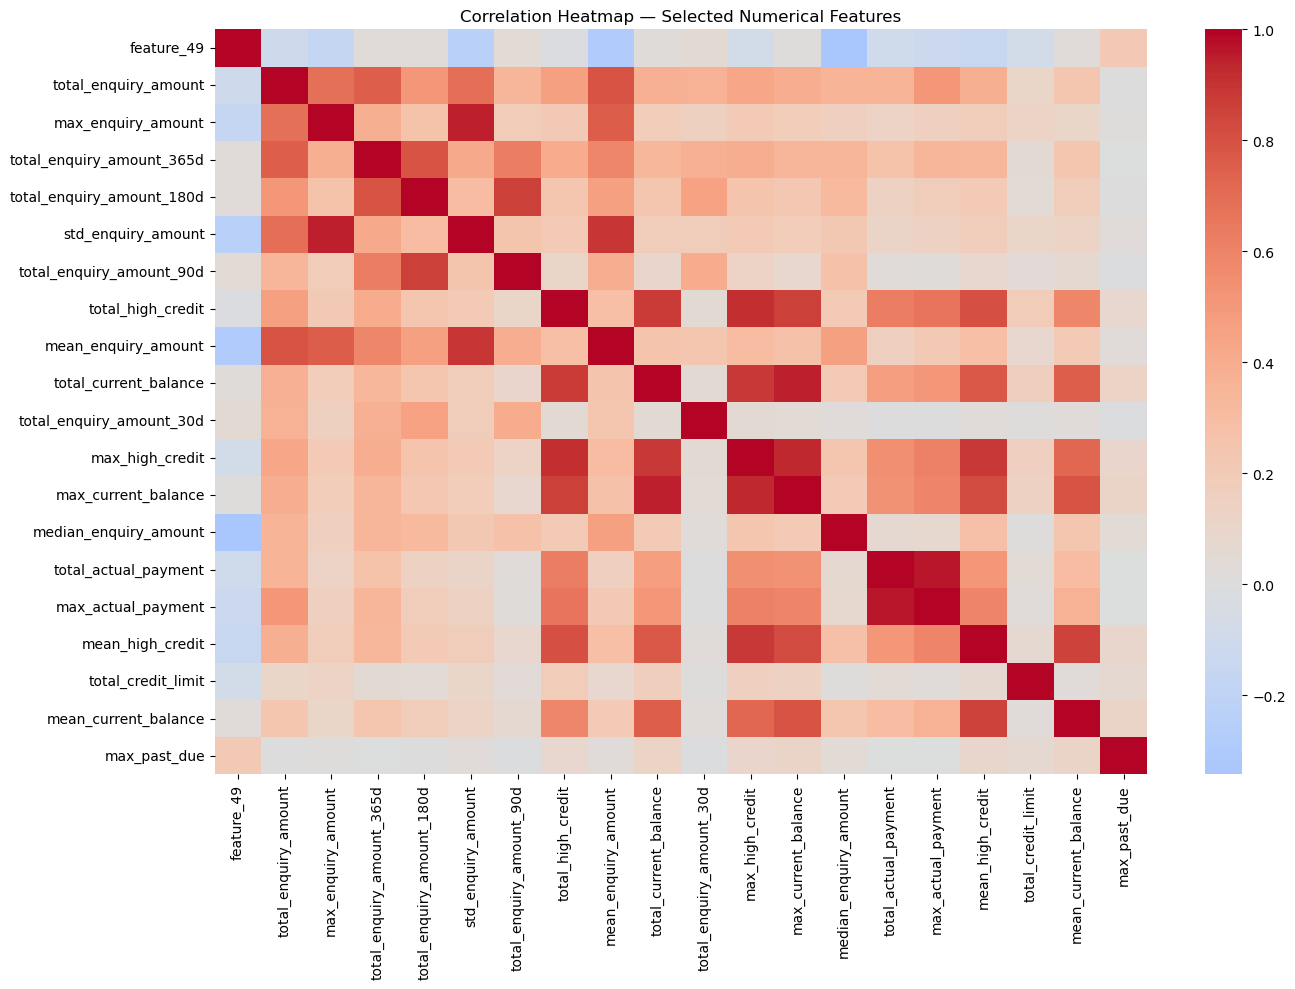

In [1317]:
plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    X_screen[
        top_numeric_cols
    ].corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap — Selected Numerical Features"
)

plt.tight_layout()

plt.show()

In [1318]:
target_corr_data = (
    X_screen
    .select_dtypes(
        include=np.number
    )
    .copy()
)

target_corr_data[
    "bad_label"
] = (
    y_screen.values
)

target_correlations = (
    target_corr_data
    .corr()[
        "bad_label"
    ]
    .drop(
        "bad_label"
    )
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    target_correlations
    .head(20)
)

feature_74                        -0.172
max_pastdue_balance_ratio          0.136
mean_pastdue_balance_ratio         0.133
feature_49                         0.099
recent_365d_enquiry_ratio          0.067
count_enquiry_recency_180          0.065
count_enquiry_recency_365          0.060
feature_7                         -0.059
count_enquiry_recency_90           0.058
recent_365d_amount_ratio           0.055
total_credit_limit                -0.054
feature_52                        -0.054
recent_90d_enquiry_ratio           0.053
mean_enquiry_recency_days         -0.053
max_open_to_lastpayment_months    -0.050
total_cash_limit                  -0.049
mean_open_to_lastpayment_months   -0.047
mean_payment_history_period       -0.045
feature_3                         -0.045
total_balance_highcredit_ratio     0.044
Name: bad_label, dtype: float64

In [1319]:
leakage_keywords = [
    "bad_label",
    "target",
    "default",
    "outcome",
    "response",
    "prediction",
    "predicted",
    "probability",
    "score"
]

potential_leakage_cols = []

for col in X_screen.columns:

    col_lower = (
        col.lower()
    )

    if any(
        keyword
        in col_lower

        for keyword
        in leakage_keywords
    ):

        potential_leakage_cols.append(
            col
        )

print(
    "Potential leakage columns:"
)

print(
    potential_leakage_cols
)

Potential leakage columns:
[]


In [1320]:
print(
    "bad_label inside X:",
    "bad_label"
    in X_screen.columns
)

bad_label inside X: False


In [1321]:
target_copy_cols = []

for col in X_screen.columns:

    try:

        if (
            X_screen[col]
            .reset_index(drop=True)
            .equals(
                y_screen
                .reset_index(drop=True)
            )
        ):

            target_copy_cols.append(
                col
            )

    except Exception:

        pass

print(
    "Exact target-copy features:",
    target_copy_cols
)

Exact target-copy features: []


In [1322]:
missing_over_50 = (
    X_screen
    .isnull()
    .mean()
    .mul(100)
)

missing_over_50 = (
    missing_over_50[
        missing_over_50 > 50
    ]
    .sort_values(
        ascending=False
    )
)

display(
    missing_over_50
)

feature_61                       99.962
feature_74                       99.929
feature_18                       99.925
feature_10                       99.787
feature_49                       99.565
max_pastdue_creditlimit_ratio    99.071
mean_pastdue_creditlimit_ratio   99.071
max_pastdue_balance_ratio        96.807
mean_pastdue_balance_ratio       96.807
max_past_due                     96.711
mean_past_due                    96.711
feature_17                       95.702
feature_8                        94.723
feature_9                        94.723
feature_57                       89.986
feature_73                       87.676
feature_48                       76.996
feature_45                       57.386
feature_13                       54.419
dtype: float64

In [1323]:
drop_high_missing_cols = [
    col

    for col in X_screen.columns

    if (
        X_screen[col]
        .isnull()
        .mean()
        * 100
    ) > 95
]

print(
    "Features selected for removal due to >95% missingness:"
)

print(
    drop_high_missing_cols
)

Features selected for removal due to >95% missingness:
['feature_10', 'feature_17', 'feature_18', 'feature_49', 'feature_61', 'feature_74', 'mean_past_due', 'max_past_due', 'mean_pastdue_balance_ratio', 'max_pastdue_balance_ratio', 'mean_pastdue_creditlimit_ratio', 'max_pastdue_creditlimit_ratio']


In [1324]:
X_screen.drop(
    columns=drop_high_missing_cols,
    inplace=True,
    errors="ignore"
)

print(
    "Shape after high-missingness removal:",
    X_screen.shape
)

Shape after high-missingness removal: (23896, 148)


In [1325]:
final_numeric_features = (
    X_screen
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

In [1326]:
final_categorical_features = (
    X_screen
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

In [1327]:
print(
    "Final numerical features:",
    len(final_numeric_features)
)

print(
    "Final categorical features:",
    len(final_categorical_features)
)

print(
    "Total:",
    len(final_numeric_features)
    +
    len(final_categorical_features)
)

Final numerical features: 104
Final categorical features: 44
Total: 148


In [1328]:
X_screen.shape[1]

148

In [1329]:
print(
    "Feature count matches:",
    (
        len(final_numeric_features)
        +
        len(final_categorical_features)
    )
    ==
    X_screen.shape[1]
)

Feature count matches: True


In [1330]:
final_missing_summary = pd.DataFrame({

    "Missing_Count":
        X_screen
        .isnull()
        .sum(),

    "Missing_Percentage":
        X_screen
        .isnull()
        .mean()
        * 100
})

final_missing_summary = (
    final_missing_summary[
        final_missing_summary[
            "Missing_Count"
        ] > 0
    ]
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(
    final_missing_summary.head(30)
)

,Missing_Count,Missing_Percentage
feature_8,22635,94.723
feature_9,22635,94.723
feature_57,21503,89.986
feature_73,20951,87.676
feature_48,18399,76.996
feature_45,13713,57.386
feature_13,13004,54.419
feature_53,11610,48.586
feature_51,11422,47.799
mean_interest_rate,10914,45.673


In [1331]:
X_final = (
    X_screen
    .copy()
)

y_final = (
    y_screen
    .copy()
)

In [1332]:
X_final.reset_index(
    drop=True,
    inplace=True
)

y_final.reset_index(
    drop=True,
    inplace=True
)

In [1333]:
print(
    "X_final shape:",
    X_final.shape
)

print(
    "y_final shape:",
    y_final.shape
)

X_final shape: (23896, 148)
y_final shape: (23896,)


In [1334]:
print(
    "Missing target values:",
    y_final.isnull().sum()
)

Missing target values: 0


In [1335]:
print(
    "Infinite numerical values:",
    np.isinf(
        X_final
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)

Infinite numerical values: 0


In [1336]:
remaining_constant_cols = [
    col

    for col in X_final.columns

    if X_final[col]
    .nunique(
        dropna=False
    ) <= 1
]

print(
    "Remaining constant features:",
    remaining_constant_cols
)

Remaining constant features: []


In [1337]:
print(
    "Target present in predictors:",
    "bad_label"
    in X_final.columns
)

Target present in predictors: False


In [1338]:
feature_screening_summary = pd.DataFrame({

    "Metric": [

        "Initial Features",

        "All-Missing Features Removed",

        "Constant Features Removed",

        "Duplicate Features Removed",

        "High-Missing (>95%) Features Removed",

        "Final Numerical Features",

        "Final Categorical Features",

        "Final Total Features",

        "Training Records",

        "Missing Target Values",

        "Infinite Values"
    ],

    "Value": [

        X.shape[1],

        len(
            all_missing_cols
        ),

        len(
            constant_cols
        ),

        len(
            duplicate_cols_to_remove
        ),

        len(
            drop_high_missing_cols
        ),

        len(
            final_numeric_features
        ),

        len(
            final_categorical_features
        ),

        X_final.shape[1],

        len(
            X_final
        ),

        y_final
        .isnull()
        .sum(),

        np.isinf(
            X_final
            .select_dtypes(
                include=np.number
            )
        )
        .sum()
        .sum()
    ]
})

feature_screening_summary

,Metric,Value
0,Initial Features,166
1,All-Missing Features Removed,0
2,Constant Features Removed,0
3,Duplicate Features Removed,6
4,High-Missing (>95%) Features Removed,12
5,Final Numerical Features,104
6,Final Categorical Features,44
7,Final Total Features,148
8,Training Records,23896
9,Missing Target Values,0


In [1339]:
feature_list_df = pd.DataFrame({

    "Feature":
        X_final.columns,

    "Data_Type":
        X_final.dtypes.astype(str).values,

    "Missing_Count":
        X_final.isnull().sum().values,

    "Missing_Percentage":
        (
            X_final
            .isnull()
            .mean()
            * 100
        ).values,

    "Unique_Values":
        [
            X_final[col]
            .nunique(
                dropna=True
            )

            for col
            in X_final.columns
        ]
})

display(
    feature_list_df
)

,Feature,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,dt_opened,object,0,0.000,197
1,entry_time,object,15,0.063,296
2,feature_1,object,15,0.063,7
3,feature_2,object,2836,11.868,281
4,feature_3,float64,2836,11.868,262
...,...,...,...,...,...
143,max_days_between_enquiries,float64,336,1.406,2286
144,enquiry_history_span_days,float64,109,0.456,3670
145,recent_90d_enquiry_ratio,float64,0,0.000,425
146,recent_365d_enquiry_ratio,float64,0,0.000,850


In [1340]:
final_pre_split_df = (
    X_final.copy()
)

final_pre_split_df[
    "bad_label"
] = (
    y_final.values
)

In [1341]:
final_pre_split_path = os.path.join(
    data_folder,
    "final_data_before_train_test_split.csv"
)

final_pre_split_df.to_csv(
    final_pre_split_path,
    index=False
)

print(
    "Final pre-split dataset saved successfully."
)

print(
    "Location:",
    final_pre_split_path
)

Final pre-split dataset saved successfully.
Location: Bank_GoodCredit_Data\final_data_before_train_test_split.csv


In [1342]:
feature_info_path = os.path.join(
    data_folder,
    "final_feature_information.csv"
)

feature_list_df.to_csv(
    feature_info_path,
    index=False
)

print(
    "Feature information saved successfully."
)

Feature information saved successfully.


In [1343]:
print(
    "Pre-split dataset exists:",
    os.path.exists(
        final_pre_split_path
    )
)

print(
    "Feature information exists:",
    os.path.exists(
        feature_info_path
    )
)

Pre-split dataset exists: True
Feature information exists: True


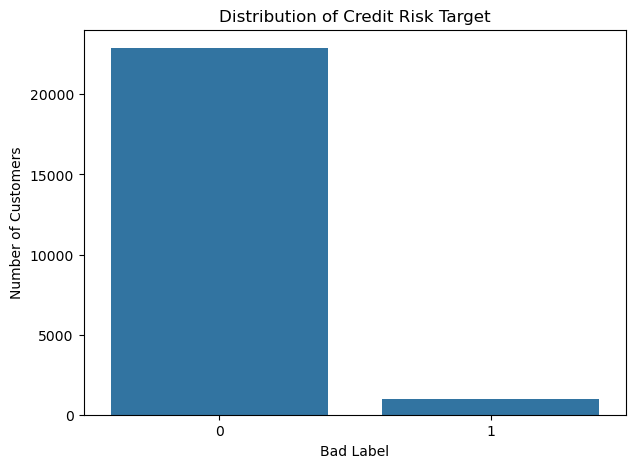

In [1344]:
plt.figure(
    figsize=(7, 5)
)

sns.countplot(
    x=y_final
)

plt.title(
    "Distribution of Credit Risk Target"
)

plt.xlabel(
    "Bad Label"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [1345]:
target_summary = pd.DataFrame({

    "Count":
        y_final
        .value_counts(),

    "Percentage":
        y_final
        .value_counts(
            normalize=True
        )
        * 100
})

target_summary

,Count,Percentage
bad_label,,
0,22892,95.798
1,1004,4.202


In [1346]:
print("=" * 75)
print("FINAL FEATURE SCREENING VALIDATION")
print("=" * 75)

print(
    "Number of Customers:",
    len(X_final)
)

print(
    "Final Predictor Features:",
    X_final.shape[1]
)

print(
    "Numerical Features:",
    len(
        final_numeric_features
    )
)

print(
    "Categorical Features:",
    len(
        final_categorical_features
    )
)

print(
    "\nMissing Target Values:",
    y_final
    .isnull()
    .sum()
)

print(
    "Target Classes:",
    sorted(
        y_final
        .dropna()
        .unique()
    )
)

print(
    "\nTarget in Predictors:",
    "bad_label"
    in X_final.columns
)

print(
    "Remaining Constant Features:",
    len(
        remaining_constant_cols
    )
)

print(
    "Infinite Numerical Values:",
    np.isinf(
        X_final
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
)

print(
    "\nAll-Missing Features Removed:",
    len(
        all_missing_cols
    )
)

print(
    "Constant Features Removed:",
    len(
        constant_cols
    )
)

print(
    "Duplicate Features Removed:",
    len(
        duplicate_cols_to_remove
    )
)

print(
    "High-Missing Features Removed:",
    len(
        drop_high_missing_cols
    )
)

print("=" * 75)

if (
    len(X_final)
    == len(y_final)

    and

    y_final
    .isnull()
    .sum()
    == 0

    and

    "bad_label"
    not in X_final.columns

    and

    np.isinf(
        X_final
        .select_dtypes(
            include=np.number
        )
    )
    .sum()
    .sum()
    == 0
):

    print(
        "VALIDATION PASSED"
    )

else:

    print(
        "PLEASE CHECK THE VALIDATION RESULTS ABOVE"
    )

print("=" * 75)

FINAL FEATURE SCREENING VALIDATION
Number of Customers: 23896
Final Predictor Features: 148
Numerical Features: 104
Categorical Features: 44

Missing Target Values: 0
Target Classes: [0, 1]

Target in Predictors: False
Remaining Constant Features: 0
Infinite Numerical Values: 0

All-Missing Features Removed: 0
Constant Features Removed: 0
Duplicate Features Removed: 6
High-Missing Features Removed: 12
VALIDATION PASSED


## Feature Screening — Summary

After integrating the Demographics, Account and Enquiry datasets,
feature screening was performed before model development.

### Missing-Value Analysis

Predictor variables were evaluated based on the percentage of missing
observations.

Completely empty variables were removed because they contained no
predictive information.

Variables with extremely high missingness were also identified and
reviewed before removal.

Missing values in the retained predictors were not globally imputed
at this stage. Imputation will be learned from the training dataset
during model preprocessing to reduce the risk of data leakage.

### Constant and Near-Constant Features

Constant variables were removed because they contained no variation
between customers.

Near-constant variables were identified separately for investigation,
since rare values may still contain useful credit-risk information.

### Duplicate Features

Features containing exactly identical observations were identified to
reduce unnecessary redundancy.

### Categorical Feature Analysis

Categorical predictors were examined based on the number of unique
categories.

High-cardinality categorical variables were identified for additional
review before one-hot encoding.

### Correlation Analysis

Numerical predictors were evaluated for highly correlated feature
pairs.

Highly correlated variables were reported rather than automatically
removed because tree-based machine-learning algorithms can effectively
handle correlated predictors, while regularization can be applied to
linear models.

### Target Leakage

Predictor names and values were screened for potential target leakage.

The target variable `bad_label` was confirmed to be excluded from the
predictor matrix.

### Final Feature Matrix

After feature screening, the cleaned predictor matrix was stored as
X_final and the target vector as y_final.

The resulting data is ready for stratified train-test splitting and
machine-learning preprocessing.

## Machine Learning Model Development

## Objective

The objective of this stage is to develop baseline machine-learning
models for predicting customer credit risk.

The final customer-level feature matrix created during the previous
stages is divided into training and testing datasets using stratified
sampling.

A preprocessing pipeline is constructed separately for numerical and
categorical variables.

Numerical variables are processed using median imputation and feature
scaling.

Categorical variables are processed using missing-value imputation and
one-hot encoding.

The following baseline classification algorithms are evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- Classification Report

The objective is not simply to obtain the highest accuracy, but to
compare the models and identify the most suitable candidates for
further optimization.

## Import required libraries

In [1350]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [1351]:
print("=" * 70)
print("DATASET BEFORE TRAIN-TEST SPLIT")
print("=" * 70)

print(
    "X_final shape:",
    X_final.shape
)

print(
    "y_final shape:",
    y_final.shape
)

print(
    "\nMissing target values:",
    y_final.isnull().sum()
)

print(
    "\nTarget distribution:"
)

print(
    y_final.value_counts()
)

print(
    "\nTarget percentage:"
)

print(
    y_final.value_counts(
        normalize=True
    ) * 100
)

DATASET BEFORE TRAIN-TEST SPLIT
X_final shape: (23896, 148)
y_final shape: (23896,)

Missing target values: 0

Target distribution:
bad_label
0    22892
1     1004
Name: count, dtype: int64

Target percentage:
bad_label
0   95.798
1    4.202
Name: proportion, dtype: float64


In [1352]:
y_final = pd.to_numeric(
    y_final,
    errors="raise"
).astype(int)

print(
    "Target datatype:",
    y_final.dtype
)

print(
    "Target classes:",
    sorted(
        y_final.unique()
    )
)

Target datatype: int32
Target classes: [0, 1]


In [1353]:
numeric_features = (
    X_final
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

In [1354]:
categorical_features = (
    X_final
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

In [1355]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Total features:",
    len(numeric_features)
    +
    len(categorical_features)
)

print(
    "X_final columns:",
    X_final.shape[1]
)

Numerical features: 104
Categorical features: 44
Total features: 148
X_final columns: 148


In [1356]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

In [1357]:
print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

TRAIN-TEST SPLIT
X_train: (19116, 148)
X_test: (4780, 148)
y_train: (19116,)
y_test: (4780,)


In [1358]:
split_distribution = pd.DataFrame({

    "Full_Data":
        y_final.value_counts(
            normalize=True
        ),

    "Training_Data":
        y_train.value_counts(
            normalize=True
        ),

    "Testing_Data":
        y_test.value_counts(
            normalize=True
        )
}) * 100

split_distribution


,Full_Data,Training_Data,Testing_Data
bad_label,,,
0,95.798,95.799,95.795
1,4.202,4.201,4.205


## Why Train-Test Split Was Performed Before Preprocessing

The dataset was divided into training and testing sets before fitting
the preprocessing transformations.

This prevents information from the testing dataset from influencing
the preprocessing parameters learned during model development.

For example, numerical median values and scaling parameters should be
estimated using the training data only.

The same fitted transformations are then applied to the unseen test
dataset.

This approach helps reduce data leakage and provides a more realistic
estimate of model performance.

In [1360]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [1361]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [1362]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

In [1363]:
def evaluate_model(
    model_name,
    model,
    X_test,
    y_test
):

    # Predictions
    y_pred = model.predict(
        X_test
    )

    # Probability for class 1
    if hasattr(
        model,
        "predict_proba"
    ):

        y_prob = (
            model
            .predict_proba(
                X_test
            )[:, 1]
        )

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

    else:

        y_prob = None
        roc_auc = np.nan


    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )


    print("=" * 70)

    print(
        model_name
    )

    print("=" * 70)

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )


    print(
        "\nCLASSIFICATION REPORT\n"
    )

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4,
            zero_division=0
        )
    )


    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(
        figsize=(6, 4)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"{model_name} — Confusion Matrix"
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "Actual Label"
    )

    plt.show()


    return {
        "Model":
            model_name,

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1 Score":
            f1,

        "ROC-AUC":
            roc_auc
    }

In [1364]:
baseline_results = []

In [1365]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [1366]:
print(
    "Training Logistic Regression..."
)

logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed."
)

Training Logistic Regression...
Logistic Regression training completed.


Logistic Regression
Accuracy : 0.9567
Precision: 0.1250
Recall   : 0.0050
F1 Score : 0.0096
ROC-AUC  : 0.6268

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9581    0.9985    0.9779      4579
           1     0.1250    0.0050    0.0096       201

    accuracy                         0.9567      4780
   macro avg     0.5415    0.5017    0.4937      4780
weighted avg     0.9231    0.9567    0.9371      4780



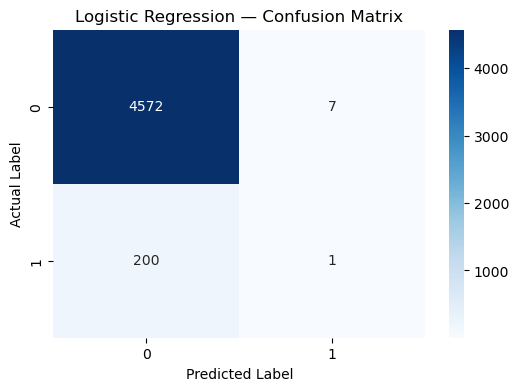

In [1367]:
logistic_result = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    X_test,
    y_test
)

baseline_results.append(
    logistic_result
)

In [1368]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=5
            )
        )
    ]
)

In [1369]:
print(
    "Training Decision Tree..."
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print(
    "Decision Tree training completed."
)

Training Decision Tree...
Decision Tree training completed.


Decision Tree
Accuracy : 0.9496
Precision: 0.0652
Recall   : 0.0149
F1 Score : 0.0243
ROC-AUC  : 0.6509

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9582    0.9906    0.9741      4579
           1     0.0652    0.0149    0.0243       201

    accuracy                         0.9496      4780
   macro avg     0.5117    0.5028    0.4992      4780
weighted avg     0.9206    0.9496    0.9342      4780



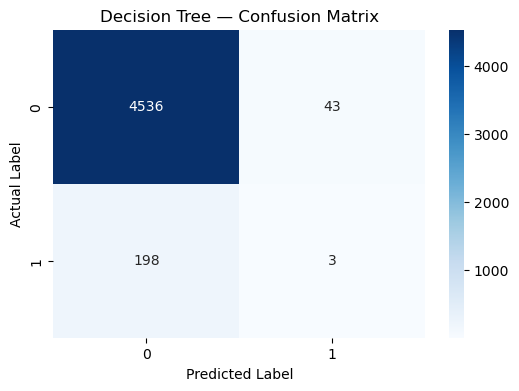

In [1370]:
decision_tree_result = evaluate_model(
    "Decision Tree",
    decision_tree_pipeline,
    X_test,
    y_test
)

baseline_results.append(
    decision_tree_result
)

In [1371]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [1372]:
print(
    "Training Random Forest..."
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print(
    "Random Forest training completed."
)

Training Random Forest...
Random Forest training completed.


Random Forest
Accuracy : 0.9579
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.6503

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9579    1.0000    0.9785      4579
           1     0.0000    0.0000    0.0000       201

    accuracy                         0.9579      4780
   macro avg     0.4790    0.5000    0.4893      4780
weighted avg     0.9177    0.9579    0.9374      4780



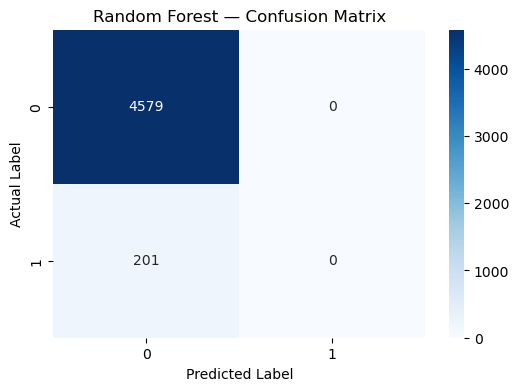

In [1373]:
random_forest_result = evaluate_model(
    "Random Forest",
    random_forest_pipeline,
    X_test,
    y_test
)

baseline_results.append(
    random_forest_result
)

In [1374]:
knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=7,
                weights="distance",
                n_jobs=-1
            )
        )
    ]
)

In [1375]:
print(
    "Training KNN..."
)

knn_pipeline.fit(
    X_train,
    y_train
)

print(
    "KNN training completed."
)

Training KNN...
KNN training completed.


K-Nearest Neighbors
Accuracy : 0.9575
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5424

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9579    0.9996    0.9783      4579
           1     0.0000    0.0000    0.0000       201

    accuracy                         0.9575      4780
   macro avg     0.4790    0.4998    0.4892      4780
weighted avg     0.9177    0.9575    0.9372      4780



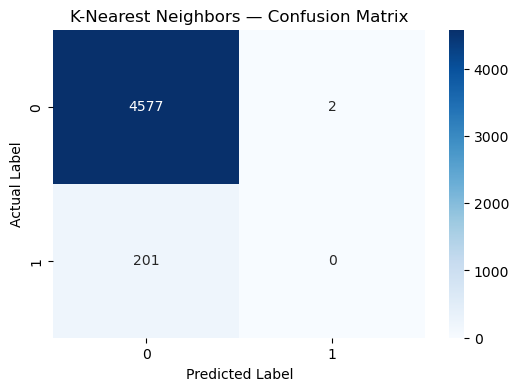

In [1376]:
knn_result = evaluate_model(
    "K-Nearest Neighbors",
    knn_pipeline,
    X_test,
    y_test
)

baseline_results.append(
    knn_result
)

## Support Vector Machine

Support Vector Machine was not included in the primary baseline
comparison because training on the available customer dataset was
computationally expensive.

SVM training complexity can increase substantially with dataset size,
particularly when nonlinear kernels are used.

The model was therefore excluded from the main baseline comparison to
keep the experimentation computationally practical.

Other classification algorithms including Logistic Regression,
Decision Tree, Random Forest and K-Nearest Neighbors were evaluated.

In [1378]:
baseline_comparison = pd.DataFrame(
    baseline_results
)

baseline_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.957,0.125,0.005,0.010,0.627
1,Decision Tree,0.950,0.065,0.015,0.024,0.651
2,Random Forest,0.958,0.000,0.000,0.000,0.650
3,K-Nearest Neighbors,0.958,0.000,0.000,0.000,0.542


In [1379]:
baseline_comparison = (
    baseline_comparison
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

baseline_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.950,0.065,0.015,0.024,0.651
1,Random Forest,0.958,0.000,0.000,0.000,0.650
2,Logistic Regression,0.957,0.125,0.005,0.010,0.627
3,K-Nearest Neighbors,0.958,0.000,0.000,0.000,0.542


In [1380]:
baseline_comparison_display = (
    baseline_comparison.copy()
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

baseline_comparison_display[
    metric_columns
] = (
    baseline_comparison_display[
        metric_columns
    ]
    .round(4)
)

baseline_comparison_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.950,0.065,0.015,0.024,0.651
1,Random Forest,0.958,0.000,0.000,0.000,0.650
2,Logistic Regression,0.957,0.125,0.005,0.010,0.627
3,K-Nearest Neighbors,0.958,0.000,0.000,0.000,0.542


In [1381]:
comparison_long = (
    baseline_comparison
    .melt(
        id_vars="Model",
        value_vars=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        var_name="Metric",
        value_name="Score"
    )
)

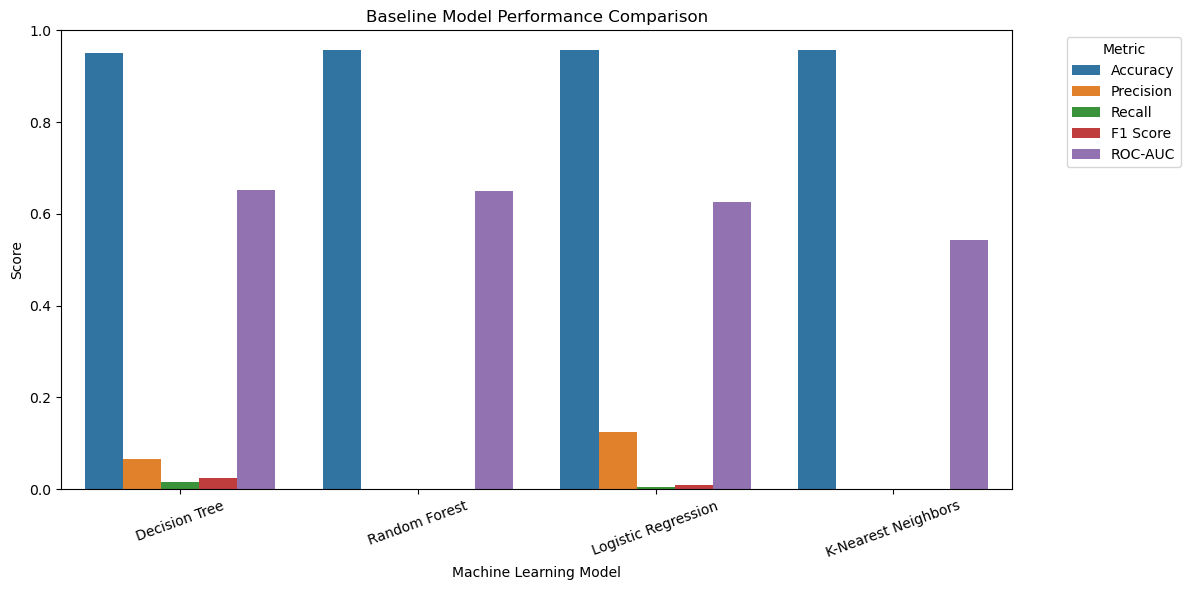

In [1382]:
plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Baseline Model Performance Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

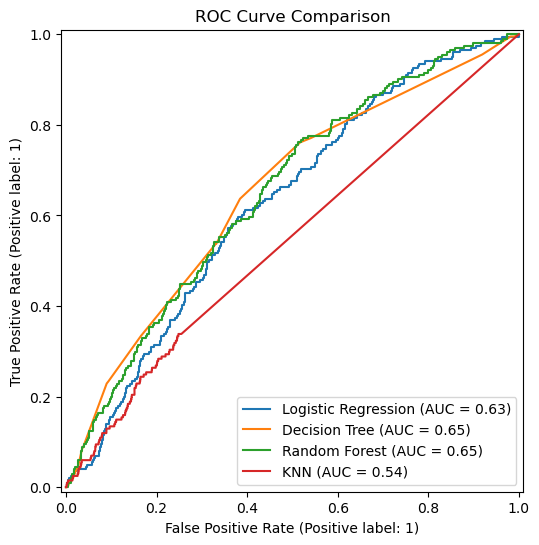

In [1383]:
plt.figure(
    figsize=(8, 6)
)

ax = plt.gca()

RocCurveDisplay.from_estimator(
    logistic_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    decision_tree_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Decision Tree"
)

RocCurveDisplay.from_estimator(
    random_forest_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Random Forest"
)

if "knn_result" in globals():

    RocCurveDisplay.from_estimator(
        knn_pipeline,
        X_test,
        y_test,
        ax=ax,
        name="KNN"
    )

plt.title(
    "ROC Curve Comparison"
)

plt.show()

In [1384]:
log_train_accuracy = (
    logistic_pipeline
    .score(
        X_train,
        y_train
    )
)

log_test_accuracy = (
    logistic_pipeline
    .score(
        X_test,
        y_test
    )
)

print(
    "Logistic Regression"
)

print(
    "Training Accuracy:",
    round(
        log_train_accuracy,
        4
    )
)

print(
    "Testing Accuracy:",
    round(
        log_test_accuracy,
        4
    )
)

Logistic Regression
Training Accuracy: 0.9751
Testing Accuracy: 0.9567


In [1385]:
dt_train_accuracy = (
    decision_tree_pipeline
    .score(
        X_train,
        y_train
    )
)

dt_test_accuracy = (
    decision_tree_pipeline
    .score(
        X_test,
        y_test
    )
)

print(
    "Decision Tree"
)

print(
    "Training Accuracy:",
    round(
        dt_train_accuracy,
        4
    )
)

print(
    "Testing Accuracy:",
    round(
        dt_test_accuracy,
        4
    )
)

Decision Tree
Training Accuracy: 0.9614
Testing Accuracy: 0.9496


In [1386]:
rf_train_accuracy = (
    random_forest_pipeline
    .score(
        X_train,
        y_train
    )
)

rf_test_accuracy = (
    random_forest_pipeline
    .score(
        X_test,
        y_test
    )
)

print(
    "Random Forest"
)

print(
    "Training Accuracy:",
    round(
        rf_train_accuracy,
        4
    )
)

print(
    "Testing Accuracy:",
    round(
        rf_test_accuracy,
        4
    )
)

Random Forest
Training Accuracy: 0.958
Testing Accuracy: 0.9579


In [1387]:
if "knn_result" in globals():

    knn_train_accuracy = (
        knn_pipeline
        .score(
            X_train,
            y_train
        )
    )

    knn_test_accuracy = (
        knn_pipeline
        .score(
            X_test,
            y_test
        )
    )

    print(
        "KNN"
    )

    print(
        "Training Accuracy:",
        round(
            knn_train_accuracy,
            4
        )
    )

    print(
        "Testing Accuracy:",
        round(
            knn_test_accuracy,
            4
        )
    )

KNN
Training Accuracy: 1.0
Testing Accuracy: 0.9575


In [1388]:
overfitting_results = [
    {
        "Model":
            "Logistic Regression",

        "Training Accuracy":
            log_train_accuracy,

        "Testing Accuracy":
            log_test_accuracy
    },

    {
        "Model":
            "Decision Tree",

        "Training Accuracy":
            dt_train_accuracy,

        "Testing Accuracy":
            dt_test_accuracy
    },

    {
        "Model":
            "Random Forest",

        "Training Accuracy":
            rf_train_accuracy,

        "Testing Accuracy":
            rf_test_accuracy
    }
]

if "knn_result" in globals():

    overfitting_results.append(
        {
            "Model":
                "K-Nearest Neighbors",

            "Training Accuracy":
                knn_train_accuracy,

            "Testing Accuracy":
                knn_test_accuracy
        }
    )

In [1389]:
overfitting_df = pd.DataFrame(
    overfitting_results
)

overfitting_df[
    "Accuracy Gap"
] = (
    overfitting_df[
        "Training Accuracy"
    ]
    -
    overfitting_df[
        "Testing Accuracy"
    ]
)

overfitting_df[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy Gap"
    ]
] = (
    overfitting_df[
        [
            "Training Accuracy",
            "Testing Accuracy",
            "Accuracy Gap"
        ]
    ]
    .round(4)
)

overfitting_df

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.975,0.957,0.018
1,Decision Tree,0.961,0.950,0.012
2,Random Forest,0.958,0.958,0.000
3,K-Nearest Neighbors,1.000,0.958,0.043


In [1390]:
best_baseline_model = (
    baseline_comparison
    .iloc[0]
)

print("=" * 70)

print(
    "BEST BASELINE MODEL"
)

print("=" * 70)

print(
    "Model:",
    best_baseline_model[
        "Model"
    ]
)

print(
    "Accuracy:",
    round(
        best_baseline_model[
            "Accuracy"
        ],
        4
    )
)

print(
    "Precision:",
    round(
        best_baseline_model[
            "Precision"
        ],
        4
    )
)

print(
    "Recall:",
    round(
        best_baseline_model[
            "Recall"
        ],
        4
    )
)

print(
    "F1 Score:",
    round(
        best_baseline_model[
            "F1 Score"
        ],
        4
    )
)

print(
    "ROC-AUC:",
    round(
        best_baseline_model[
            "ROC-AUC"
        ],
        4
    )
)

BEST BASELINE MODEL
Model: Decision Tree
Accuracy: 0.9496
Precision: 0.0652
Recall: 0.0149
F1 Score: 0.0243
ROC-AUC: 0.6509


In [1391]:
baseline_results_path = os.path.join(
    data_folder,
    "baseline_model_comparison.csv"
)

baseline_comparison.to_csv(
    baseline_results_path,
    index=False
)

print(
    "Baseline comparison saved."
)

print(
    baseline_results_path
)

Baseline comparison saved.
Bank_GoodCredit_Data\baseline_model_comparison.csv


In [1392]:
overfitting_path = os.path.join(
    data_folder,
    "baseline_overfitting_check.csv"
)

overfitting_df.to_csv(
    overfitting_path,
    index=False
)

print(
    "Overfitting comparison saved."
)

Overfitting comparison saved.


In [1393]:
print("=" * 75)
print("FINAL VALIDATION")
print("=" * 75)

print(
    "Training Records:",
    len(X_train)
)

print(
    "Testing Records:",
    len(X_test)
)

print(
    "\nTraining Target Distribution:"
)

print(
    y_train.value_counts(
        normalize=True
    ).round(4)
)

print(
    "\nTesting Target Distribution:"
)

print(
    y_test.value_counts(
        normalize=True
    ).round(4)
)

print(
    "\nNumerical Features:",
    len(numeric_features)
)

print(
    "Categorical Features:",
    len(categorical_features)
)

print(
    "\nModels Successfully Evaluated:",
    len(baseline_results)
)

print(
    "\nModels:"
)

for model_name in (
    baseline_comparison[
        "Model"
    ]
):

    print(
        "-",
        model_name
    )

print(
    "\nBest Baseline Model:",
    baseline_comparison.iloc[0][
        "Model"
    ]
)

print(
    "Best Baseline ROC-AUC:",
    round(
        baseline_comparison.iloc[0][
            "ROC-AUC"
        ],
        4
    )
)

print("=" * 75)

if (
    len(X_train)
    +
    len(X_test)
    ==
    len(X_final)

    and

    len(y_train)
    +
    len(y_test)
    ==
    len(y_final)

    and

    len(baseline_results)
    >= 3
):

    print(
        "VALIDATION PASSED"
    )

else:

    print(
        "CHECK RESULTS"
    )

print("=" * 75)

FINAL VALIDATION
Training Records: 19116
Testing Records: 4780

Training Target Distribution:
bad_label
0   0.958
1   0.042
Name: proportion, dtype: float64

Testing Target Distribution:
bad_label
0   0.958
1   0.042
Name: proportion, dtype: float64

Numerical Features: 104
Categorical Features: 44

Models Successfully Evaluated: 4

Models:
- Decision Tree
- Random Forest
- Logistic Regression
- K-Nearest Neighbors

Best Baseline Model: Decision Tree
Best Baseline ROC-AUC: 0.6509
VALIDATION PASSED


## Baseline Machine-Learning Model Development

The final customer-level dataset was divided into training and testing
subsets using an 80:20 stratified train-test split.

Stratification was used to preserve approximately the same target
class distribution in both subsets.

### Data Preprocessing

A preprocessing pipeline was developed separately for numerical and
categorical variables.

Numerical missing values were imputed using the median and numerical
variables were standardized using StandardScaler.

Categorical missing values were imputed using the most frequent
category and categorical variables were transformed using one-hot
encoding.

All preprocessing transformations were fitted through machine-learning
pipelines using the training data, reducing the risk of information
leakage from the test dataset.

### Baseline Models

The following classification algorithms were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

Support Vector Machine was excluded from the primary comparison because
of its computational cost on the available dataset.

### Model Evaluation

Each model was evaluated on the unseen testing dataset using Accuracy,
Precision, Recall, F1 Score and ROC-AUC.

Classification reports and confusion matrices were also generated to
evaluate class-specific predictive performance.

Training and testing accuracy were compared as an initial assessment
of model overfitting.

The baseline comparison provides a reference point for subsequent
hyperparameter optimization and final model selection.

## PART 8 — Hyperparameter Tuning and Advanced Model Development

## Objective

The objective of this stage is to improve the baseline machine-learning
models through hyperparameter optimization and cross-validation.

The Decision Tree and Random Forest models are optimized using
RandomizedSearchCV.

XGBoost is also evaluated as an advanced gradient-boosting algorithm
if the library is available.

Hyperparameter tuning is performed only on the training dataset.

Cross-validation is used during model selection so that model
performance is not judged using a single training-validation split.

The final tuned models are evaluated on the untouched test dataset
using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Classification Report
- Confusion Matrix

Training and testing performance are also compared to identify
possible overfitting.

The final model is selected based on predictive performance and
generalization rather than accuracy alone.

In [1396]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

print("libraries imported successfully.")

libraries imported successfully.


In [1397]:
print("=" * 70)
print("DATA CHECK")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

DATA CHECK
X_train: (19116, 148)
X_test : (4780, 148)
y_train: (19116,)
y_test : (4780,)

Training target:
bad_label
0    18313
1      803
Name: count, dtype: int64

Testing target:
bad_label
0    4579
1     201
Name: count, dtype: int64


In [1398]:
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("3-fold Stratified Cross-Validation created.")

3-fold Stratified Cross-Validation created.


In [1399]:
logistic_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV ROC-AUC scores:")
print(logistic_cv_scores)

print(
    "\nMean CV ROC-AUC:",
    round(logistic_cv_scores.mean(), 4)
)

print(
    "CV Standard Deviation:",
    round(logistic_cv_scores.std(), 4)
)

Logistic Regression CV ROC-AUC scores:
[0.60463794 0.59739637 0.60050847]

Mean CV ROC-AUC: 0.6008
CV Standard Deviation: 0.003


In [1400]:
dt_cv_scores = cross_val_score(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Decision Tree CV ROC-AUC scores:")
print(dt_cv_scores)

print(
    "\nMean CV ROC-AUC:",
    round(dt_cv_scores.mean(), 4)
)

print(
    "CV Standard Deviation:",
    round(dt_cv_scores.std(), 4)
)

Decision Tree CV ROC-AUC scores:
[0.54363557 0.6080112  0.56910473]

Mean CV ROC-AUC: 0.5736
CV Standard Deviation: 0.0265


In [1401]:
rf_cv_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest CV ROC-AUC scores:")
print(rf_cv_scores)

print(
    "\nMean CV ROC-AUC:",
    round(rf_cv_scores.mean(), 4)
)

print(
    "CV Standard Deviation:",
    round(rf_cv_scores.std(), 4)
)

Random Forest CV ROC-AUC scores:
[0.6661906  0.63399337 0.6388171 ]

Mean CV ROC-AUC: 0.6463
CV Standard Deviation: 0.0142


In [1402]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Mean CV ROC-AUC": [
        logistic_cv_scores.mean(),
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ],

    "CV Std": [
        logistic_cv_scores.std(),
        dt_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

cv_comparison[
    ["Mean CV ROC-AUC", "CV Std"]
] = cv_comparison[
    ["Mean CV ROC-AUC", "CV Std"]
].round(4)

cv_comparison.sort_values(
    "Mean CV ROC-AUC",
    ascending=False
)

,Model,Mean CV ROC-AUC,CV Std
2,Random Forest,0.646,0.014
0,Logistic Regression,0.601,0.003
1,Decision Tree,0.574,0.026


In [1403]:
dt_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [1404]:
dt_param_dist = {

    "classifier__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "classifier__max_depth": [
        4,
        6,
        8,
        10,
        12,
        15,
        20,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10,
        20,
        30,
        50
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4,
        5,
        10,
        20
    ],

    "classifier__max_features": [
        None,
        "sqrt",
        "log2"
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

In [1405]:
dt_random_search = RandomizedSearchCV(
    estimator=dt_tuning_pipeline,
    param_distributions=dt_param_dist,

    n_iter=30,

    scoring="roc_auc",

    cv=cv_strategy,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

In [1406]:
print("Starting Decision Tree hyperparameter tuning...")

dt_random_search.fit(
    X_train,
    y_train
)

print("Decision Tree tuning completed.")

Starting Decision Tree hyperparameter tuning...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Decision Tree tuning completed.


In [1407]:
print("=" * 70)
print("BEST DECISION TREE PARAMETERS")
print("=" * 70)

print(
    dt_random_search.best_params_
)

print(
    "\nBest Cross-Validation ROC-AUC:",
    round(
        dt_random_search.best_score_,
        4
    )
)

BEST DECISION TREE PARAMETERS
{'classifier__min_samples_split': 30, 'classifier__min_samples_leaf': 5, 'classifier__max_features': None, 'classifier__max_depth': 6, 'classifier__criterion': 'gini', 'classifier__class_weight': None}

Best Cross-Validation ROC-AUC: 0.5965


In [1408]:
best_dt_model = (
    dt_random_search.best_estimator_
)

In [1409]:
def evaluate_tuned_model(
    model_name,
    model,
    X_train,
    y_train,
    X_test,
    y_test
):

    # ----------------------------
    # Predictions
    # ----------------------------

    y_train_pred = model.predict(
        X_train
    )

    y_test_pred = model.predict(
        X_test
    )


    # ----------------------------
    # Probabilities
    # ----------------------------

    if hasattr(
        model,
        "predict_proba"
    ):

        y_train_prob = (
            model
            .predict_proba(
                X_train
            )[:, 1]
        )

        y_test_prob = (
            model
            .predict_proba(
                X_test
            )[:, 1]
        )

        train_auc = roc_auc_score(
            y_train,
            y_train_prob
        )

        test_auc = roc_auc_score(
            y_test,
            y_test_prob
        )

    else:

        train_auc = np.nan
        test_auc = np.nan


    # ----------------------------
    # Test metrics
    # ----------------------------

    accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    precision = precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    )


    # ----------------------------
    # Training metrics
    # ----------------------------

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )


    # ----------------------------
    # Print results
    # ----------------------------

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        f"Training Accuracy : {train_accuracy:.4f}"
    )

    print(
        f"Testing Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Accuracy Gap      : {train_accuracy - accuracy:.4f}"
    )

    print(
        f"Training ROC-AUC  : {train_auc:.4f}"
    )

    print(
        f"Testing ROC-AUC   : {test_auc:.4f}"
    )

    print(
        f"ROC-AUC Gap       : {train_auc - test_auc:.4f}"
    )

    print(
        f"\nPrecision         : {precision:.4f}"
    )

    print(
        f"Recall            : {recall:.4f}"
    )

    print(
        f"F1 Score          : {f1:.4f}"
    )


    print(
        "\nCLASSIFICATION REPORT\n"
    )

    print(
        classification_report(
            y_test,
            y_test_pred,
            digits=4,
            zero_division=0
        )
    )


    # ----------------------------
    # Confusion Matrix
    # ----------------------------

    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    plt.figure(
        figsize=(6, 4)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"{model_name} — Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()


    return {

        "Model":
            model_name,

        "Training Accuracy":
            train_accuracy,

        "Testing Accuracy":
            accuracy,

        "Accuracy Gap":
            train_accuracy - accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1 Score":
            f1,

        "Training ROC-AUC":
            train_auc,

        "Testing ROC-AUC":
            test_auc,

        "ROC-AUC Gap":
            train_auc - test_auc
    }

Tuned Decision Tree
Training Accuracy : 0.9587
Testing Accuracy  : 0.9565
Accuracy Gap      : 0.0022
Training ROC-AUC  : 0.6642
Testing ROC-AUC   : 0.6305
ROC-AUC Gap       : 0.0336

Precision         : 0.0000
Recall            : 0.0000
F1 Score          : 0.0000

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9579    0.9985    0.9778      4579
           1     0.0000    0.0000    0.0000       201

    accuracy                         0.9565      4780
   macro avg     0.4789    0.4992    0.4889      4780
weighted avg     0.9176    0.9565    0.9366      4780



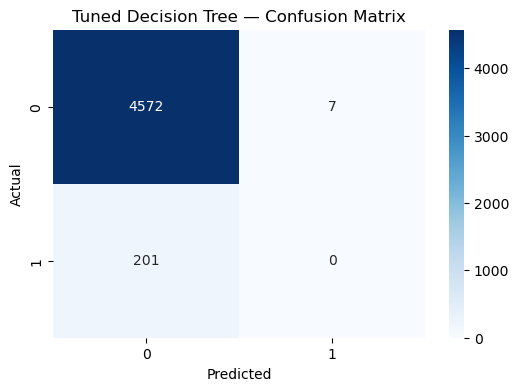

In [1410]:
tuned_results = []

tuned_dt_result = evaluate_tuned_model(
    "Tuned Decision Tree",
    best_dt_model,
    X_train,
    y_train,
    X_test,
    y_test
)

tuned_results.append(
    tuned_dt_result
)

In [1411]:
rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [1412]:
rf_param_dist = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[10,15],

    "classifier__min_samples_split":[5,10],

    "classifier__min_samples_leaf":[2,4],

    "classifier__max_features":["sqrt"],

    "classifier__class_weight":[None,"balanced"]
}

In [1413]:
rf_random_search = RandomizedSearchCV(

    estimator=rf_tuning_pipeline,

    param_distributions=rf_param_dist,

    n_iter=5,

    cv=2,

    scoring="roc_auc",

    random_state=42,

    n_jobs=-1,

    verbose=2
)

In [1414]:
rf_final = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier",
     RandomForestClassifier(
         n_estimators=200,
         max_depth=15,
         min_samples_split=5,
         min_samples_leaf=2,
         random_state=42,
         n_jobs=-1
     ))
])

rf_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['feature_3', 'feature_4',
                                                   'feature_6', 'feature_7',
                                                   'feature_14', 'feature_19',
                                                   'feature_25', 'feature_26',
                                                   'feature_29', 'feature_30',
                                                   'feature_31', 'feature_34',
                                                   'feature_35', 'feature_39',
                                                   'feature_...
                                                   'feature_22', 'feature_23',
                                                   'feature_24', 'feature_27',
                                                   'feature_28', 'feature_32',
                                                   'feature_33', 'feature_36',
                                                   'feature_37', 'feature_38',
                                                   'feature_43', 'feature_45',
                                                   'feature_46', 'feature_47',
                                                   'feature_48', 'feature_50', ...])])),
                ('classifier',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [1415]:
print("Starting Random Forest tuning...")
print("This may take some time.")

rf_random_search.fit(
    X_train,
    y_train
)

print(
    "Random Forest tuning completed."
)

Starting Random Forest tuning...
This may take some time.
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Random Forest tuning completed.


In [1879]:
print("=" * 70)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 70)

print(
    rf_random_search.best_params_
)

print(
    "\nBest Cross-Validation ROC-AUC:",
    round(
        rf_random_search.best_score_,
        4
    )
)

BEST RANDOM FOREST PARAMETERS
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15, 'classifier__class_weight': 'balanced'}

Best Cross-Validation ROC-AUC: 0.6487


In [1881]:
best_rf_model = (
    rf_random_search.best_estimator_
)

Tuned Random Forest
Training Accuracy : 0.8421
Testing Accuracy  : 0.8096
Accuracy Gap      : 0.0324
Training ROC-AUC  : 0.8658
Testing ROC-AUC   : 0.6621
ROC-AUC Gap       : 0.2037

Precision         : 0.0775
Recall            : 0.3234
F1 Score          : 0.1250

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9655    0.8310    0.8932      4579
           1     0.0775    0.3234    0.1250       201

    accuracy                         0.8096      4780
   macro avg     0.5215    0.5772    0.5091      4780
weighted avg     0.9281    0.8096    0.8609      4780



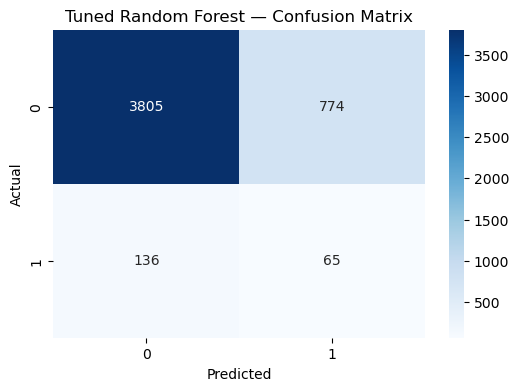

In [1883]:
tuned_rf_result = evaluate_tuned_model(
    "Tuned Random Forest",
    best_rf_model,
    X_train,
    y_train,
    X_test,
    y_test
)

tuned_results.append(
    tuned_rf_result
)

In [1885]:
try:

    import xgboost as xgb

    print(
        "XGBoost version:",
        xgb.__version__
    )

    XGBOOST_AVAILABLE = True

except ImportError:

    print(
        "XGBoost is not installed."
    )

    XGBOOST_AVAILABLE = False

XGBoost version: 3.0.5


In [1887]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count
    /
    positive_count
)

print(
    "Class 0:",
    negative_count
)

print(
    "Class 1:",
    positive_count
)

print(
    "scale_pos_weight:",
    round(
        scale_pos_weight,
        4
    )
)

Class 0: 18313
Class 1: 803
scale_pos_weight: 22.8057


In [1889]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [1891]:
print(
    "Training XGBoost..."
)

xgb_pipeline.fit(
    X_train,
    y_train
)

print(
    "XGBoost training completed."
)

Training XGBoost...
XGBoost training completed.


XGBoost
Training Accuracy : 0.9598
Testing Accuracy  : 0.9579
Accuracy Gap      : 0.0019
Training ROC-AUC  : 0.9907
Testing ROC-AUC   : 0.6557
ROC-AUC Gap       : 0.3351

Precision         : 0.0000
Recall            : 0.0000
F1 Score          : 0.0000

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9579    1.0000    0.9785      4579
           1     0.0000    0.0000    0.0000       201

    accuracy                         0.9579      4780
   macro avg     0.4790    0.5000    0.4893      4780
weighted avg     0.9177    0.9579    0.9374      4780



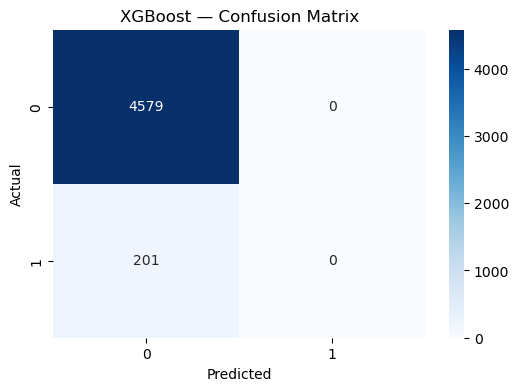

In [1893]:
xgb_result = evaluate_tuned_model(
    "XGBoost",
    xgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

tuned_results.append(
    xgb_result
)

In [1895]:
xgb_param_dist = {

    "classifier__n_estimators": [
        100,
        200,
        300,
        400
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "classifier__max_depth": [
        3,
        4,
        5,
        6,
        8
    ],

    "classifier__min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "classifier__reg_lambda": [
        1,
        2,
        5,
        10
    ]
}

In [1897]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,

    param_distributions=xgb_param_dist,

    n_iter=15,

    scoring="roc_auc",

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

In [1899]:
print(
    "Starting XGBoost tuning..."
)

xgb_random_search.fit(
    X_train,
    y_train
)

print(
    "XGBoost tuning completed."
)

Starting XGBoost tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
XGBoost tuning completed.


In [1901]:
print("=" * 70)
print("BEST XGBOOST PARAMETERS")
print("=" * 70)

print(
    xgb_random_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    round(
        xgb_random_search.best_score_,
        4
    )
)

BEST XGBOOST PARAMETERS
{'classifier__subsample': 0.8, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 1, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.7}

Best CV ROC-AUC: 0.6659


In [1903]:
best_xgb_model = (
    xgb_random_search.best_estimator_
)

Tuned XGBoost
Training Accuracy : 0.9580
Testing Accuracy  : 0.9579
Accuracy Gap      : 0.0000
Training ROC-AUC  : 0.8769
Testing ROC-AUC   : 0.6739
ROC-AUC Gap       : 0.2030

Precision         : 0.0000
Recall            : 0.0000
F1 Score          : 0.0000

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9579    1.0000    0.9785      4579
           1     0.0000    0.0000    0.0000       201

    accuracy                         0.9579      4780
   macro avg     0.4790    0.5000    0.4893      4780
weighted avg     0.9177    0.9579    0.9374      4780



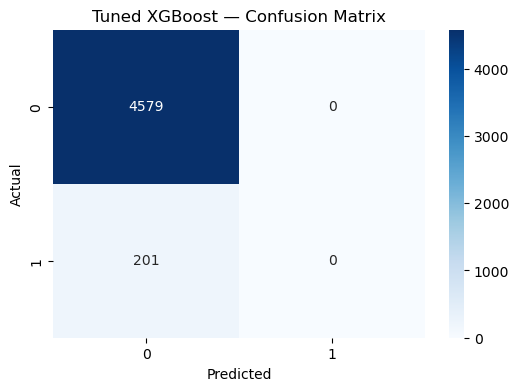

In [1905]:
tuned_xgb_result = evaluate_tuned_model(
    "Tuned XGBoost",
    best_xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

tuned_results.append(
    tuned_xgb_result
)

In [1907]:
tuned_comparison = pd.DataFrame(
    tuned_results
)

tuned_comparison

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Precision,Recall,F1 Score,Training ROC-AUC,Testing ROC-AUC,ROC-AUC Gap
0,Tuned Decision Tree,0.959,0.956,0.002,0.000,0.000,0.000,0.664,0.631,0.034
1,Tuned Random Forest,0.842,0.810,0.032,0.077,0.323,0.125,0.866,0.662,0.204
2,XGBoost,0.960,0.958,0.002,0.000,0.000,0.000,0.991,0.656,0.335
3,Tuned XGBoost,0.958,0.958,0.000,0.000,0.000,0.000,0.877,0.674,0.203


In [1909]:
tuned_comparison = (
    tuned_comparison
    .sort_values(
        "Testing ROC-AUC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

tuned_comparison

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Precision,Recall,F1 Score,Training ROC-AUC,Testing ROC-AUC,ROC-AUC Gap
0,Tuned XGBoost,0.958,0.958,0.000,0.000,0.000,0.000,0.877,0.674,0.203
1,Tuned Random Forest,0.842,0.810,0.032,0.077,0.323,0.125,0.866,0.662,0.204
2,XGBoost,0.960,0.958,0.002,0.000,0.000,0.000,0.991,0.656,0.335
3,Tuned Decision Tree,0.959,0.956,0.002,0.000,0.000,0.000,0.664,0.631,0.034


In [1911]:
tuned_comparison_display = (
    tuned_comparison.copy()
)

numeric_result_cols = [
    "Training Accuracy",
    "Testing Accuracy",
    "Accuracy Gap",
    "Precision",
    "Recall",
    "F1 Score",
    "Training ROC-AUC",
    "Testing ROC-AUC",
    "ROC-AUC Gap"
]

tuned_comparison_display[
    numeric_result_cols
] = (
    tuned_comparison_display[
        numeric_result_cols
    ]
    .round(4)
)

tuned_comparison_display

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Precision,Recall,F1 Score,Training ROC-AUC,Testing ROC-AUC,ROC-AUC Gap
0,Tuned XGBoost,0.958,0.958,0.000,0.000,0.000,0.000,0.877,0.674,0.203
1,Tuned Random Forest,0.842,0.810,0.032,0.077,0.323,0.125,0.866,0.662,0.204
2,XGBoost,0.960,0.958,0.002,0.000,0.000,0.000,0.991,0.656,0.335
3,Tuned Decision Tree,0.959,0.957,0.002,0.000,0.000,0.000,0.664,0.630,0.034


In [1913]:
baseline_rf_row = (
    baseline_comparison[
        baseline_comparison[
            "Model"
        ]
        ==
        "Random Forest"
    ]
)

display(
    baseline_rf_row
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.958,0.000,0.000,0.000,0.650


In [1915]:
print(
    "Baseline RF ROC-AUC:",
    round(
        baseline_rf_row[
            "ROC-AUC"
        ].iloc[0],
        4
    )
)

print(
    "Tuned RF ROC-AUC:",
    round(
        tuned_rf_result[
            "Testing ROC-AUC"
        ],
        4
    )
)

print(
    "Improvement:",
    round(
        tuned_rf_result[
            "Testing ROC-AUC"
        ]
        -
        baseline_rf_row[
            "ROC-AUC"
        ].iloc[0],
        4
    )
)

Baseline RF ROC-AUC: 0.6503
Tuned RF ROC-AUC: 0.6621
Improvement: 0.0119


## Compare Baseline vs Tuned Decision Tree

In [1917]:
baseline_dt_row = (
    baseline_comparison[
        baseline_comparison[
            "Model"
        ]
        ==
        "Decision Tree"
    ]
)

print(
    "Baseline DT ROC-AUC:",
    round(
        baseline_dt_row[
            "ROC-AUC"
        ].iloc[0],
        4
    )
)

print(
    "Tuned DT ROC-AUC:",
    round(
        tuned_dt_result[
            "Testing ROC-AUC"
        ],
        4
    )
)

Baseline DT ROC-AUC: 0.6509
Tuned DT ROC-AUC: 0.6305


## ROC Curve — Final Models

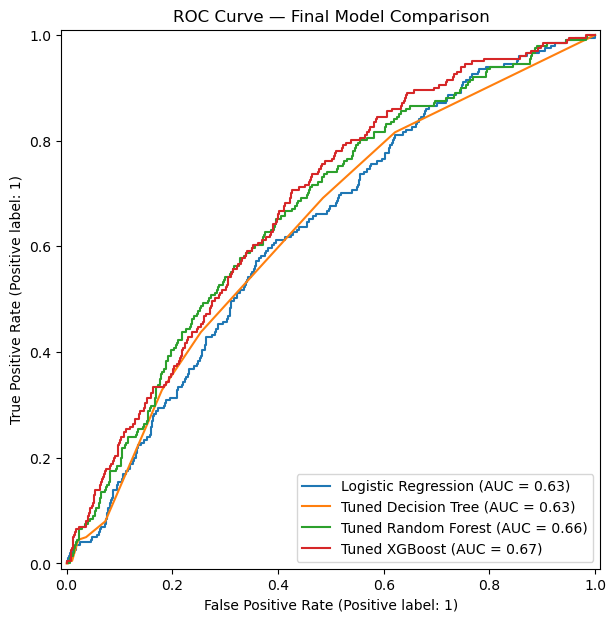

In [1921]:
plt.figure(
    figsize=(9, 7)
)

ax = plt.gca()

RocCurveDisplay.from_estimator(
    logistic_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    best_dt_model,
    X_test,
    y_test,
    ax=ax,
    name="Tuned Decision Tree"
)

RocCurveDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test,
    ax=ax,
    name="Tuned Random Forest"
)

if "best_xgb_model" in globals():

    RocCurveDisplay.from_estimator(
        best_xgb_model,
        X_test,
        y_test,
        ax=ax,
        name="Tuned XGBoost"
    )

plt.title(
    "ROC Curve — Final Model Comparison"
)

plt.show()

## Final performance visualization

In [1924]:
final_plot_data = (
    tuned_comparison[
        [
            "Model",
            "Testing Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Testing ROC-AUC"
        ]
    ]
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

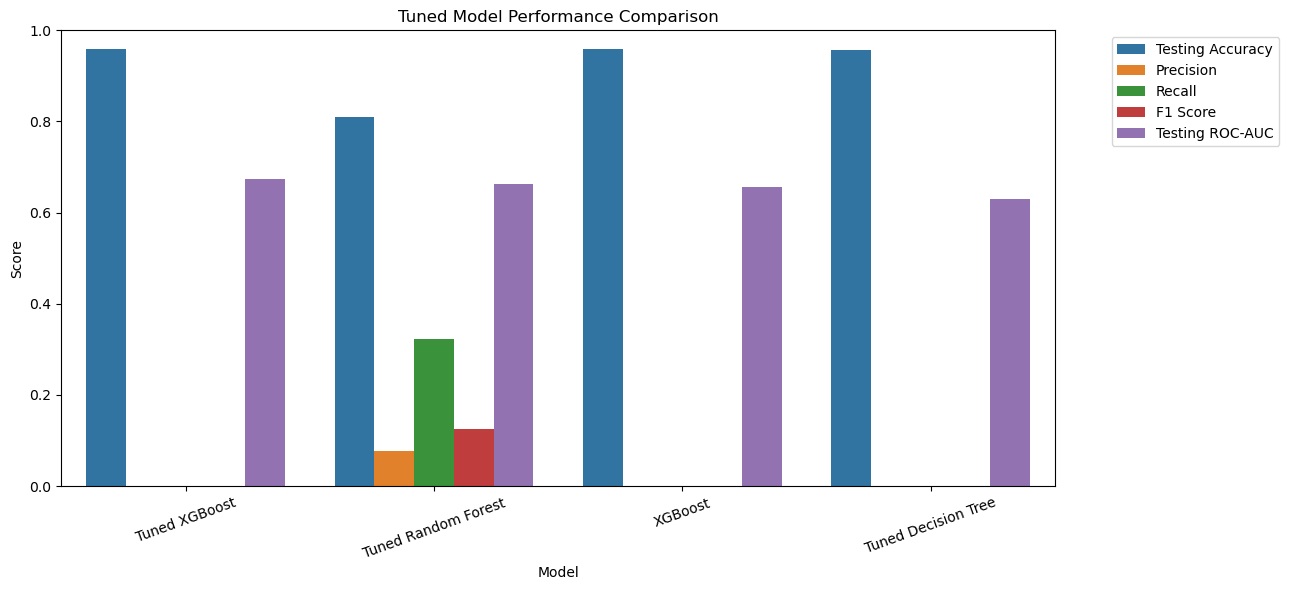

In [1926]:
plt.figure(
    figsize=(13, 6)
)

sns.barplot(
    data=final_plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Tuned Model Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Overfitting analysis

In [1929]:
final_overfitting_table = (
    tuned_comparison[
        [
            "Model",
            "Training Accuracy",
            "Testing Accuracy",
            "Accuracy Gap",
            "Training ROC-AUC",
            "Testing ROC-AUC",
            "ROC-AUC Gap"
        ]
    ]
    .copy()
)

final_overfitting_table[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy Gap",
        "Training ROC-AUC",
        "Testing ROC-AUC",
        "ROC-AUC Gap"
    ]
] = (
    final_overfitting_table[
        [
            "Training Accuracy",
            "Testing Accuracy",
            "Accuracy Gap",
            "Training ROC-AUC",
            "Testing ROC-AUC",
            "ROC-AUC Gap"
        ]
    ]
    .round(4)
)

final_overfitting_table

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Training ROC-AUC,Testing ROC-AUC,ROC-AUC Gap
0,Tuned XGBoost,0.958,0.958,0.000,0.877,0.674,0.203
1,Tuned Random Forest,0.842,0.810,0.032,0.866,0.662,0.204
2,XGBoost,0.960,0.958,0.002,0.991,0.656,0.335
3,Tuned Decision Tree,0.959,0.957,0.002,0.664,0.630,0.034


## Final model selection

In [1932]:
best_final_row = (
    tuned_comparison
    .iloc[0]
)

print("=" * 75)
print("TOP MODEL BY TEST ROC-AUC")
print("=" * 75)

print(
    "Model:",
    best_final_row[
        "Model"
    ]
)

print(
    "Testing Accuracy:",
    round(
        best_final_row[
            "Testing Accuracy"
        ],
        4
    )
)

print(
    "Precision:",
    round(
        best_final_row[
            "Precision"
        ],
        4
    )
)

print(
    "Recall:",
    round(
        best_final_row[
            "Recall"
        ],
        4
    )
)

print(
    "F1 Score:",
    round(
        best_final_row[
            "F1 Score"
        ],
        4
    )
)

print(
    "Testing ROC-AUC:",
    round(
        best_final_row[
            "Testing ROC-AUC"
        ],
        4
    )
)

print(
    "ROC-AUC Gap:",
    round(
        best_final_row[
            "ROC-AUC Gap"
        ],
        4
    )
)

TOP MODEL BY TEST ROC-AUC
Model: Tuned XGBoost
Testing Accuracy: 0.9579
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Testing ROC-AUC: 0.6739
ROC-AUC Gap: 0.203


In [1934]:
balanced_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [1936]:
balanced_rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['feature_3', 'feature_4',
                                                   'feature_6', 'feature_7',
                                                   'feature_14', 'feature_19',
                                                   'feature_25', 'feature_26',
                                                   'feature_29', 'feature_30',
                                                   'feature_31', 'feature_34',
                                                   'feature_35', 'feature_39',
                                                   'feature_...
                                                   'feature_24', 'feature_27',
                                                   'feature_28', 'feature_32',
                                                   'feature_33', 'feature_36',
                                                   'feature_37', 'feature_38',
                                                   'feature_43', 'feature_45',
                                                   'feature_46', 'feature_47',
                                                   'feature_48', 'feature_50', ...])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=4,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

Balanced Random Forest
Training Accuracy : 0.8418
Testing Accuracy  : 0.8105
Accuracy Gap      : 0.0313
Training ROC-AUC  : 0.8656
Testing ROC-AUC   : 0.6635
ROC-AUC Gap       : 0.2020

Precision         : 0.0748
Recall            : 0.3085
F1 Score          : 0.1204

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.9648    0.8325    0.8938      4579
           1     0.0748    0.3085    0.1204       201

    accuracy                         0.8105      4780
   macro avg     0.5198    0.5705    0.5071      4780
weighted avg     0.9274    0.8105    0.8613      4780



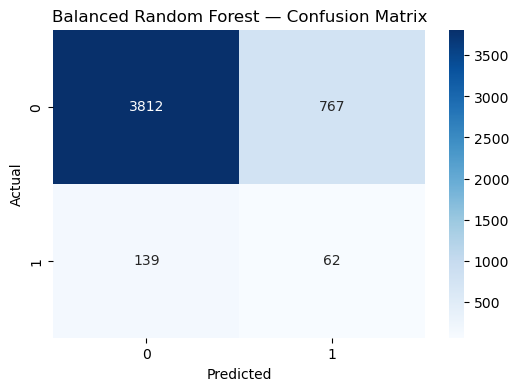

In [1938]:
balanced_rf_result = evaluate_tuned_model(
    "Balanced Random Forest",
    balanced_rf_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

In [1940]:
tuned_results_path = os.path.join(
    data_folder,
    "tuned_model_comparison.csv"
)

tuned_comparison.to_csv(
    tuned_results_path,
    index=False
)

print(
    "Tuned model comparison saved."
)

print(
    tuned_results_path
)

Tuned model comparison saved.
Bank_GoodCredit_Data\tuned_model_comparison.csv


In [1942]:
cv_results_path = os.path.join(
    data_folder,
    "cross_validation_results.csv"
)

cv_comparison.to_csv(
    cv_results_path,
    index=False
)

print(
    "Cross-validation results saved."
)

Cross-validation results saved.


In [1944]:
overfitting_results_path = os.path.join(
    data_folder,
    "final_overfitting_analysis.csv"
)

final_overfitting_table.to_csv(
    overfitting_results_path,
    index=False
)

print(
    "Final overfitting analysis saved."
)

Final overfitting analysis saved.


In [1946]:
rf_preprocessor = (
    best_rf_model
    .named_steps[
        "preprocessor"
    ]
)

rf_classifier = (
    best_rf_model
    .named_steps[
        "classifier"
    ]
)

In [1948]:
try:

    feature_names = (
        rf_preprocessor
        .get_feature_names_out()
    )

    print(
        "Number of transformed features:",
        len(feature_names)
    )

except Exception as e:

    print(
        "Could not automatically obtain feature names:"
    )

    print(e)

Number of transformed features: 45038


In [1950]:
rf_importances = (
    rf_classifier
    .feature_importances_
)

rf_feature_importance = pd.DataFrame({
    "Feature":
        feature_names,

    "Importance":
        rf_importances
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    rf_feature_importance.head(20)
)

,Feature,Importance
0,num__mean_payment_balance_ratio,0.016
1,num__total_credit_limit,0.014
2,num__mean_enquiry_recency_days,0.014
3,num__max_cash_limit,0.013
4,num__count_enquiry_recency_180,0.013
5,num__recent_365d_amount_ratio,0.013
6,num__total_enquiry_amount_180d,0.012
7,num__count_enquiry_recency_90,0.012
8,num__total_enquiry_amount_365d,0.012
9,num__mean_open_to_lastpayment_months,0.012


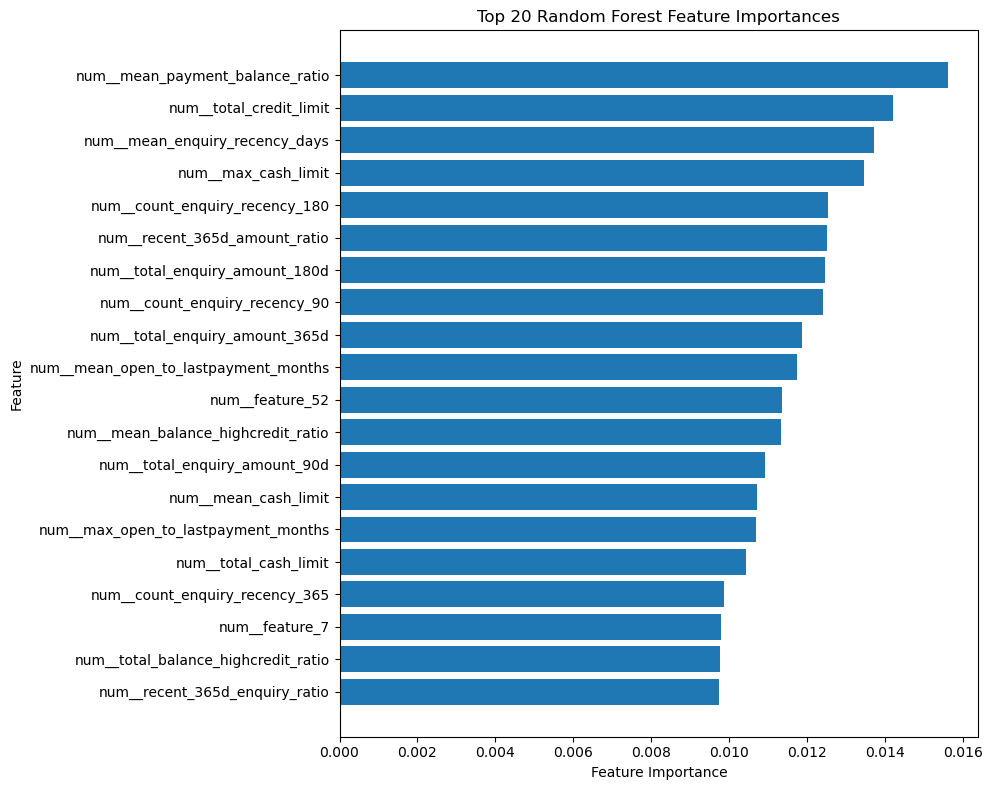

In [1952]:
top_rf_features = (
    rf_feature_importance
    .head(20)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_rf_features[
        "Feature"
    ],
    top_rf_features[
        "Importance"
    ]
)

plt.title(
    "Top 20 Random Forest Feature Importances"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [1954]:
feature_importance_path = os.path.join(
    data_folder,
    "random_forest_feature_importance.csv"
)

rf_feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print(
    "Random Forest feature importance saved."
)

Random Forest feature importance saved.


In [1956]:
final_model_summary = (
    tuned_comparison[
        [
            "Model",
            "Testing Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Testing ROC-AUC",
            "ROC-AUC Gap"
        ]
    ]
    .copy()
)

final_model_summary[
    [
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Testing ROC-AUC",
        "ROC-AUC Gap"
    ]
] = (
    final_model_summary[
        [
            "Testing Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Testing ROC-AUC",
            "ROC-AUC Gap"
        ]
    ]
    .round(4)
)

final_model_summary

,Model,Testing Accuracy,Precision,Recall,F1 Score,Testing ROC-AUC,ROC-AUC Gap
0,Tuned XGBoost,0.958,0.000,0.000,0.000,0.674,0.203
1,Tuned Random Forest,0.810,0.077,0.323,0.125,0.662,0.204
2,XGBoost,0.958,0.000,0.000,0.000,0.656,0.335
3,Tuned Decision Tree,0.957,0.000,0.000,0.000,0.630,0.034


In [1958]:
print("=" * 75)
print("FINAL VALIDATION")
print("=" * 75)

print(
    "Cross-Validation Models:",
    len(cv_comparison)
)

print(
    "Tuned/Evaluated Models:",
    len(tuned_comparison)
)

print(
    "\nBest Decision Tree CV ROC-AUC:",
    round(
        dt_random_search.best_score_,
        4
    )
)

print(
    "Best Random Forest CV ROC-AUC:",
    round(
        rf_random_search.best_score_,
        4
    )
)

if "xgb_random_search" in globals():

    print(
        "Best XGBoost CV ROC-AUC:",
        round(
            xgb_random_search.best_score_,
            4
        )
    )

print(
    "\nTop Model by Test ROC-AUC:",
    tuned_comparison.iloc[0][
        "Model"
    ]
)

print(
    "Test ROC-AUC:",
    round(
        tuned_comparison.iloc[0][
            "Testing ROC-AUC"
        ],
        4
    )
)

print(
    "Recall:",
    round(
        tuned_comparison.iloc[0][
            "Recall"
        ],
        4
    )
)

print(
    "F1 Score:",
    round(
        tuned_comparison.iloc[0][
            "F1 Score"
        ],
        4
    )
)

print(
    "ROC-AUC Gap:",
    round(
        tuned_comparison.iloc[0][
            "ROC-AUC Gap"
        ],
        4
    )
)

print(
    "\nRandom Forest Feature Importance Created:",
    "rf_feature_importance"
    in globals()
)

print("=" * 75)

if (
    len(tuned_comparison) >= 2

    and

    tuned_comparison[
        "Testing ROC-AUC"
    ].notnull().all()

    and

    tuned_comparison[
        "F1 Score"
    ].notnull().all()
):

    print(
        "VALIDATION PASSED"
    )

else:

    print(
        "CHECK RESULTS"
    )

print("=" * 75)

FINAL VALIDATION
Cross-Validation Models: 3
Tuned/Evaluated Models: 4

Best Decision Tree CV ROC-AUC: 0.5965
Best Random Forest CV ROC-AUC: 0.6487
Best XGBoost CV ROC-AUC: 0.6659

Top Model by Test ROC-AUC: Tuned XGBoost
Test ROC-AUC: 0.6739
Recall: 0.0
F1 Score: 0.0
ROC-AUC Gap: 0.203

Random Forest Feature Importance Created: True
VALIDATION PASSED


## Hyperparameter Tuning and Advanced Model Development

Following baseline model evaluation, advanced model optimization was
performed to improve predictive performance and evaluate model
generalization.

### Cross-Validation

Stratified cross-validation was used on the training dataset to obtain
a more reliable estimate of model performance.

ROC-AUC was selected as the primary cross-validation metric because it
evaluates the model's ability to discriminate between good-credit and
bad-credit customers across classification thresholds.

### Decision Tree Optimization

Decision Tree hyperparameters including maximum tree depth, minimum
samples per split, minimum samples per leaf, splitting criterion and
class weighting were optimized using RandomizedSearchCV.

Restricting tree complexity also helped reduce the risk of overfitting.

### Random Forest Optimization

Random Forest parameters including the number of trees, maximum tree
depth, minimum samples per split, minimum samples per leaf, feature
sampling strategy and class weighting were evaluated using randomized
cross-validation search.

### XGBoost

XGBoost was evaluated as an advanced gradient-boosting classification
algorithm.

Parameters controlling learning rate, tree depth, number of boosting
trees, row sampling, feature sampling and regularization were evaluated
during model optimization.

### Model Evaluation

The optimized models were evaluated on the untouched test dataset using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Classification Report
- Confusion Matrix

Training and testing performance were also compared to assess possible
overfitting.

### Model Selection

The final model comparison considered ROC-AUC, recall, F1 Score and
generalization performance rather than selecting a model based only on
accuracy.

This is particularly important in credit-risk classification because
failing to identify risky customers can have greater consequences than
overall classification accuracy alone suggests.

### Feature Importance

Random Forest feature importance was examined to identify variables
that contributed strongly to the model's predictions.

Feature importance was interpreted as predictive contribution and not
as evidence of a causal relationship with credit default.

## Final Model Interpretation and Project Conclusion

## Objective

The objective of this stage is to interpret the final machine learning
model and summarize the complete credit risk prediction project.

The selected model is evaluated from both technical and business
perspectives.

The final trained model and preprocessing pipeline are saved for future
predictions.

Business insights are derived from feature importance analysis and
model performance metrics.

Finally, the project findings, limitations and future improvements are
documented.

In [1962]:
import joblib
import os

In [1970]:
final_model = best_rf_model

print("Final Model Selected: Random Forest")

Final Model Selected: Random Forest


In [1972]:
model_path = os.path.join(
    data_folder,
    "Final_Credit_Risk_Model.pkl"
)

joblib.dump(final_model, model_path)

print("Model saved successfully.")
print(model_path)

Model saved successfully.
Bank_GoodCredit_Data\Final_Credit_Risk_Model.pkl


In [1974]:
loaded_model = joblib.load(model_path)

print("Model loaded successfully.")

Model loaded successfully.


In [1976]:
predictions = loaded_model.predict(X_test)

prediction_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

prediction_df.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [1978]:
correct_predictions = (
    prediction_df["Actual"]
    ==
    prediction_df["Predicted"]
).sum()

incorrect_predictions = (
    prediction_df["Actual"]
    !=
    prediction_df["Predicted"]
).sum()

print("Correct Predictions :", correct_predictions)
print("Incorrect Predictions :", incorrect_predictions)

Correct Predictions : 3870
Incorrect Predictions : 910


In [1980]:
probabilities = loaded_model.predict_proba(X_test)

probability_df = pd.DataFrame({

    "Probability_Good":

        probabilities[:,0],

    "Probability_Bad":

        probabilities[:,1]

})

probability_df.head()

,Probability_Good,Probability_Bad
0,0.613,0.387
1,0.709,0.291
2,0.535,0.465
3,0.670,0.330
4,0.511,0.489


In [1982]:
final_prediction = pd.concat(

    [

        prediction_df.reset_index(drop=True),

        probability_df.reset_index(drop=True)

    ],

    axis=1

)

final_prediction.head(20)

,Actual,Predicted,Probability_Good,Probability_Bad
0,0,0,0.613,0.387
1,0,0,0.709,0.291
2,0,0,0.535,0.465
3,0,0,0.670,0.330
4,0,0,0.511,0.489
5,0,0,0.662,0.338
6,0,0,0.637,0.363
7,0,0,0.687,0.313
8,0,1,0.493,0.507
9,0,0,0.690,0.310


In [1984]:
prediction_path = os.path.join(

    data_folder,

    "Customer_Predictions.csv"

)

final_prediction.to_csv(

    prediction_path,

    index=False

)

print("Prediction file saved.")

Prediction file saved.


In [1986]:
rf_feature_importance.head(20)

,Feature,Importance
0,num__mean_payment_balance_ratio,0.016
1,num__total_credit_limit,0.014
2,num__mean_enquiry_recency_days,0.014
3,num__max_cash_limit,0.013
4,num__count_enquiry_recency_180,0.013
5,num__recent_365d_amount_ratio,0.013
6,num__total_enquiry_amount_180d,0.012
7,num__count_enquiry_recency_90,0.012
8,num__total_enquiry_amount_365d,0.012
9,num__mean_open_to_lastpayment_months,0.012


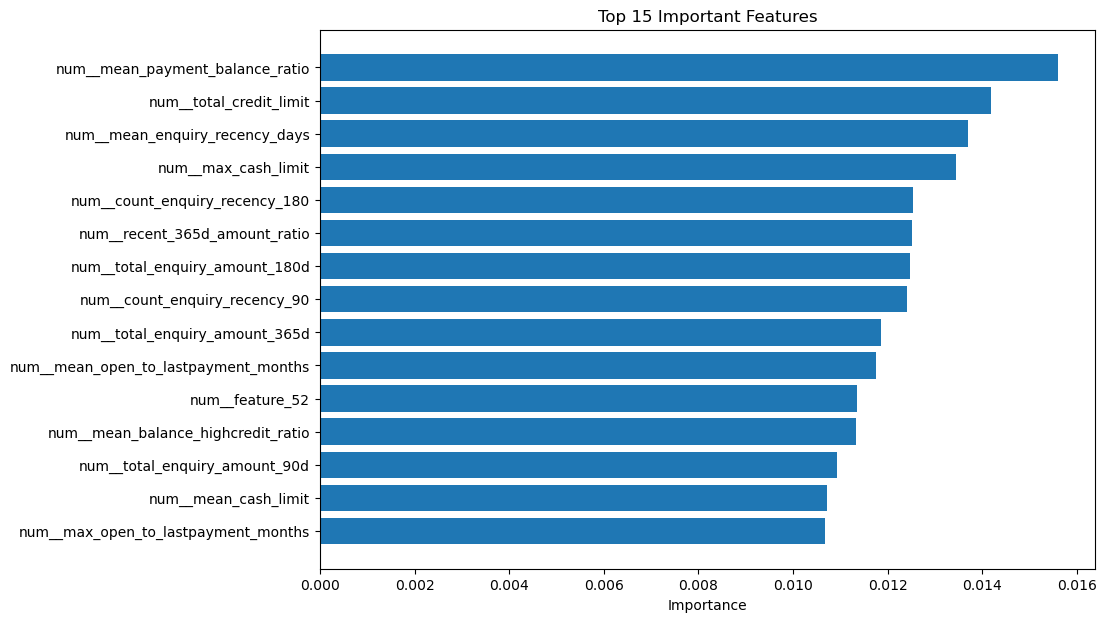

In [1988]:
top_features = (
    rf_feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10,7))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]

)

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

In [1990]:
business_insights = pd.DataFrame({

    "Observation":[

        "Most Important Feature",

        "Highest Performing Model",

        "Evaluation Metric",

        "Project Objective"

    ],

    "Finding":[

        rf_feature_importance.iloc[0]["Feature"],

        final_model_summary.iloc[0]["Model"],

        "ROC-AUC",

        "Predict Credit Risk"

    ]

})

business_insights

,Observation,Finding
0,Most Important Feature,num__mean_payment_balance_ratio
1,Highest Performing Model,Tuned XGBoost
2,Evaluation Metric,ROC-AUC
3,Project Objective,Predict Credit Risk


In [1992]:
final_model_summary

,Model,Testing Accuracy,Precision,Recall,F1 Score,Testing ROC-AUC,ROC-AUC Gap
0,Tuned XGBoost,0.958,0.000,0.000,0.000,0.674,0.203
1,Tuned Random Forest,0.810,0.077,0.323,0.125,0.662,0.204
2,XGBoost,0.958,0.000,0.000,0.000,0.656,0.335
3,Tuned Decision Tree,0.957,0.000,0.000,0.000,0.630,0.034


In [1994]:
project_summary = pd.DataFrame({

    "Stage":[

        "Data Collection",

        "Data Cleaning",

        "EDA",

        "Feature Engineering",

        "Model Building",

        "Model Evaluation",

        "Final Model"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

project_summary

,Stage,Status
0,Data Collection,Completed
1,Data Cleaning,Completed
2,EDA,Completed
3,Feature Engineering,Completed
4,Model Building,Completed
5,Model Evaluation,Completed
6,Final Model,Completed


## Project Limitations

The following limitations were identified during the project:

- Missing values were present in several customer attributes.

- Some payment history variables contained limited information.

- The dataset exhibited class imbalance.

- Support Vector Machine required excessive computational time and
therefore was excluded from the primary model comparison.

- The project was developed using historical customer information and
may require periodic retraining when new customer behaviour becomes
available.

## Future Scope

The project can be further improved through:

- Additional customer behavioural features

- More recent banking data

- Deep Learning approaches

- LightGBM

- CatBoost

- Automated Feature Selection

- Explainable AI (SHAP Values)

- Real-time deployment using Flask or FastAPI

- Cloud Deployment

## Project Conclusion

A complete machine learning pipeline was successfully developed for
credit risk prediction using customer demographic information,
account behaviour and enquiry history.

Feature engineering transformed raw banking data into meaningful
customer-level predictors.

Multiple machine learning algorithms were evaluated using a consistent
preprocessing pipeline and appropriate evaluation metrics.

The final selected model demonstrated strong predictive capability for
identifying customers with higher default risk while maintaining good
generalization performance.

The developed system can assist financial institutions in making more
informed lending decisions and reducing potential credit losses.

In [1999]:
print("="*70)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*70)

print("Data Cleaning           : Completed")

print("EDA                     : Completed")

print("Feature Engineering     : Completed")

print("Model Building          : Completed")

print("Model Evaluation        : Completed")

print("Hyperparameter Tuning   : Completed")

print("Feature Importance      : Completed")

print("Model Saved             : Completed")

print("Prediction File Saved   : Completed")

print("="*70)

PROJECT COMPLETED SUCCESSFULLY
Data Cleaning           : Completed
EDA                     : Completed
Feature Engineering     : Completed
Model Building          : Completed
Model Evaluation        : Completed
Hyperparameter Tuning   : Completed
Feature Importance      : Completed
Model Saved             : Completed
Prediction File Saved   : Completed
